# `Classification semi-supervisée Fixmatch`
- __Implémentation de l'algorithme de en PyTorch__

### __`Conclusion FixMatch`__ : 

__`Quelque soit le modèle implémenté ci-dessous l'accurracy augmente pour`__
- `top-: 69.85 % pour lequel la classe prédite la plus probable est exactement le label vrai`
- `top-5: 97.15 % pour lequel le label vrai est dans les 5 classes les plus probables prédites`
`L’accuracy progresse, mais reste modeste : on monte de ~10 % à ~61 % top‑1, ~95 % top‑5 vers l’epoch 20, avec des variations (50–60 %) entre epochs`.
`La densité de pseudo‑labels est très élevée : mean_non_zero_unsup_loss_density reste autour de 0.65–0.70 sur beaucoup d’epochs → 65–70 % des unlabeled sont utilisés, ce qui est énorme`.
`La perte supervisée devient minuscule (sup_loss ~0.01) alors que unsup_loss ~0.6–0.7 (en moyenne) et même beaucoup plus dans les accumulations → l’unsup domine largement le signal supervisé`.
`En comparaison, les implémentations FixMatch sur CIFAR‑10 avec WideResNet atteignent ~90–95 % top‑1 après un entraînement long, avec un équilibre plus fin entre sup et unsup (λ_u = 1 mais seuil très strict, bonne calibration, et souvent plus d’epochs)`.
`Bien que les différentes versions des modèles convergent, l'apprentissage s'arrête trop tôt à 128 époques pour obtenir les valeurs d'accuracy souhaités alors que le scpoe est 512 à 1024 epoch. L'apprentissage est très consommateur en ressources et en temps mais également très discriminant sur les images non labellisées.`

`L'apprentissage du moèdèle resnet18 pré-entrainé à consommé un abonnement mesuel colab en quelque heures sans aboutir`

__`Quelque soit le modèle il serait nécessaire d'aller au bout de l'apprentissage pour mettre en évidence des la supériorité d'un modèle par rapport aux autres (peu profond et plus large) bien que le modèle du cours soit plus rapide que les autres.`__ 


Dans ce notebook, vous allez compléter le code de l'algorithme Fixmatch, et le tester sur CIFAR10 en utilisant seulement 250 exemples supervisés et le reste en non-supervisé.

À faire :
- compléter le code de la fonction `fixMatchstepAlgo()`, voir plus bas
- réaliser un apprentissage supervisé sur les 250 exemples supervisés, pour comparaison avec le même modèle entraîné avec Fixmatch.


<img src="https://www.irit.fr/~Thomas.Pellegrini/ens/M2ML3/fixmatch_diagram.png" alt="diagram FixMatch" width="800"/>


## `Contexte et notations`

### `Apprentissage semi-supervisé`

- Problème de classification à $L$ classes exclusives
- Exemples labélisés : $\cal{X} = \{(x_b,p_b) : b \in (1,...,B)\}$
- Exemples non-labélisés : $\cal{U} = \{u_b : b \in (1,...,\mu B)\}$
- Le modèle prédit un label pour l'entrée $x$ : $q = p_m (\text{target}|x; \theta)$
- Cross-Entropy : $H(p, q)$
- Augmentations faibles (weak): $\alpha(x)$. 
  - Par exemple, rotations, translations, flips, etc
- Augmentations fortes (strong) : $\cal{A}(x)$. 
  - Éventuellement, on pourrait utiliser des augmentations qui s'apprennent : AutoAugment, CTAugment, etc


### `Loss sur les données supervisées :`

- Cross-Entropy loss : $L(x, \text{class}) = - \log(q[\text{class}])$


### `Loss sur les données non-supervisées :`

- Consistency loss avec $\cal{l}^2$ : $L(x) = |p_m (\text{target}| \alpha_1(x); \theta) - p_m (\text{target}| \alpha_2(x); \theta)|^2$
- Ou Consistency loss avec Cross-Entropy : $p_m (\text{target}| \alpha_1(x); \theta) \rightarrow \text{target}$, $p_m (\text{target}| \alpha_2(x); \theta) \rightarrow \text{prédiction}$

### `Pseudo-labeling`

1) Le modèle génère des prédictions utilisées ensuite comme labels pour les données non-su+pervisées.

2) Fixmatch utilise des labels binaires ("hard labels"), et sélectionne uniquement celles dont la probabilité donnée par le modèle est supérieure à un seuil prédéfini :  

- Prédiction : $q = p_m (\text{target}|x; \theta)$
- Pseudo-label : $\hat{q} = \text{argmax}(q)$
- "Hard" label : $\max(q) \ge \tau$
- Loss :
  - $H(\hat{q}, q)$ if $\max(q) \ge \tau$
  - $0$ sinon


In [ ]:
%pip -q install IPython

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lrs
from torch.utils.data import Subset, Dataset, DataLoader
from torchvision import transforms as T
from torchvision.datasets.cifar import CIFAR10
from torchvision.models.resnet import resnet18
from torchvision.utils import make_grid

import matplotlib.pylab as plt
%matplotlib inline

In [30]:
import os
import torch
from IPython import get_ipython # type: ignore

def get_runtime_info():
    # 1) Détecter si on est sur Google Colab
    try:
        in_colab = 'google.colab' in str(get_ipython()) # type: ignore
    except NameError:
        in_colab = False

    # 2) Vérifier CUDA (GPU NVIDIA, typiquement sur Colab)
    cuda_available = torch.cuda.is_available()

    # 3) Vérifier MPS (GPU Apple Silicon, typiquement en local sur Mac)
    mps_available = getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available()

    if in_colab and cuda_available:
        device = torch.device("cuda")
        location = "colab_cuda"
    elif mps_available:
        device = torch.device("mps")
        location = "local_mps"
    else:
        device = torch.device("cpu")
        location = "cpu"

    return {
        "in_colab": in_colab,
        "cuda_available": cuda_available,
        "mps_available": mps_available,
        "device": device,
        "location": location,  # "colab_cuda", "local_mps" ou "cpu"
    }

info = get_runtime_info()
print("device",info["device"])
device=info["device"]

device mps


### `CIFAR10 dataset`

In [31]:
class TransformedDataset(Dataset):

    def __init__(self, dataset, transforms):
        self.dataset = dataset
        self.transforms = transforms

    def __getitem__(self, i):
        dp = self.dataset[i]
        return self.transforms(dp)

    def __len__(self):
        return len(self.dataset)

In [32]:
rep_path= "/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TPIA3_3/data/"
full_train_dataset = CIFAR10(rep_path, train=True, download=True)
full_test_dataset = CIFAR10(rep_path, train=False, download=False)

Files already downloaded and verified


In [33]:
print(full_test_dataset.meta)
print(full_test_dataset.classes)
label2id = {c: i for i, c in enumerate(full_test_dataset.classes)}
id2label = {v: k for k, v in label2id.items()}

{'filename': 'batches.meta', 'key': 'label_names', 'md5': '5ff9c542aee3614f3951f8cda6e48888'}
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


`Nous permet d'équilibrer le nombre d'occurences par classes` 

In [34]:
num_train_samples_per_class = 25
num_classes = 10

In [35]:
supervised_train_indices = []
counter = [0] * num_classes

for i, dp in enumerate(full_train_dataset): # (<PIL.Image.Image image mode=RGB size=32x32 at 0x132A5F910>, 6)
    if len(supervised_train_indices) >= num_classes * num_train_samples_per_class:
        break
    if counter[dp[1]] < num_train_samples_per_class: # limite le nombre de classes
        counter[dp[1]] += 1 # incrémente à l'indice de la classe le nombre d'occurence [0, 2, 0, 0, 1, 0, 1, 0, 0, 2]
        supervised_train_indices.append(i)

supervised_train_dataset = Subset(full_train_dataset, supervised_train_indices)

In [36]:
class_counts = { id2label[cls_id]: n for cls_id, n in enumerate(counter)}
print(class_counts)
print("Total :", sum(class_counts.values()))

{'airplane': 25, 'automobile': 25, 'bird': 25, 'cat': 25, 'deer': 25, 'dog': 25, 'frog': 25, 'horse': 25, 'ship': 25, 'truck': 25}
Total : 250


## __` 1. WiseNet`__
#### `1.1 TestLoader pour WiseNet`

In [37]:
batch_size = 64

In [38]:
cifar_mean = [0.4914, 0.4822, 0.4465]
cifar_std  = [0.2470, 0.2435, 0.2616]

test_transforms = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=cifar_mean, std=cifar_std)
])

test_loader = DataLoader(
    TransformedDataset(
        full_test_dataset,
        transforms=lambda dp: {"image": test_transforms(dp[0]), "target": dp[1]}
    ),
    batch_size=batch_size, num_workers=0, pin_memory=False, drop_last=False, shuffle=False
)

#### `1.2 Supervised TrainLoader pour WiseNet`

In [39]:
weak_transforms = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ColorJitter(0.5, 0.5),
    T.ToTensor(),
    T.Normalize(mean=cifar_mean, std=cifar_std)
])

supervised_train_loader = DataLoader(
    TransformedDataset(
        supervised_train_dataset,
        transforms=lambda dp: {"image": weak_transforms(dp[0]), "target": dp[1]}
    ),
    batch_size=batch_size, num_workers=0, pin_memory=False, drop_last=False, shuffle=True
)

#### `1.3 Extrait du dataset`

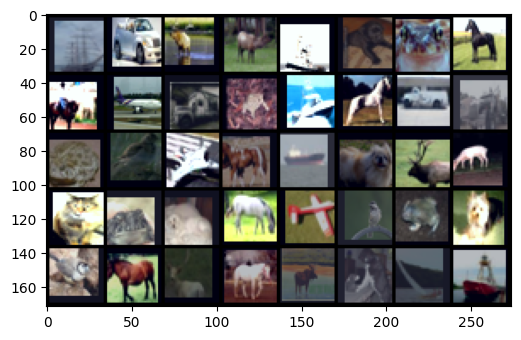

In [40]:
supervised_train_loader_iter = iter(supervised_train_loader)
sup_batch = next(supervised_train_loader_iter)

sup_weak_aug_batch = make_grid(sup_batch["image"][:40, ...], normalize=True)
plt.figure(figsize=(6, 4))
plt.tight_layout()
plt.imshow(sup_weak_aug_batch.numpy().transpose((1, 2, 0)))
plt.show()

#### `1.4 Unsupervised TrainLoader pour WiseNet`

In [45]:
mu_ratio = 7

In [44]:
strong_transforms = T.Compose([
    T.RandomAffine(45, translate=(0.2, 0.2), scale=(0.7, 1.2), shear=10),
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(0.15, 0.15, 0.15, 0.15),
    T.ToTensor(),
    T.Normalize(mean=cifar_mean, std=cifar_std),
    T.RandomErasing(scale=(0.02, 0.15))
])

unsupervised_train_dataset = TransformedDataset(
    full_train_dataset,
    transforms=lambda dp: {"image": weak_transforms(dp[0]), "strong_aug": strong_transforms(dp[0])}
)

unsupervised_train_loader = DataLoader(
    unsupervised_train_dataset,
    batch_size=batch_size * mu_ratio, num_workers=0, pin_memory=False, drop_last=False, shuffle=True
)

### `1.5 Extrait de la transformation`

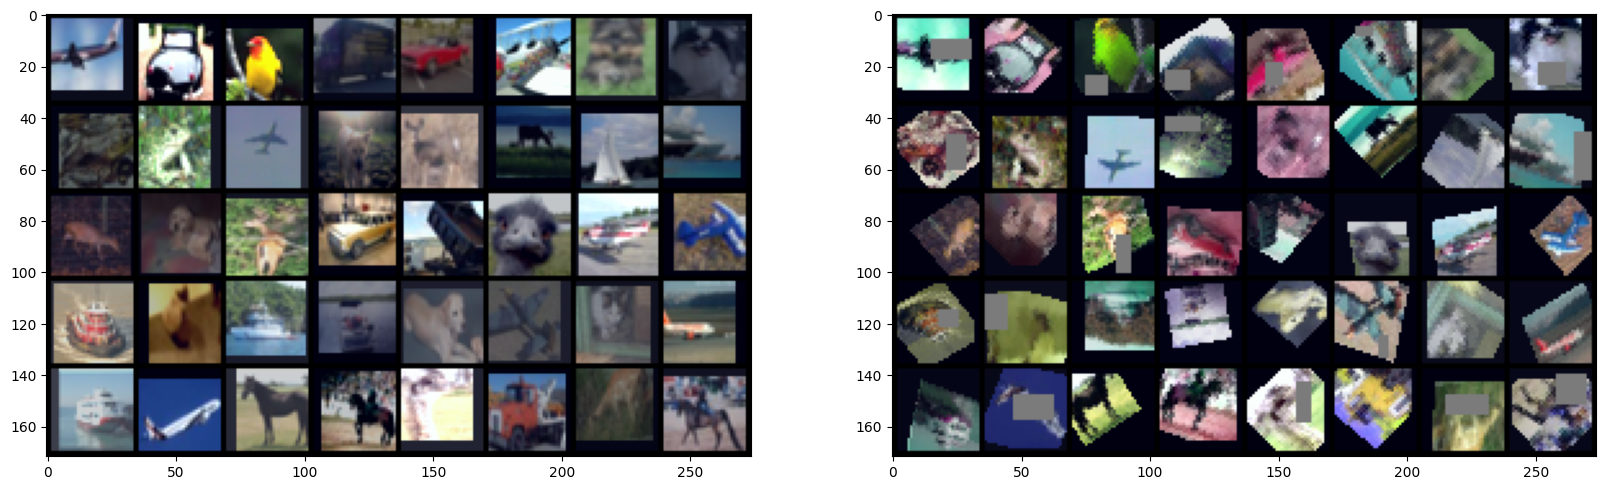

In [46]:
unsupervised_train_loader_iter = iter(unsupervised_train_loader)
unsup_batch = next(unsupervised_train_loader_iter)

unsup_weak_aug_batch = make_grid(unsup_batch["image"][:40, ...], normalize=True)
unsup_strong_aug_batch = make_grid(unsup_batch["strong_aug"][:40, ...], normalize=True)
plt.figure(figsize=(20, 7))
plt.subplot(121)
plt.imshow(unsup_weak_aug_batch.numpy().transpose((1, 2, 0)))
plt.subplot(122)
plt.imshow(unsup_strong_aug_batch.numpy().transpose((1, 2, 0)))
plt.show()

### `1.6 Modèle Wide-ResNet-28-2`

https://github.com/google-research/fixmatch/blob/08d9b83d7cc87e853e6afc5a86b12aacff56cdea/libml/models.py#L62

`WideResNet est un réseau résiduel`  
- Réseau de neurones profond constitué de blocs 
- chaque bloc apprend une correction (« résidu ») ajoutée à son entrée plutôt que d'apprendre la transformation d’un coup.
- WideResNet est une variante plus large et adaptée CIFAR‑like 

`Structure des blocs résiduels`
__Residual__
- 2 conv 3×3 + BatchNorm + LeakyReLU, 
- un skip connection via conv 1×1 si le nombre de canaux ou le stride change.
- activate_before_residual applique BN + activation sur l’entrée avant l’addition, tel que WideResNet CIFAR.

__Largeur et profondeur__
 - WideResNet(filters=32, repeat=4) : 3 groupes de blocs, canaux 32 → 64 → 128,
 - WideResNet moins de profondeur, plus de largeur → (plus de filtres), 
 - plus de filtres induit plus de capacité, des gradients plus stables, training plus facile sur CIFAR.

`Tête de classification`
 - WideResNet: BN + LeakyReLU + AdaptiveAvgPool2d(1) puis fc (filtres*4 → num_classes).

`En pratique`
 - WideResNet est adapté à CIFAR‑10/CIFAR‑100, avec une bonne capacité et un entraînement efficace pour ce format.

In [ ]:
import torch.nn as nn

class Residual(nn.Module):

    def __init__(self, in_channels, out_channels, stride, activate_before_residual=False):
        super().__init__()
        self.bn1 = nn.BatchNorm2d(in_channels, momentum=0.001)
        self.leaky_relu = nn.LeakyReLU(0.1, inplace=True)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels, momentum=0.001)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)

        self.activate_before_residual = activate_before_residual
        if in_channels == out_channels:
            self.skip = nn.Identity()
        else:
            self.skip = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, padding=0)

    def forward(self, x0):
        x = self.leaky_relu(self.bn1(x0))
        if self.activate_before_residual:
            x0 = x
        x = self.leaky_relu( self.bn2( self.conv1(x) ) )
        x = self.conv2(x)
        x0 = self.skip(x0)
        return x0 + x


class WideResNet(nn.Module):

    def __init__(self, num_classes=10, scales=3, filters=32, repeat=4):
        super().__init__()
        self.conv = nn.Conv2d(3, 16, kernel_size=3, padding=1)

        b0 = nn.Sequential(
            Residual(16, filters, stride=1, activate_before_residual=True),
            *[Residual(filters, filters, stride=1) for _ in range(repeat - 1)]
        )
        b1 = nn.Sequential(
            Residual(filters, filters * 2, stride=2),
            *[Residual(filters * 2, filters * 2, stride=1) for _ in range(repeat - 1)]
        )
        b2 = nn.Sequential(
            Residual(filters * 2, filters * 4, stride=2),
            *[Residual(filters * 4, filters * 4, stride=1) for _ in range(repeat - 1)]
        )
        self.res_blocks = nn.Sequential(b0, b1, b2)
        self.leaky_relu = nn.LeakyReLU(0.1, inplace=True)
        self.bn = nn.BatchNorm2d(filters * 4, momentum=0.001)
        self.reduce = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(filters * 4, num_classes)

    def forward(self, x):
        x = self.conv(x)
        x = self.res_blocks(x)
        x = self.bn(x)
        x = self.leaky_relu(x)
        x = self.reduce(x)
        x = torch.flatten(x, 1)
        return self.fc(x)

### `1.7 FixMatch algorithme`

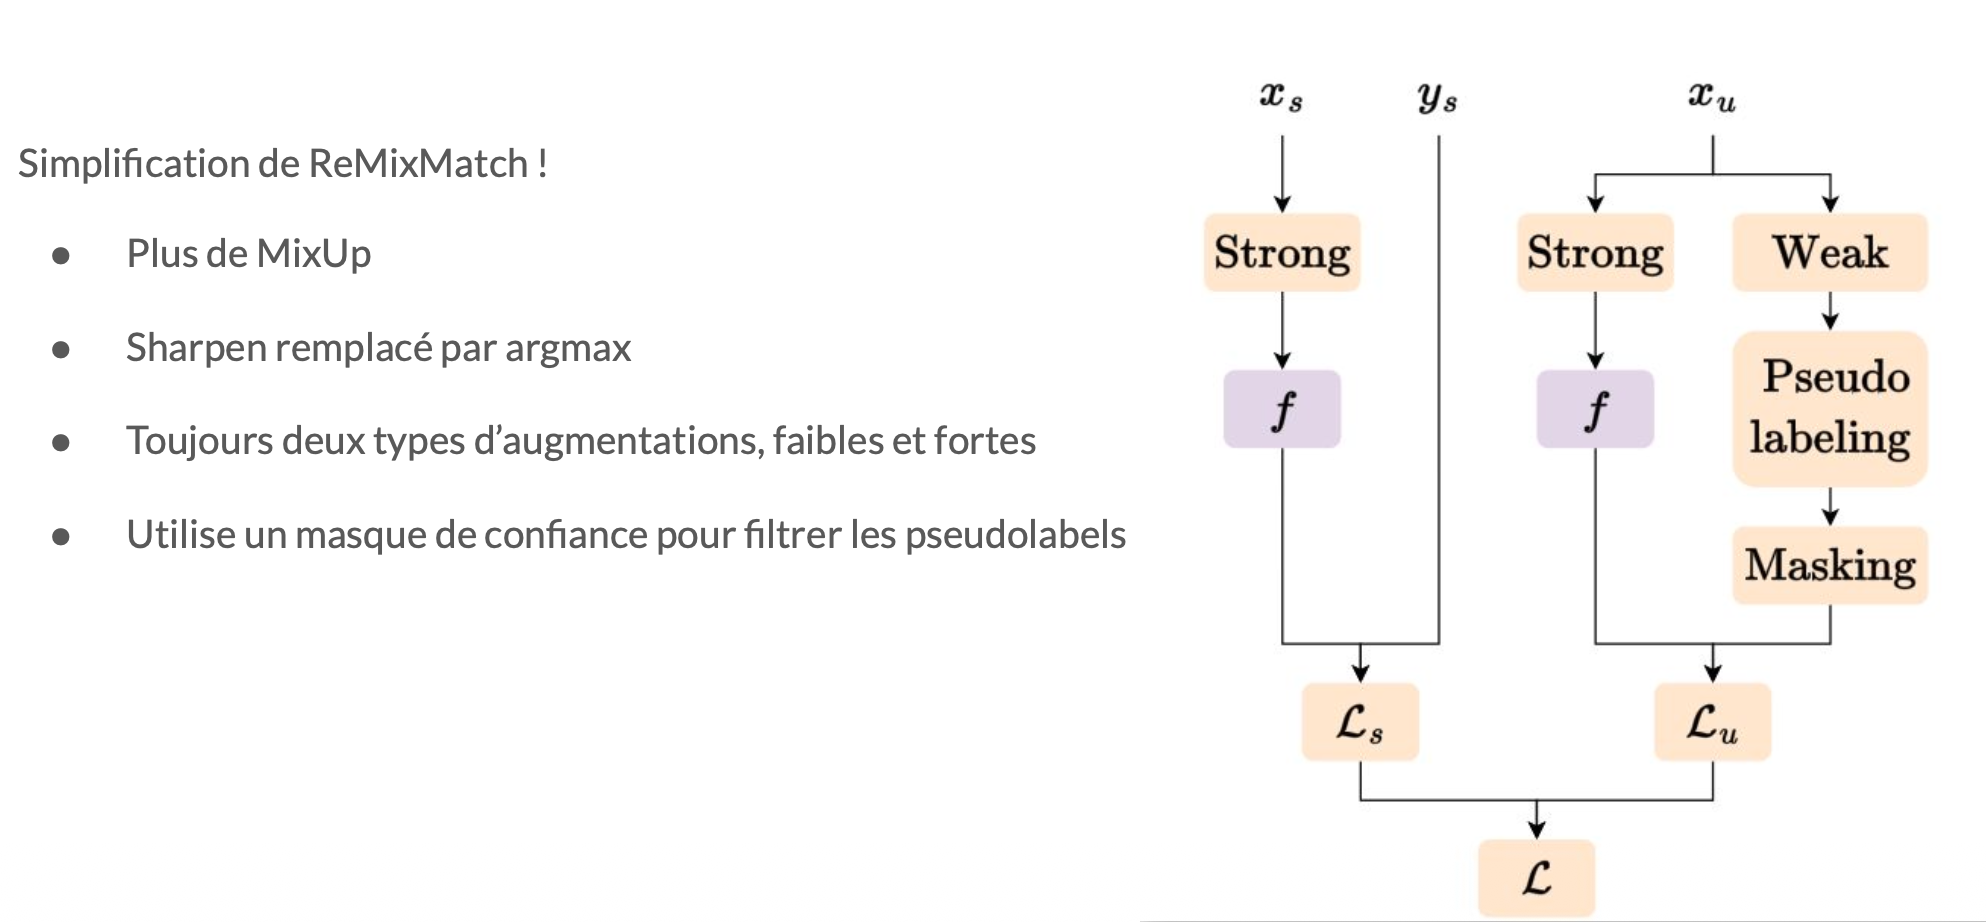

In [47]:
from IPython.display import Image, display
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TPIA3_3/images/MixMatch.png",width=700))

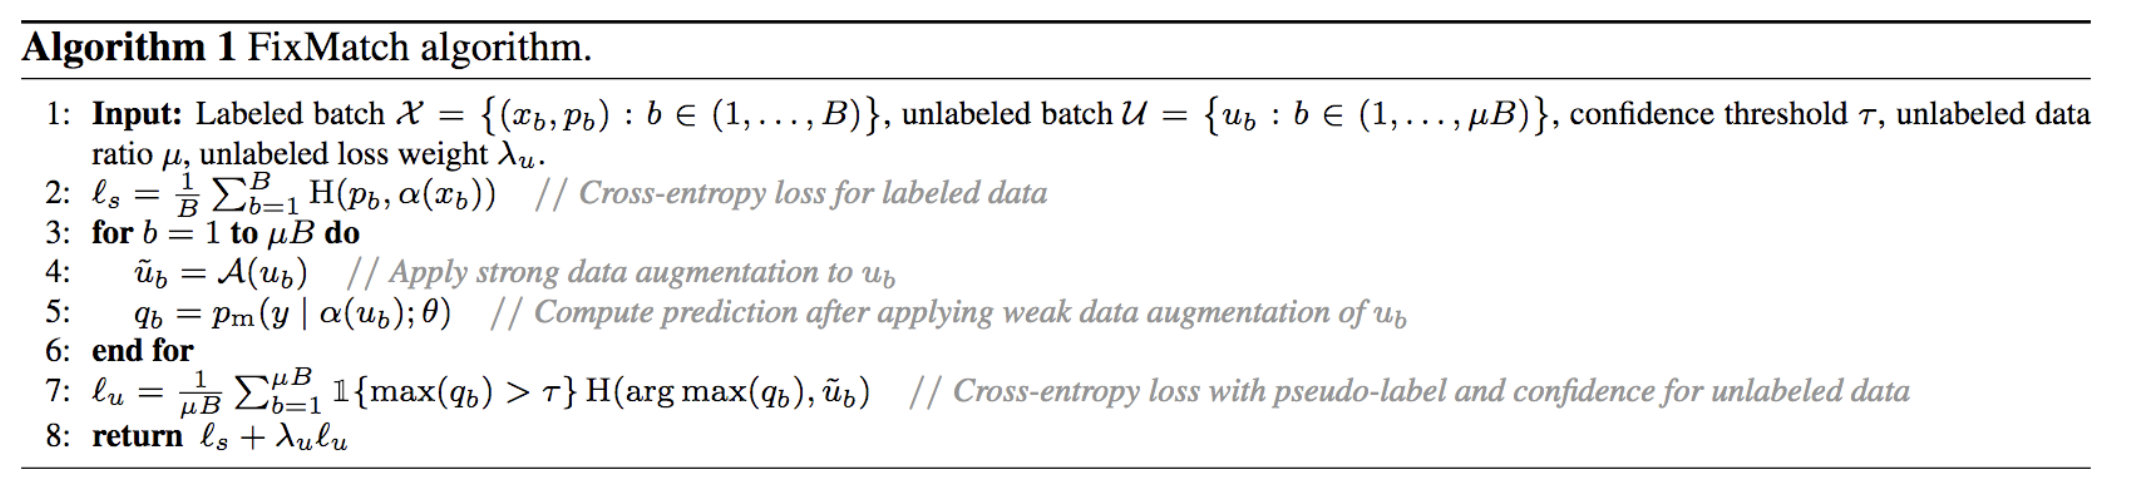

In [48]:
from IPython.display import Image, display
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TPIA3_3/images/fixmatchAlgo.png",width=1100))

 - ligne 4, on fait passer dans le réseau les données fortement augmentées.
 - ligne 7, la cross-entropy H est calculée entre les targets, pseudo-labels obtenues avec argmax sur $q_b$ 
 - les logits obtenus le sont via la passe forward sur les données fortement augmentées.

In [49]:
def sup_prepare_batch(batch, device, non_blocking):
    x = batch["image"].to(device, non_blocking=non_blocking)
    y = batch["target"].to(device, non_blocking=non_blocking)
    return x, y

In [50]:
# Cette fonction crée un itérateur infini sur ton dataloader, 
# qui renvoie les batchs en boucle sans jamais s’arrêter.
# cycle donne un flux infini de batchs, 
def cycle(dataloader):
    while True:
        for b in dataloader:
            yield b

# Chaque appel à step() consomme un batch supervisé et un batch non supervisé.
def fixMatchstepAlgo(
                model, 
                sup_criterion, 
                unsup_criterion,
                optimizer, 
                lr_scheduler, 
                supervised_train_loader_iter, 
                unsupervised_train_loader_iter, 
                epoch,
                num_epochs,
                confidence_threshold,
                lambda_u,
                device,
                tau_start, 
                tau_end,
                warmup_epochs,
            ):
    # 1. Mise en mode train et reset des gradients
    model.train()
    optimizer.zero_grad()

    # ----- partie supervisée -----
    # 2. Partie supervisée (batch labellisé)
    sup_batch = next(supervised_train_loader_iter) # weak_transforms supervised
    x, y = sup_prepare_batch(sup_batch, device, non_blocking=True) # x= image , y =target
    y_pred = model(x) # prédiction de classe 
    sup_loss = sup_criterion(y_pred, y)   # scalaire = loss prédiction sur la prédiction

    # ----- partie pseudo-labeling (FixMatch) -----
    # 3. Partie non supervisée (FixMatch, pseudo‑labels)
    unsup_batch = next(unsupervised_train_loader_iter) # batch strong_aug_transforms unsupervised
    weak_x = unsup_batch["image"].to(device, non_blocking=True) # tensor image
    # weak_x.shape : torch.Size([896, 3, 32, 32])
    strong_x = unsup_batch["strong_aug"].to(device, non_blocking=True) # tensor augmentation
    # strong_x.shape : torch.Size([896, 3, 32, 32])

    # logits sur weak et strong
    # On obtient les logits sur weak et strong pour le même batch d’images.
    y_weak_logits = model(weak_x)  # retourne prédiction classes les images du batch weakly modified
    # print(f'y_weak_logits.shape : {y_weak_logits.shape}')     # y_weak_logits.shape : torch.Size([896, 10])
    y_strong_logits = model(strong_x)           # retourne la prédiction liée à la déformation
    # print(f'y_strong_logits.shape : {y_strong_logits.shape}') # y_strong_logits.shape : torch.Size([896, 10])

    # 1) pseudo-labels à partir des weak
    y_weak_probs = torch.softmax(y_weak_logits, dim=1)  
    # print(f'y_weak_probs.shape : {y_weak_probs.shape}') # y_weak_probs.shape : torch.Size([896, 10])
    y_pseudo = torch.argmax(y_weak_probs, dim=1)    
    # print(f'y_pseudo.shape : {y_pseudo.shape}') # y_pseudo.shape : torch.Size([896])
    # seuil dynamique
    tau = tau_start + (tau_end - tau_start) * epoch / num_epochs
    # 2) confiance de la classe prédite
    max_probs = y_weak_probs.gather(1, y_pseudo.unsqueeze(1)).squeeze(1)  # (B,)
    # print(f'max_probs.shape : {max_probs.shape}') # max_probs.shape : torch.Size([896])
    # seuil dynamique

    import random
    if random.random() < 0.001:  # log aléatoire, très rare
        print("max_probs mean:", max_probs.mean().item(), "max:", max_probs.max().item())
    #else:
    #    print("max_probs mean:", max_probs.mean().item(), "max:", max_probs.max().item())

    confidence_threshold = tau_start + (tau_end - tau_start) * epoch / num_epochs
    #print(f"confidence_threshold : {confidence_threshold}")
    unsup_loss_mask = max_probs >= confidence_threshold  # (B,) bool

    density = unsup_loss_mask.float().mean().item()
    if random.random() < 0.001:
        print(f"unsup_density : {density:.6f}")

    #unsup_loss_mask = max_probs >= confidence_threshold                   # (B,) bool
    # print(f'unsup_loss_mask[:10] : {unsup_loss_mask[:10]}') #[False, True,... False, False]
    # 3) loss non supervisée par échantillon
    per_sample_unsup_loss = unsup_criterion(y_strong_logits, y_pseudo)    # (B,)

    # 4) unsup_loss_mask filtre les pseudo‑labels confiants, puis :
    #    garde seulement les échantillons confiants et moyenne
    #    True si au moins un échantillon du batch est confiant.
    #    False si aucun échantillon ne dépasse le seuil de confiance
    if unsup_loss_mask.any(): # retourne un scalaire booléen
        unsup_loss = per_sample_unsup_loss[unsup_loss_mask].mean()
    else:
        unsup_loss = torch.tensor(0.0, device=device)

    if epoch < warmup_epochs:
        lambda_u_eff = 0.0
    else:
        lambda_u_eff = lambda_u
    
    # ----- loss totale -----
    total_loss = sup_loss + lambda_u_eff * unsup_loss    # scalaire

    total_loss.backward()
    optimizer.step()
    lr_scheduler.step()

    return {
    "total_loss": total_loss.item(),
    "sup_loss": sup_loss.item(),
    "unsup_loss": unsup_loss.item(),
    "non_zero_unsup_loss_density": unsup_loss_mask.float().mean().item(),
    }

### `1.8 Test`
`Accuracy`.  
 - cette fonction calcule la précision « top‑k »,
 - c’est‑à‑dire le % d’images dont la vraie classe est dans les k prédictions les plus probables du modèle.
`output.topk(maxk, dim=1, largest=True, sorted=True)` 
Le tenseur output de taille (batch_size, num_classes) contient les scores (logits) de chaque classe :
 - la fonction topk, pour tout élément du batch, prends les maxk classes ayant les plus grands scores et retourne les indices.
 - on écrit _, pred = ..., implique que l'on ne conserve que les indices des classes dans pred.
 - si maxk = 5, alors pour tout élément du batch on obtient les indices des 5 classes les plus probables.

On transpose pour avoir pred de forme (maxk,batch_size) : 
 - chaque colonne = un exemple, 
 - chaque ligne = la 1re, 2e, ..., k‑ème meilleure prédiction. 

__`précision en pourcentage d’exemples pour lesquels la classe prédite la plus probable est exactement le label vrai`__
 - __prec1__ : pourcentage pour lequel la classe prédite la plus probable est exactement le label vrai.
 - __prec5__ : pourcentage pour lequel le label vrai est dans les 5 classes les plus probables du modèle`.

In [51]:
def accuracy(output, target, topk=(1,)):
    """Computes the precision@k for the specified values of k"""
    maxk = max(topk)
    batch_size = target.size(0)
    # output: (batch_size, num_classes)
    # la fonction topk les retourne les maxk plus grands scores sur la dimension des classes (dim=1),
    # et les indices de ces scores (c’est‑à‑dire les indices de classes).
    # pred: (batch_size, maxk) sont les indices des maxk classes les plus probables
    _, pred = output.topk(maxk, 1, True, True)
    # on transpose pour obtenir (maxk, batch_size)
    pred = pred.t()
    # target: (batch_size,) -> reshape en (1, batch_size)
    # expand_as(pred): (maxk, batch_size)
    # correct: booléen, True si la target est dans le top-k
    correct = pred.eq(target.reshape(1, -1).expand_as(pred))

    res = []
    for k in topk:
        # on ne garde que les k premières lignes (top-k)
        # puis on aplatit, convertit en float (True=1, False=0) et on somme    
        correct_k = correct[:k].reshape(-1).float().sum(0)
       # pourcentage d’exemples corrects dans le batch 
        res.append(correct_k.mul_(100.0 / batch_size))
    return res

def test(device, sup_criterion, test_loader, model, epoch):
    test_loss = 0.0
    top1 = 0.0
    top5 = 0.0

    with torch.no_grad():
        for batch_idx, dico in enumerate(test_loader):
            model.eval()

            inputs = dico["image"]
            targets = dico["target"]
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            loss = sup_criterion(outputs, targets)

            prec1, prec5 = accuracy(outputs, targets, topk=(1, 5))
            test_loss += loss.item()
            top1 += prec1.item()
            top5 += prec5.item()
            """
            print("Test Iter: {batch:4}/{iter:4}. Loss: {loss:.4f}. top1: {top1:.2f}. top5: {top5:.2f}. ".format(
                     batch=batch_idx + 1,
                     iter=len(test_loader),
                     loss=test_loss,
                     top1=top1,
                     top5=top5,
             ))
             """

    print("test top-1 acc: {:.2f} % pour lesquel la classe prédite la plus probable est exactement le label vrai".format(top1/len(test_loader)))
    print("test top-5 acc: {:.2f} % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle".format(top5/len(test_loader)))
    return test_loss/len(test_loader), top1/len(test_loader)

### `1.9 Apprentissage`

#### __`Phase d'apprentissage`__
:::
__`Lancement de la procédure de test avant l'entrainement du modèle ?`__.  
 - C’est une pratique standard en entraînement de modèles :
 - On mesure la performance du modèle à l’état initial (poids aléatoires, ou pretrained non fine‑tuné).
 - Ensuite, à chaque epoch, on appelle le test(...) pour suivre l'évolution de la performance.
 - Cela permet de tracer un graphe epoch → accuracy où le point epoch=0 est la baseline.
:::
:::
__`REMARQUE:`__    
 - `Les valeurs de loss s'accumulent au cours des mini-batchs,` 
 - `c'est la raison pour laquelle, elles augmentent au cours des epochs!`
:::

In [ ]:
import time

def train_model(model, 
                modelName,
                sup_criterion, 
                unsup_criterion,
                optimizer,
                lr_scheduler,
                supervised_train_loader_iter,
                unsupervised_train_loader_iter, 
                num_epochs,
                confidence_threshold,
                lambda_u,
                device,
                tau_start, 
                tau_end,
                warmup_epochs,
                test_loader,
                epoch_length,               
                initial_epoch=0):
    

    print(f'############# Débul du calcul de la performance du modèle {modelName} à l\'état initial #####################')
    test_loss, test_top1_acc = test(device, sup_criterion, test_loader, model, initial_epoch)
    print(f'############# Début de l\'apprentissage modèle {modelName} #####################')


    for epoch in range(1,num_epochs+1):
        epoch_total_loss, epoch_sup_loss, epoch_unsup_loss  = 0., 0., 0.
        epoch_mask_density = 0.0
        n_logs = 0

        for it in range(epoch_length):
            t0 = time.time()
            dico = fixMatchstepAlgo(
                        model, 
                        sup_criterion, 
                        unsup_criterion,
                        optimizer, 
                        lr_scheduler, 
                        supervised_train_loader_iter, 
                        unsupervised_train_loader_iter, 
                        epoch,
                        num_epochs,
                        confidence_threshold,
                        lambda_u,
                        device,
                        tau_start, 
                        tau_end,
                        warmup_epochs
                         )
            dt = time.time() - t0
            if it % 10 == 0:
                #print(f"[DEBUG] it={it}/{epoch_length}, dt={dt:.3f}s")
                epoch_total_loss += dico["total_loss"]
                epoch_sup_loss += dico["sup_loss"]
                epoch_unsup_loss += dico["unsup_loss"]
                epoch_mask_density += dico["non_zero_unsup_loss_density"]
                n_logs += 1

        
                if it % 1000 == 0:
                    print("Batch: {it}/{epoch_length:4} --- Loss: {epoch_total_loss:.5f} sup_loss: {epoch_sup_loss:.5f} unsup_loss: {epoch_unsup_loss:.5f}".format(
                        it=it,
                        epoch_length=epoch_length,
                        epoch_total_loss=epoch_total_loss,
                        epoch_sup_loss=epoch_sup_loss,
                        epoch_unsup_loss=epoch_unsup_loss
                        ))

        # ICI, après la boucle, on fait les moyennes sur l’epoch
        epoch_total_loss /= max(1, n_logs)
        epoch_sup_loss   /= max(1, n_logs)
        epoch_unsup_loss /= max(1, n_logs)
        epoch_mask_density /= max(1, n_logs)
        
        print(f"mean non_zero_unsup_loss_density: {epoch_mask_density:.6f}")
        print("Train Epoch: {epoch}/{num_epochs:4} --- Loss: {epoch_total_loss:.5f} sup_loss: {epoch_sup_loss:.5f} unsup_loss: {epoch_unsup_loss:.5f}".format(
                    epoch=epoch+1,
                    num_epochs=num_epochs,
                    epoch_total_loss=epoch_total_loss,
                    epoch_sup_loss=epoch_sup_loss,
                    epoch_unsup_loss=epoch_unsup_loss
                )
            )
        print(f"############# Début du test modèle {modelName} ################################")
        test_loss, test_top1_acc = test(device, sup_criterion, test_loader, model, epoch)

### `1.9 Instantiation du modèle WideResnet`

In [ ]:
weight_decay = 0.0005

confidence_threshold = 0.95
# Passer à lambda_u = 0.1 ou 0.2 pour voir si l’accuracy monte plus vite ou plus haut avec 16–50 epochs.
# l’unsup pèse moins que dans FixMatch original (1.0), 
# ce qui est raisonnable pour un modèle plus petit comme ton ResNet18.
lambda_u = 0.5 
# les 5 premiers epochs quasi purement supervisés ce qui laisse au modèle le temps 
# d’apprendre des features utiles avant de faire confiance aux pseudo‑labels.
warmup_epochs = 5 
# seuil très strict → densité de pseudo‑labels plus basse
tau_start, tau_end = 0.9,0.95 

sup_criterion = nn.CrossEntropyLoss()
unsup_criterion = nn.CrossEntropyLoss(reduction='none')

num_epochs = 128  # orginally 1024
# budget déjà conséquent; converge mieux que 16–20 epochs, 
# même si FixMatch original pousse encore plus loin.
epoch_length = 65536 // batch_size
K = num_epochs * epoch_length

supervised_train_loader_iter = cycle(supervised_train_loader) # weak_transforms supervised
unsupervised_train_loader_iter = cycle(unsupervised_train_loader) # Weak + strong_aug_transforms unsupervised

`Le seuil (confidence_threshold)`.   
  - sert à décider une classe à partir d’un score (par ex. probabilité ≥ 0.5 → classe positive). 
 - Il intervient au niveau de la décision / métriques (ROC, PR, etc.).

`Le weight_decay` 
 - c'est un terme de régularisation dans l’optimiseur, qui pénalise les grands poids pendant l’entraînement (L2).
 - trop grand → les poids sont trop contraints → sous‑apprentissage possible.
 - trop petit (ou 0) → risque plus élevé d’overfitting, surtout avec peu de données ou un modèle très expressif.

In [ ]:
modelWideResNet = WideResNet(num_classes=10).to(device)

if torch.cuda.device_count() > 1:
    modelWideResNet = nn.parallel.DataParallel(modelWideResNet)

optimizer = optim.SGD(modelWideResNet.parameters(), lr=0.03, momentum=0.9, nesterov=True, weight_decay=weight_decay)
print(f'nombre de paramètre du modèle WideResNet : {sum([p.numel() for p in modelWideResNet.parameters()])}')
lr_scheduler = lrs.CosineAnnealingLR(optimizer, K)    

train_model(modelWideResNet, 
            "WideResNet",
            sup_criterion, 
            unsup_criterion,
            optimizer,
            lr_scheduler,
            supervised_train_loader_iter,
            unsupervised_train_loader_iter, 
            num_epochs,
            confidence_threshold,
            lambda_u,
            device,
            tau_start, 
            tau_end,
            warmup_epochs,
            test_loader,
            epoch_length,               
            initial_epoch=0
            )

nombre de paramètre du modèle WideResNet : 1469642
############# Débul du calcul de la performance du modèle WideResNet à l'état initial #####################
test top-1 acc: 10.04 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 48.25 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
############# Début de l'apprentissage modèle WideResNet #####################
Batch: 0/1024 --- Loss: 2.32512 sup_loss: 2.32512 unsup_loss: 0.00000
unsup_density : 0.000000
max_probs mean: 0.7232680320739746 max: 0.9998880624771118
unsup_density : 0.406250
Batch: 1000/1024 --- Loss: 45.08072 sup_loss: 45.08072 unsup_loss: 293.95711
mean non_zero_unsup_loss_density: 0.324268
Train Epoch: 2/ 128 --- Loss: 0.43805 sup_loss: 0.43805 unsup_loss: 2.93713
############# Début du test modèle WideResNet ################################
test top-1 acc: 36.08 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 86.40 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.00740 sup_loss: 0.00740 unsup_loss: 3.81904
max_probs mean: 0.8362463116645813 max: 0.9999998807907104
unsup_density : 0.526786
Batch: 1000/1024 --- Loss: 1.16730 sup_loss: 1.16730 unsup_loss: 422.08037
mean non_zero_unsup_loss_density: 0.536104
Train Epoch: 3/ 128 --- Loss: 0.01137 sup_loss: 0.01137 unsup_loss: 4.17659
############# Début du test modèle WideResNet ################################
test top-1 acc: 37.16 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 85.42 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.00086 sup_loss: 0.00086 unsup_loss: 3.93268
unsup_density : 0.542411
unsup_density : 0.502232
Batch: 1000/1024 --- Loss: 1.05290 sup_loss: 1.05290 unsup_loss: 401.83641
max_probs mean: 0.8352064490318298 max: 1.0
mean non_zero_unsup_loss_density: 0.524944
Train Epoch: 4/ 128 --- Loss: 0.01027 sup_loss: 0.01027 unsup_loss: 3.97319
############# Début du test modèle WideResNet ################################
test top-1 acc: 33.76 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 84.11 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.00254 sup_loss: 0.00254 unsup_loss: 3.59932
max_probs mean: 0.8329758644104004 max: 1.0
max_probs mean: 0.8252458572387695 max: 0.9999997615814209
unsup_density : 0.537946
Batch: 1000/1024 --- Loss: 0.13534 sup_loss: 0.13534 unsup_loss: 383.97523
mean non_zero_unsup_loss_density: 0.526092
Train Epoch: 5/ 128 --- Loss: 0.00135 sup_loss: 0.00135 unsup_loss: 3.79822
############# Début du test modèle WideResNet ################################
test top-1 acc: 36.82 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 84.68 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 1.74966 sup_loss: 0.00144 unsup_loss: 3.49643
max_probs mean: 0.6806925535202026 max: 0.9998912811279297
unsup_density : 0.281250
max_probs mean: 0.7382331490516663 max: 0.999962329864502
Batch: 1000/1024 --- Loss: 57.33111 sup_loss: 5.78474 unsup_loss: 103.09275
mean non_zero_unsup_loss_density: 0.390798
Train Epoch: 6/ 128 --- Loss: 0.56538 sup_loss: 0.05632 unsup_loss: 1.01813
############# Début du test modèle WideResNet ################################
test top-1 acc: 41.28 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 87.80 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.53578 sup_loss: 0.07642 unsup_loss: 0.91871
max_probs mean: 0.8073630928993225 max: 0.9999996423721313
max_probs mean: 0.8335410356521606 max: 1.0
max_probs mean: 0.8111920356750488 max: 1.0
Batch: 1000/1024 --- Loss: 49.93668 sup_loss: 1.98475 unsup_loss: 95.90386
mean non_zero_unsup_loss_density: 0.509644
Train Epoch: 7/ 128 --- Loss: 0.49454 sup_loss: 0.01954 unsup_loss: 0.95000
############# Début du test modèle WideResNet ################################
test top-1 acc: 31.93 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.52 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.47988 sup_loss: 0.00934 unsup_loss: 0.94107
Batch: 1000/1024 --- Loss: 45.13338 sup_loss: 1.10259 unsup_loss: 88.06159
max_probs mean: 0.8365206122398376 max: 0.9999997615814209
mean non_zero_unsup_loss_density: 0.549150
Train Epoch: 8/ 128 --- Loss: 0.44644 sup_loss: 0.01163 unsup_loss: 0.86962
############# Début du test modèle WideResNet ################################
test top-1 acc: 44.50 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 90.95 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.42956 sup_loss: 0.02550 unsup_loss: 0.80812
Batch: 1000/1024 --- Loss: 42.66497 sup_loss: 1.15080 unsup_loss: 83.02834
mean non_zero_unsup_loss_density: 0.552900
Train Epoch: 9/ 128 --- Loss: 0.42176 sup_loss: 0.01146 unsup_loss: 0.82060
############# Début du test modèle WideResNet ################################
test top-1 acc: 45.66 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.15 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.42133 sup_loss: 0.00883 unsup_loss: 0.82502
max_probs mean: 0.8350940346717834 max: 1.0
Batch: 1000/1024 --- Loss: 41.68512 sup_loss: 1.16773 unsup_loss: 81.03476
mean non_zero_unsup_loss_density: 0.559726
Train Epoch: 10/ 128 --- Loss: 0.41342 sup_loss: 0.01143 unsup_loss: 0.80397
############# Début du test modèle WideResNet ################################
test top-1 acc: 52.94 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 92.19 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.39672 sup_loss: 0.00722 unsup_loss: 0.77900
unsup_density : 0.604911
max_probs mean: 0.8435216546058655 max: 0.9999997615814209
Batch: 1000/1024 --- Loss: 37.49222 sup_loss: 0.83906 unsup_loss: 73.30632
mean non_zero_unsup_loss_density: 0.569370
Train Epoch: 11/ 128 --- Loss: 0.37061 sup_loss: 0.00819 unsup_loss: 0.72485
############# Début du test modèle WideResNet ################################
test top-1 acc: 50.83 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 91.14 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.45080 sup_loss: 0.00140 unsup_loss: 0.89879
unsup_density : 0.578125
Batch: 1000/1024 --- Loss: 37.22756 sup_loss: 0.91480 unsup_loss: 72.62553
mean non_zero_unsup_loss_density: 0.578450
Train Epoch: 12/ 128 --- Loss: 0.36841 sup_loss: 0.00895 unsup_loss: 0.71891
############# Début du test modèle WideResNet ################################
test top-1 acc: 51.82 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 92.48 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.36697 sup_loss: 0.00159 unsup_loss: 0.73076
unsup_density : 0.575893
max_probs mean: 0.8689410090446472 max: 1.0
Batch: 1000/1024 --- Loss: 35.62913 sup_loss: 0.85017 unsup_loss: 69.55793
mean non_zero_unsup_loss_density: 0.582373
Train Epoch: 13/ 128 --- Loss: 0.35321 sup_loss: 0.00844 unsup_loss: 0.68954
############# Début du test modèle WideResNet ################################
test top-1 acc: 50.84 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 91.03 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.33059 sup_loss: 0.02372 unsup_loss: 0.61374
unsup_density : 0.575893
max_probs mean: 0.8500242233276367 max: 0.9999997615814209
Batch: 1000/1024 --- Loss: 34.81702 sup_loss: 0.93158 unsup_loss: 67.77088
mean non_zero_unsup_loss_density: 0.583326
Train Epoch: 14/ 128 --- Loss: 0.34383 sup_loss: 0.00913 unsup_loss: 0.66939
############# Début du test modèle WideResNet ################################
test top-1 acc: 58.07 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 91.69 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.27067 sup_loss: 0.00080 unsup_loss: 0.53974
max_probs mean: 0.83726567029953 max: 0.9999997615814209
unsup_density : 0.593750
Batch: 1000/1024 --- Loss: 33.78378 sup_loss: 0.90187 unsup_loss: 65.76384
mean non_zero_unsup_loss_density: 0.585840
Train Epoch: 15/ 128 --- Loss: 0.33588 sup_loss: 0.00931 unsup_loss: 0.65316
############# Début du test modèle WideResNet ################################
test top-1 acc: 54.41 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 90.96 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.36844 sup_loss: 0.00694 unsup_loss: 0.72301
unsup_density : 0.575893
Batch: 1000/1024 --- Loss: 34.13481 sup_loss: 0.77606 unsup_loss: 66.71750
mean non_zero_unsup_loss_density: 0.594357
Train Epoch: 16/ 128 --- Loss: 0.33755 sup_loss: 0.00762 unsup_loss: 0.65985
############# Début du test modèle WideResNet ################################
test top-1 acc: 54.33 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 93.15 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.33231 sup_loss: 0.00394 unsup_loss: 0.65675
max_probs mean: 0.8653255105018616 max: 0.9999996423721313
max_probs mean: 0.8577966690063477 max: 1.0
Batch: 1000/1024 --- Loss: 32.95170 sup_loss: 0.77680 unsup_loss: 64.34979
mean non_zero_unsup_loss_density: 0.592168
Train Epoch: 17/ 128 --- Loss: 0.32575 sup_loss: 0.00758 unsup_loss: 0.63633
############# Début du test modèle WideResNet ################################
test top-1 acc: 56.11 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 93.27 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.28054 sup_loss: 0.00405 unsup_loss: 0.55298
max_probs mean: 0.8558254837989807 max: 0.9999996423721313
Batch: 1000/1024 --- Loss: 31.98963 sup_loss: 0.60637 unsup_loss: 62.76651
max_probs mean: 0.856079638004303 max: 1.0
mean non_zero_unsup_loss_density: 0.601508
Train Epoch: 18/ 128 --- Loss: 0.31694 sup_loss: 0.00596 unsup_loss: 0.62196
############# Début du test modèle WideResNet ################################
test top-1 acc: 60.09 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 94.16 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.31290 sup_loss: 0.00349 unsup_loss: 0.61881
unsup_density : 0.546875
unsup_density : 0.573661
Batch: 1000/1024 --- Loss: 32.24973 sup_loss: 0.88490 unsup_loss: 62.72966
mean non_zero_unsup_loss_density: 0.596741
Train Epoch: 19/ 128 --- Loss: 0.32027 sup_loss: 0.00871 unsup_loss: 0.62313
############# Début du test modèle WideResNet ################################
test top-1 acc: 54.90 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.54 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.33206 sup_loss: 0.00522 unsup_loss: 0.65368
Batch: 1000/1024 --- Loss: 32.00825 sup_loss: 0.95483 unsup_loss: 62.10683
mean non_zero_unsup_loss_density: 0.596676
Train Epoch: 20/ 128 --- Loss: 0.31657 sup_loss: 0.00939 unsup_loss: 0.61436
############# Début du test modèle WideResNet ################################
test top-1 acc: 55.03 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 94.02 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.29585 sup_loss: 0.00454 unsup_loss: 0.58262
unsup_density : 0.609375
Batch: 1000/1024 --- Loss: 30.94431 sup_loss: 0.63693 unsup_loss: 60.61476
mean non_zero_unsup_loss_density: 0.606406
Train Epoch: 21/ 128 --- Loss: 0.30565 sup_loss: 0.00623 unsup_loss: 0.59885
############# Début du test modèle WideResNet ################################
test top-1 acc: 59.22 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 94.05 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.26208 sup_loss: 0.00163 unsup_loss: 0.52090
max_probs mean: 0.8288699984550476 max: 0.9999991655349731
Batch: 1000/1024 --- Loss: 30.60465 sup_loss: 0.63516 unsup_loss: 59.93898
mean non_zero_unsup_loss_density: 0.602310
Train Epoch: 22/ 128 --- Loss: 0.30249 sup_loss: 0.00622 unsup_loss: 0.59254
############# Début du test modèle WideResNet ################################
test top-1 acc: 56.31 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 91.39 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.30310 sup_loss: 0.00492 unsup_loss: 0.59636
max_probs mean: 0.8628821969032288 max: 1.0
Batch: 1000/1024 --- Loss: 30.06788 sup_loss: 0.62699 unsup_loss: 58.88177
mean non_zero_unsup_loss_density: 0.608140
Train Epoch: 23/ 128 --- Loss: 0.29753 sup_loss: 0.00613 unsup_loss: 0.58279
############# Début du test modèle WideResNet ################################
test top-1 acc: 56.38 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 95.25 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.37000 sup_loss: 0.00092 unsup_loss: 0.73816
unsup_density : 0.584821
unsup_density : 0.604911
Batch: 1000/1024 --- Loss: 30.41212 sup_loss: 0.86368 unsup_loss: 59.09688
mean non_zero_unsup_loss_density: 0.604347
Train Epoch: 24/ 128 --- Loss: 0.30099 sup_loss: 0.00857 unsup_loss: 0.58484
############# Début du test modèle WideResNet ################################
test top-1 acc: 52.97 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 93.11 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.32123 sup_loss: 0.00608 unsup_loss: 0.63029
unsup_density : 0.613839
Batch: 1000/1024 --- Loss: 29.12316 sup_loss: 0.51916 unsup_loss: 57.20799
mean non_zero_unsup_loss_density: 0.614901
Train Epoch: 25/ 128 --- Loss: 0.28905 sup_loss: 0.00527 unsup_loss: 0.56756
############# Début du test modèle WideResNet ################################
test top-1 acc: 54.39 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 91.10 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.25236 sup_loss: 0.00643 unsup_loss: 0.49187
max_probs mean: 0.8515705466270447 max: 0.9999997615814209
Batch: 1000/1024 --- Loss: 29.03998 sup_loss: 0.66892 unsup_loss: 56.74211
mean non_zero_unsup_loss_density: 0.616982
Train Epoch: 26/ 128 --- Loss: 0.28748 sup_loss: 0.00663 unsup_loss: 0.56171
############# Début du test modèle WideResNet ################################
test top-1 acc: 56.08 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 90.85 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.33165 sup_loss: 0.00430 unsup_loss: 0.65469
max_probs mean: 0.8585640788078308 max: 0.9999997615814209
Batch: 1000/1024 --- Loss: 28.54338 sup_loss: 0.39125 unsup_loss: 56.30426
mean non_zero_unsup_loss_density: 0.615335
Train Epoch: 27/ 128 --- Loss: 0.28314 sup_loss: 0.00405 unsup_loss: 0.55818
############# Début du test modèle WideResNet ################################
test top-1 acc: 57.99 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 93.98 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.22255 sup_loss: 0.00358 unsup_loss: 0.43794
max_probs mean: 0.8879297971725464 max: 0.9999997615814209
max_probs mean: 0.8492712378501892 max: 0.9999992847442627
Batch: 1000/1024 --- Loss: 29.98904 sup_loss: 0.67251 unsup_loss: 58.63305
mean non_zero_unsup_loss_density: 0.612561
Train Epoch: 28/ 128 --- Loss: 0.29625 sup_loss: 0.00659 unsup_loss: 0.57932
############# Début du test modèle WideResNet ################################
test top-1 acc: 55.44 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 92.82 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.28143 sup_loss: 0.00137 unsup_loss: 0.56011
max_probs mean: 0.8737679719924927 max: 1.0
max_probs mean: 0.8615665435791016 max: 0.9999995231628418
max_probs mean: 0.8817768692970276 max: 0.9999988079071045
unsup_density : 0.595982
unsup_density : 0.584821
Batch: 1000/1024 --- Loss: 29.77611 sup_loss: 0.65697 unsup_loss: 58.23828
mean non_zero_unsup_loss_density: 0.615681
Train Epoch: 29/ 128 --- Loss: 0.29449 sup_loss: 0.00645 unsup_loss: 0.57609
############# Début du test modèle WideResNet ################################
test top-1 acc: 61.21 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 94.39 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.29600 sup_loss: 0.00355 unsup_loss: 0.58490
max_probs mean: 0.8854249119758606 max: 0.999998927116394
unsup_density : 0.580357
Batch: 1000/1024 --- Loss: 28.51173 sup_loss: 0.57104 unsup_loss: 55.88139
mean non_zero_unsup_loss_density: 0.618109
Train Epoch: 30/ 128 --- Loss: 0.28307 sup_loss: 0.00596 unsup_loss: 0.55421
############# Début du test modèle WideResNet ################################
test top-1 acc: 54.18 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 92.44 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.32928 sup_loss: 0.00322 unsup_loss: 0.65211
max_probs mean: 0.8672951459884644 max: 1.0
max_probs mean: 0.8668282628059387 max: 1.0
Batch: 1000/1024 --- Loss: 28.64766 sup_loss: 0.60495 unsup_loss: 56.08543
mean non_zero_unsup_loss_density: 0.616483
Train Epoch: 31/ 128 --- Loss: 0.28350 sup_loss: 0.00592 unsup_loss: 0.55517
############# Début du test modèle WideResNet ################################
test top-1 acc: 56.44 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 92.50 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.28949 sup_loss: 0.00470 unsup_loss: 0.56958
unsup_density : 0.642857
Batch: 1000/1024 --- Loss: 28.09640 sup_loss: 0.41538 unsup_loss: 55.36202
mean non_zero_unsup_loss_density: 0.623288
Train Epoch: 32/ 128 --- Loss: 0.27817 sup_loss: 0.00405 unsup_loss: 0.54824
############# Début du test modèle WideResNet ################################
test top-1 acc: 64.92 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 95.22 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.25336 sup_loss: 0.00218 unsup_loss: 0.50236
unsup_density : 0.649554
max_probs mean: 0.8638395071029663 max: 0.9999996423721313
Batch: 1000/1024 --- Loss: 27.41070 sup_loss: 0.50178 unsup_loss: 53.81785
mean non_zero_unsup_loss_density: 0.622616
Train Epoch: 33/ 128 --- Loss: 0.27129 sup_loss: 0.00491 unsup_loss: 0.53276
############# Début du test modèle WideResNet ################################
test top-1 acc: 63.77 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 95.50 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.30796 sup_loss: 0.00294 unsup_loss: 0.61004
unsup_density : 0.609375
max_probs mean: 0.8821381330490112 max: 0.9999998807907104
unsup_density : 0.591518
max_probs mean: 0.8750405311584473 max: 1.0
Batch: 1000/1024 --- Loss: 27.39317 sup_loss: 0.56762 unsup_loss: 53.65110
mean non_zero_unsup_loss_density: 0.626820
Train Epoch: 34/ 128 --- Loss: 0.27081 sup_loss: 0.00556 unsup_loss: 0.53051
############# Début du test modèle WideResNet ################################
test top-1 acc: 65.21 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 95.19 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.26590 sup_loss: 0.00288 unsup_loss: 0.52603
unsup_density : 0.638393
unsup_density : 0.633929
unsup_density : 0.645089
unsup_density : 0.569196
Batch: 1000/1024 --- Loss: 27.45798 sup_loss: 0.62378 unsup_loss: 53.66841
mean non_zero_unsup_loss_density: 0.618022
Train Epoch: 35/ 128 --- Loss: 0.27164 sup_loss: 0.00610 unsup_loss: 0.53108
############# Début du test modèle WideResNet ################################
test top-1 acc: 57.58 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 93.69 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.26146 sup_loss: 0.00146 unsup_loss: 0.52000
Batch: 1000/1024 --- Loss: 25.33213 sup_loss: 0.30264 unsup_loss: 50.05898
mean non_zero_unsup_loss_density: 0.632650
Train Epoch: 36/ 128 --- Loss: 0.25101 sup_loss: 0.00300 unsup_loss: 0.49601
############# Début du test modèle WideResNet ################################
test top-1 acc: 56.62 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 91.69 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.27071 sup_loss: 0.00712 unsup_loss: 0.52719
unsup_density : 0.665179
unsup_density : 0.609375
unsup_density : 0.633929
Batch: 1000/1024 --- Loss: 26.14486 sup_loss: 0.36248 unsup_loss: 51.56475
mean non_zero_unsup_loss_density: 0.634297
Train Epoch: 37/ 128 --- Loss: 0.25902 sup_loss: 0.00355 unsup_loss: 0.51093
############# Début du test modèle WideResNet ################################
test top-1 acc: 62.89 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 94.17 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.27116 sup_loss: 0.00244 unsup_loss: 0.53744
max_probs mean: 0.868953287601471 max: 0.9999994039535522
max_probs mean: 0.8804114460945129 max: 0.9999990463256836
Batch: 1000/1024 --- Loss: 28.01053 sup_loss: 0.63088 unsup_loss: 54.75931
mean non_zero_unsup_loss_density: 0.624220
Train Epoch: 38/ 128 --- Loss: 0.27573 sup_loss: 0.00619 unsup_loss: 0.53908
############# Début du test modèle WideResNet ################################
test top-1 acc: 60.04 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 94.84 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.23636 sup_loss: 0.00335 unsup_loss: 0.46602
unsup_density : 0.609375
unsup_density : 0.654018
max_probs mean: 0.8579960465431213 max: 0.9999995231628418
Batch: 1000/1024 --- Loss: 26.83968 sup_loss: 0.45827 unsup_loss: 52.76283
mean non_zero_unsup_loss_density: 0.628424
Train Epoch: 39/ 128 --- Loss: 0.26628 sup_loss: 0.00463 unsup_loss: 0.52330
############# Début du test modèle WideResNet ################################
test top-1 acc: 60.85 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 94.24 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.24644 sup_loss: 0.00227 unsup_loss: 0.48834
unsup_density : 0.620536
max_probs mean: 0.8688012361526489 max: 0.9999988079071045
unsup_density : 0.627232
unsup_density : 0.560268
Batch: 1000/1024 --- Loss: 27.00829 sup_loss: 0.42659 unsup_loss: 53.16340
mean non_zero_unsup_loss_density: 0.624263
Train Epoch: 40/ 128 --- Loss: 0.26710 sup_loss: 0.00418 unsup_loss: 0.52584
############# Début du test modèle WideResNet ################################
test top-1 acc: 60.45 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 94.02 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.28207 sup_loss: 0.00391 unsup_loss: 0.55632
unsup_density : 0.654018
unsup_density : 0.647059
Batch: 1000/1024 --- Loss: 25.55458 sup_loss: 0.27066 unsup_loss: 50.56783
mean non_zero_unsup_loss_density: 0.638610
Train Epoch: 41/ 128 --- Loss: 0.25336 sup_loss: 0.00283 unsup_loss: 0.50107
############# Début du test modèle WideResNet ################################
test top-1 acc: 62.13 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 94.68 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.26267 sup_loss: 0.00334 unsup_loss: 0.51867
Batch: 1000/1024 --- Loss: 26.71823 sup_loss: 0.69603 unsup_loss: 52.04438
mean non_zero_unsup_loss_density: 0.626517
Train Epoch: 42/ 128 --- Loss: 0.26487 sup_loss: 0.00678 unsup_loss: 0.51617
############# Début du test modèle WideResNet ################################
test top-1 acc: 64.09 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 95.63 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.22832 sup_loss: 0.00138 unsup_loss: 0.45389
max_probs mean: 0.889208972454071 max: 0.9999979734420776
unsup_density : 0.638393
Batch: 1000/1024 --- Loss: 24.58314 sup_loss: 0.29032 unsup_loss: 48.58564
mean non_zero_unsup_loss_density: 0.647148
Train Epoch: 43/ 128 --- Loss: 0.24374 sup_loss: 0.00293 unsup_loss: 0.48162
############# Début du test modèle WideResNet ################################
test top-1 acc: 64.55 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 95.38 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.26234 sup_loss: 0.00081 unsup_loss: 0.52306
unsup_density : 0.662946
max_probs mean: 0.8722304105758667 max: 0.9999988079071045
Batch: 1000/1024 --- Loss: 25.35425 sup_loss: 0.64165 unsup_loss: 49.42519
mean non_zero_unsup_loss_density: 0.630353
Train Epoch: 44/ 128 --- Loss: 0.25085 sup_loss: 0.00625 unsup_loss: 0.48920
############# Début du test modèle WideResNet ################################
test top-1 acc: 64.05 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 95.32 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.26384 sup_loss: 0.00110 unsup_loss: 0.52547
unsup_density : 0.638393
unsup_density : 0.645089
max_probs mean: 0.8520026803016663 max: 0.9999997615814209
unsup_density : 0.631696
max_probs mean: 0.8660057187080383 max: 0.9999991655349731
Batch: 1000/1024 --- Loss: 24.98205 sup_loss: 0.36156 unsup_loss: 49.24097
mean non_zero_unsup_loss_density: 0.640127
Train Epoch: 45/ 128 --- Loss: 0.24736 sup_loss: 0.00355 unsup_loss: 0.48764
############# Début du test modèle WideResNet ################################
test top-1 acc: 61.99 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 95.80 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.25832 sup_loss: 0.00187 unsup_loss: 0.51290
max_probs mean: 0.9008610844612122 max: 0.9999995231628418
max_probs mean: 0.8885588049888611 max: 0.9999998807907104
Batch: 1000/1024 --- Loss: 26.06776 sup_loss: 0.59618 unsup_loss: 50.94317
mean non_zero_unsup_loss_density: 0.631653
Train Epoch: 46/ 128 --- Loss: 0.25811 sup_loss: 0.00588 unsup_loss: 0.50446
############# Début du test modèle WideResNet ################################
test top-1 acc: 59.88 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 93.04 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.30278 sup_loss: 0.00432 unsup_loss: 0.59692
max_probs mean: 0.8965315222740173 max: 0.9999991655349731
Batch: 1000/1024 --- Loss: 24.42409 sup_loss: 0.40151 unsup_loss: 48.04516
mean non_zero_unsup_loss_density: 0.643594
Train Epoch: 47/ 128 --- Loss: 0.24140 sup_loss: 0.00396 unsup_loss: 0.47489
############# Début du test modèle WideResNet ################################
test top-1 acc: 65.76 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 94.72 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.25177 sup_loss: 0.00125 unsup_loss: 0.50104
unsup_density : 0.662946
unsup_density : 0.678571
Batch: 1000/1024 --- Loss: 25.56656 sup_loss: 0.76262 unsup_loss: 49.60787
mean non_zero_unsup_loss_density: 0.635944
Train Epoch: 48/ 128 --- Loss: 0.25217 sup_loss: 0.00759 unsup_loss: 0.48916
############# Début du test modèle WideResNet ################################
test top-1 acc: 62.92 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 95.57 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.24182 sup_loss: 0.00278 unsup_loss: 0.47809
unsup_density : 0.662946
Batch: 1000/1024 --- Loss: 25.08404 sup_loss: 0.50176 unsup_loss: 49.16456
mean non_zero_unsup_loss_density: 0.639888
Train Epoch: 49/ 128 --- Loss: 0.24896 sup_loss: 0.00491 unsup_loss: 0.48810
############# Début du test modèle WideResNet ################################
test top-1 acc: 60.92 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.11 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.24752 sup_loss: 0.00181 unsup_loss: 0.49142
unsup_density : 0.627232
Batch: 1000/1024 --- Loss: 24.19992 sup_loss: 0.34015 unsup_loss: 47.71955
mean non_zero_unsup_loss_density: 0.638740
Train Epoch: 50/ 128 --- Loss: 0.23998 sup_loss: 0.00335 unsup_loss: 0.47327
############# Début du test modèle WideResNet ################################
test top-1 acc: 65.53 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.58 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.23497 sup_loss: 0.00201 unsup_loss: 0.46591
unsup_density : 0.662946
unsup_density : 0.631696
max_probs mean: 0.87750643491745 max: 0.9999996423721313
unsup_density : 0.674107
unsup_density : 0.620536
Batch: 1000/1024 --- Loss: 23.79617 sup_loss: 0.41946 unsup_loss: 46.75343
mean non_zero_unsup_loss_density: 0.642272
Train Epoch: 51/ 128 --- Loss: 0.23551 sup_loss: 0.00412 unsup_loss: 0.46279
############# Début du test modèle WideResNet ################################
test top-1 acc: 56.66 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 95.32 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.27759 sup_loss: 0.00260 unsup_loss: 0.54997
unsup_density : 0.640625
max_probs mean: 0.8737338781356812 max: 0.9999988079071045
Batch: 1000/1024 --- Loss: 24.02065 sup_loss: 0.32108 unsup_loss: 47.39914
mean non_zero_unsup_loss_density: 0.646108
Train Epoch: 52/ 128 --- Loss: 0.23753 sup_loss: 0.00315 unsup_loss: 0.46875
############# Début du test modèle WideResNet ################################
test top-1 acc: 65.55 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 95.67 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.23231 sup_loss: 0.00193 unsup_loss: 0.46075
max_probs mean: 0.8942552208900452 max: 0.9999992847442627
unsup_density : 0.638393
max_probs mean: 0.84771329164505 max: 0.9999966621398926
max_probs mean: 0.8900225758552551 max: 0.9999992847442627
Batch: 1000/1024 --- Loss: 24.02952 sup_loss: 0.45495 unsup_loss: 47.14913
mean non_zero_unsup_loss_density: 0.651396
Train Epoch: 53/ 128 --- Loss: 0.23759 sup_loss: 0.00446 unsup_loss: 0.46626
############# Début du test modèle WideResNet ################################
test top-1 acc: 66.72 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.57 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.23306 sup_loss: 0.00142 unsup_loss: 0.46328
max_probs mean: 0.8817887306213379 max: 0.9999994039535522
Batch: 1000/1024 --- Loss: 24.54578 sup_loss: 0.46090 unsup_loss: 48.16977
mean non_zero_unsup_loss_density: 0.635814
Train Epoch: 54/ 128 --- Loss: 0.24242 sup_loss: 0.00453 unsup_loss: 0.47578
############# Début du test modèle WideResNet ################################
test top-1 acc: 58.24 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 91.29 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.27717 sup_loss: 0.00152 unsup_loss: 0.55130
max_probs mean: 0.8915826678276062 max: 0.9999990463256836
unsup_density : 0.618304
Batch: 1000/1024 --- Loss: 22.96885 sup_loss: 0.44462 unsup_loss: 45.04846
mean non_zero_unsup_loss_density: 0.646953
Train Epoch: 55/ 128 --- Loss: 0.22753 sup_loss: 0.00447 unsup_loss: 0.44612
############# Début du test modèle WideResNet ################################
test top-1 acc: 52.68 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 93.64 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.31887 sup_loss: 0.08614 unsup_loss: 0.46545
unsup_density : 0.680804
Batch: 1000/1024 --- Loss: 22.88110 sup_loss: 0.38167 unsup_loss: 44.99887
mean non_zero_unsup_loss_density: 0.645978
Train Epoch: 56/ 128 --- Loss: 0.22748 sup_loss: 0.00401 unsup_loss: 0.44694
############# Début du test modèle WideResNet ################################
test top-1 acc: 59.11 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 94.46 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.24907 sup_loss: 0.00685 unsup_loss: 0.48444
Batch: 1000/1024 --- Loss: 22.37899 sup_loss: 0.30168 unsup_loss: 44.15461
max_probs mean: 0.8753886818885803 max: 0.9999996423721313
mean non_zero_unsup_loss_density: 0.648448
Train Epoch: 57/ 128 --- Loss: 0.22163 sup_loss: 0.00308 unsup_loss: 0.43710
############# Début du test modèle WideResNet ################################
test top-1 acc: 66.04 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.05 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.19778 sup_loss: 0.00317 unsup_loss: 0.38923
unsup_density : 0.674107
max_probs mean: 0.8899015784263611 max: 0.999997615814209
Batch: 1000/1024 --- Loss: 22.10599 sup_loss: 0.22053 unsup_loss: 43.77093
mean non_zero_unsup_loss_density: 0.654105
Train Epoch: 58/ 128 --- Loss: 0.21933 sup_loss: 0.00217 unsup_loss: 0.43434
############# Début du test modèle WideResNet ################################
test top-1 acc: 66.11 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 93.95 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.16670 sup_loss: 0.00136 unsup_loss: 0.33070
Batch: 1000/1024 --- Loss: 22.51506 sup_loss: 0.34148 unsup_loss: 44.34715
mean non_zero_unsup_loss_density: 0.651396
Train Epoch: 59/ 128 --- Loss: 0.22271 sup_loss: 0.00333 unsup_loss: 0.43876
############# Début du test modèle WideResNet ################################
test top-1 acc: 62.42 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 95.33 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.23048 sup_loss: 0.00231 unsup_loss: 0.45634
unsup_density : 0.625000
max_probs mean: 0.8858127593994141 max: 0.9999988079071045
Batch: 1000/1024 --- Loss: 22.27671 sup_loss: 0.45321 unsup_loss: 43.64701
mean non_zero_unsup_loss_density: 0.645609
Train Epoch: 60/ 128 --- Loss: 0.22051 sup_loss: 0.00444 unsup_loss: 0.43214
############# Début du test modèle WideResNet ################################
test top-1 acc: 58.15 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 92.03 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.22362 sup_loss: 0.00783 unsup_loss: 0.43159
Batch: 1000/1024 --- Loss: 22.11882 sup_loss: 0.23690 unsup_loss: 43.76383
mean non_zero_unsup_loss_density: 0.647603
Train Epoch: 61/ 128 --- Loss: 0.21905 sup_loss: 0.00232 unsup_loss: 0.43346
############# Début du test modèle WideResNet ################################
test top-1 acc: 63.33 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 95.34 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.21100 sup_loss: 0.00271 unsup_loss: 0.41657
unsup_density : 0.649554
max_probs mean: 0.8809777498245239 max: 0.9999979734420776
max_probs mean: 0.8708372712135315 max: 0.9999994039535522
unsup_density : 0.638393
Batch: 1000/1024 --- Loss: 22.01090 sup_loss: 0.35995 unsup_loss: 43.30189
mean non_zero_unsup_loss_density: 0.652132
Train Epoch: 62/ 128 --- Loss: 0.21798 sup_loss: 0.00390 unsup_loss: 0.42815
############# Début du test modèle WideResNet ################################
test top-1 acc: 60.73 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 95.79 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.19281 sup_loss: 0.00156 unsup_loss: 0.38249
unsup_density : 0.631696
unsup_density : 0.627232
max_probs mean: 0.8925212025642395 max: 0.9999991655349731
Batch: 1000/1024 --- Loss: 21.95099 sup_loss: 0.35551 unsup_loss: 43.19095
mean non_zero_unsup_loss_density: 0.644287
Train Epoch: 63/ 128 --- Loss: 0.21750 sup_loss: 0.00356 unsup_loss: 0.42788
############# Début du test modèle WideResNet ################################
test top-1 acc: 67.79 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.25 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.20407 sup_loss: 0.00123 unsup_loss: 0.40567
Batch: 1000/1024 --- Loss: 22.17586 sup_loss: 0.51028 unsup_loss: 43.33117
mean non_zero_unsup_loss_density: 0.648860
Train Epoch: 64/ 128 --- Loss: 0.21951 sup_loss: 0.00499 unsup_loss: 0.42905
############# Début du test modèle WideResNet ################################
test top-1 acc: 64.42 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 94.81 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.25098 sup_loss: 0.00124 unsup_loss: 0.49948
max_probs mean: 0.8937864303588867 max: 0.9999971389770508
max_probs mean: 0.8914671540260315 max: 0.9999974966049194
Batch: 1000/1024 --- Loss: 21.08883 sup_loss: 0.28856 unsup_loss: 41.60055
max_probs mean: 0.8773381114006042 max: 0.9999983310699463
mean non_zero_unsup_loss_density: 0.660519
Train Epoch: 65/ 128 --- Loss: 0.20872 sup_loss: 0.00284 unsup_loss: 0.41176
############# Début du test modèle WideResNet ################################
test top-1 acc: 63.54 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.16 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.25898 sup_loss: 0.00151 unsup_loss: 0.51493
unsup_density : 0.627232
max_probs mean: 0.8976244330406189 max: 1.0
max_probs mean: 0.8932019472122192 max: 0.9999996423721313
Batch: 1000/1024 --- Loss: 21.36111 sup_loss: 0.40056 unsup_loss: 41.92111
mean non_zero_unsup_loss_density: 0.654733
Train Epoch: 66/ 128 --- Loss: 0.21102 sup_loss: 0.00392 unsup_loss: 0.41421
############# Début du test modèle WideResNet ################################
test top-1 acc: 67.88 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.27 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.22070 sup_loss: 0.00084 unsup_loss: 0.43970
unsup_density : 0.631696
Batch: 1000/1024 --- Loss: 21.36034 sup_loss: 0.24700 unsup_loss: 42.22667
mean non_zero_unsup_loss_density: 0.656662
Train Epoch: 67/ 128 --- Loss: 0.21104 sup_loss: 0.00249 unsup_loss: 0.41710
############# Début du test modèle WideResNet ################################
test top-1 acc: 65.58 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.42 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.19066 sup_loss: 0.00746 unsup_loss: 0.36640
unsup_density : 0.654018
Batch: 1000/1024 --- Loss: 21.44149 sup_loss: 0.30483 unsup_loss: 42.27331
mean non_zero_unsup_loss_density: 0.653910
Train Epoch: 68/ 128 --- Loss: 0.21245 sup_loss: 0.00305 unsup_loss: 0.41880
############# Début du test modèle WideResNet ################################
test top-1 acc: 65.93 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 95.84 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.19888 sup_loss: 0.00917 unsup_loss: 0.37942
unsup_density : 0.669643
unsup_density : 0.660714
unsup_density : 0.665179
Batch: 1000/1024 --- Loss: 20.86938 sup_loss: 0.29047 unsup_loss: 41.15782
mean non_zero_unsup_loss_density: 0.661776
Train Epoch: 69/ 128 --- Loss: 0.20757 sup_loss: 0.00326 unsup_loss: 0.40862
############# Début du test modèle WideResNet ################################
test top-1 acc: 64.36 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 94.57 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.20876 sup_loss: 0.00187 unsup_loss: 0.41378
max_probs mean: 0.8930928111076355 max: 0.9999985694885254
unsup_density : 0.712054
unsup_density : 0.689732
Batch: 1000/1024 --- Loss: 20.50231 sup_loss: 0.20447 unsup_loss: 40.59568
mean non_zero_unsup_loss_density: 0.662665
Train Epoch: 70/ 128 --- Loss: 0.20322 sup_loss: 0.00203 unsup_loss: 0.40238
############# Début du test modèle WideResNet ################################
test top-1 acc: 57.29 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 92.01 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.26126 sup_loss: 0.00774 unsup_loss: 0.50704
unsup_density : 0.683036
max_probs mean: 0.8923586010932922 max: 0.9999982118606567
max_probs mean: 0.8630310893058777 max: 0.9999992847442627
Batch: 1000/1024 --- Loss: 20.20816 sup_loss: 0.30016 unsup_loss: 39.81601
mean non_zero_unsup_loss_density: 0.657160
Train Epoch: 71/ 128 --- Loss: 0.19948 sup_loss: 0.00294 unsup_loss: 0.39307
############# Début du test modèle WideResNet ################################
test top-1 acc: 67.05 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.93 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.16405 sup_loss: 0.00449 unsup_loss: 0.31913
unsup_density : 0.671875
unsup_density : 0.676339
max_probs mean: 0.8944575190544128 max: 0.9999991655349731
Batch: 1000/1024 --- Loss: 20.55339 sup_loss: 0.27228 unsup_loss: 40.56222
mean non_zero_unsup_loss_density: 0.661126
Train Epoch: 72/ 128 --- Loss: 0.20334 sup_loss: 0.00266 unsup_loss: 0.40136
############# Début du test modèle WideResNet ################################
test top-1 acc: 68.42 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.65 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.19209 sup_loss: 0.00196 unsup_loss: 0.38027
unsup_density : 0.665179
Batch: 1000/1024 --- Loss: 20.58148 sup_loss: 0.36314 unsup_loss: 40.43668
mean non_zero_unsup_loss_density: 0.659306
Train Epoch: 73/ 128 --- Loss: 0.20341 sup_loss: 0.00355 unsup_loss: 0.39973
############# Début du test modèle WideResNet ################################
test top-1 acc: 67.59 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 97.15 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.18946 sup_loss: 0.00145 unsup_loss: 0.37602
unsup_density : 0.631696
unsup_density : 0.658482
Batch: 1000/1024 --- Loss: 19.79543 sup_loss: 0.30559 unsup_loss: 38.97967
mean non_zero_unsup_loss_density: 0.671962
Train Epoch: 74/ 128 --- Loss: 0.19585 sup_loss: 0.00301 unsup_loss: 0.38570
############# Début du test modèle WideResNet ################################
test top-1 acc: 68.90 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 97.19 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.23856 sup_loss: 0.00094 unsup_loss: 0.47523
Batch: 1000/1024 --- Loss: 20.15835 sup_loss: 0.34589 unsup_loss: 39.62493
mean non_zero_unsup_loss_density: 0.654776
Train Epoch: 75/ 128 --- Loss: 0.19913 sup_loss: 0.00337 unsup_loss: 0.39153
############# Début du test modèle WideResNet ################################
test top-1 acc: 71.63 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.66 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.15391 sup_loss: 0.00092 unsup_loss: 0.30598
unsup_density : 0.618304
max_probs mean: 0.8793855309486389 max: 0.9999986886978149
Batch: 1000/1024 --- Loss: 19.85115 sup_loss: 0.18912 unsup_loss: 39.32406
mean non_zero_unsup_loss_density: 0.666761
Train Epoch: 76/ 128 --- Loss: 0.19719 sup_loss: 0.00191 unsup_loss: 0.39055
############# Début du test modèle WideResNet ################################
test top-1 acc: 65.32 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 95.97 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.23084 sup_loss: 0.00400 unsup_loss: 0.45368
unsup_density : 0.649554
max_probs mean: 0.8916482925415039 max: 0.9999977350234985
max_probs mean: 0.8965335488319397 max: 0.9999953508377075
Batch: 1000/1024 --- Loss: 18.90542 sup_loss: 0.19119 unsup_loss: 37.42846
mean non_zero_unsup_loss_density: 0.669296
Train Epoch: 77/ 128 --- Loss: 0.18698 sup_loss: 0.00188 unsup_loss: 0.37020
############# Début du test modèle WideResNet ################################
test top-1 acc: 68.50 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.98 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.18548 sup_loss: 0.00242 unsup_loss: 0.36612
Batch: 1000/1024 --- Loss: 19.15202 sup_loss: 0.20481 unsup_loss: 37.89441
mean non_zero_unsup_loss_density: 0.668104
Train Epoch: 78/ 128 --- Loss: 0.19026 sup_loss: 0.00201 unsup_loss: 0.37650
############# Début du test modèle WideResNet ################################
test top-1 acc: 68.59 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.09 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.19207 sup_loss: 0.00083 unsup_loss: 0.38250
unsup_density : 0.685268
unsup_density : 0.642857
Batch: 1000/1024 --- Loss: 18.91410 sup_loss: 0.20377 unsup_loss: 37.42066
mean non_zero_unsup_loss_density: 0.671940
Train Epoch: 79/ 128 --- Loss: 0.18701 sup_loss: 0.00203 unsup_loss: 0.36996
############# Début du test modèle WideResNet ################################
test top-1 acc: 68.07 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 95.57 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.18131 sup_loss: 0.00156 unsup_loss: 0.35951
unsup_density : 0.654018
unsup_density : 0.676339
unsup_density : 0.687500
max_probs mean: 0.8750563859939575 max: 0.9999994039535522
Batch: 1000/1024 --- Loss: 19.85342 sup_loss: 0.26229 unsup_loss: 39.18226
mean non_zero_unsup_loss_density: 0.664658
Train Epoch: 80/ 128 --- Loss: 0.19602 sup_loss: 0.00257 unsup_loss: 0.38690
############# Début du test modèle WideResNet ################################
test top-1 acc: 68.01 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.61 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.15481 sup_loss: 0.00217 unsup_loss: 0.30528
max_probs mean: 0.8972830772399902 max: 0.9999959468841553
Batch: 1000/1024 --- Loss: 18.88916 sup_loss: 0.17036 unsup_loss: 37.43759
mean non_zero_unsup_loss_density: 0.671853
Train Epoch: 81/ 128 --- Loss: 0.18679 sup_loss: 0.00167 unsup_loss: 0.37024
############# Début du test modèle WideResNet ################################
test top-1 acc: 69.21 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 97.10 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.14558 sup_loss: 0.00079 unsup_loss: 0.28958
unsup_density : 0.687500
max_probs mean: 0.8982418775558472 max: 0.9999984502792358
max_probs mean: 0.8984987139701843 max: 0.9999979734420776
Batch: 1000/1024 --- Loss: 18.86208 sup_loss: 0.18496 unsup_loss: 37.35424
max_probs mean: 0.9007142186164856 max: 0.9999985694885254
mean non_zero_unsup_loss_density: 0.673045
Train Epoch: 82/ 128 --- Loss: 0.18689 sup_loss: 0.00182 unsup_loss: 0.37015
############# Début du test modèle WideResNet ################################
test top-1 acc: 68.20 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 95.87 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.17790 sup_loss: 0.00218 unsup_loss: 0.35145
max_probs mean: 0.8959798216819763 max: 0.9999994039535522
Batch: 1000/1024 --- Loss: 19.00678 sup_loss: 0.32494 unsup_loss: 37.36368
mean non_zero_unsup_loss_density: 0.664398
Train Epoch: 83/ 128 --- Loss: 0.18874 sup_loss: 0.00330 unsup_loss: 0.37088
############# Début du test modèle WideResNet ################################
test top-1 acc: 65.16 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.17 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.20458 sup_loss: 0.00186 unsup_loss: 0.40543
Batch: 1000/1024 --- Loss: 18.22859 sup_loss: 0.15295 unsup_loss: 36.15129
mean non_zero_unsup_loss_density: 0.674389
Train Epoch: 84/ 128 --- Loss: 0.17987 sup_loss: 0.00151 unsup_loss: 0.35672
############# Début du test modèle WideResNet ################################
test top-1 acc: 71.30 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 97.35 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.14915 sup_loss: 0.00062 unsup_loss: 0.29706
max_probs mean: 0.9041408896446228 max: 0.9999986886978149
max_probs mean: 0.9061557650566101 max: 0.9999982118606567
Batch: 1000/1024 --- Loss: 17.20093 sup_loss: 0.14047 unsup_loss: 34.12091
mean non_zero_unsup_loss_density: 0.686395
Train Epoch: 85/ 128 --- Loss: 0.17084 sup_loss: 0.00140 unsup_loss: 0.33888
############# Début du test modèle WideResNet ################################
test top-1 acc: 70.15 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.81 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.12236 sup_loss: 0.00046 unsup_loss: 0.24381
unsup_density : 0.676339
unsup_density : 0.651786
unsup_density : 0.656250
Batch: 1000/1024 --- Loss: 17.48215 sup_loss: 0.16369 unsup_loss: 34.63692
mean non_zero_unsup_loss_density: 0.676014
Train Epoch: 86/ 128 --- Loss: 0.17324 sup_loss: 0.00162 unsup_loss: 0.34324
############# Début du test modèle WideResNet ################################
test top-1 acc: 68.48 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 95.93 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.19332 sup_loss: 0.00121 unsup_loss: 0.38423
max_probs mean: 0.8981979489326477 max: 0.9999984502792358
Batch: 1000/1024 --- Loss: 17.63251 sup_loss: 0.16108 unsup_loss: 34.94286
mean non_zero_unsup_loss_density: 0.680479
Train Epoch: 87/ 128 --- Loss: 0.17512 sup_loss: 0.00158 unsup_loss: 0.34709
############# Début du test modèle WideResNet ################################
test top-1 acc: 67.87 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.98 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.17920 sup_loss: 0.00281 unsup_loss: 0.35277
unsup_density : 0.636161
Batch: 1000/1024 --- Loss: 17.99461 sup_loss: 0.21121 unsup_loss: 35.56679
mean non_zero_unsup_loss_density: 0.671897
Train Epoch: 88/ 128 --- Loss: 0.17838 sup_loss: 0.00208 unsup_loss: 0.35260
############# Début du test modèle WideResNet ################################
test top-1 acc: 68.60 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.37 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.17891 sup_loss: 0.00576 unsup_loss: 0.34631
unsup_density : 0.656250
unsup_density : 0.691964
Batch: 1000/1024 --- Loss: 17.29767 sup_loss: 0.26779 unsup_loss: 34.05975
mean non_zero_unsup_loss_density: 0.679222
Train Epoch: 89/ 128 --- Loss: 0.17112 sup_loss: 0.00263 unsup_loss: 0.33697
############# Début du test modèle WideResNet ################################
test top-1 acc: 68.34 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 97.19 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.15522 sup_loss: 0.00073 unsup_loss: 0.30897
unsup_density : 0.687500
max_probs mean: 0.903035044670105 max: 0.9999972581863403
Batch: 1000/1024 --- Loss: 17.17697 sup_loss: 0.14947 unsup_loss: 34.05500
mean non_zero_unsup_loss_density: 0.678658
Train Epoch: 90/ 128 --- Loss: 0.16979 sup_loss: 0.00147 unsup_loss: 0.33664
############# Début du test modèle WideResNet ################################
test top-1 acc: 70.04 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.90 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.19890 sup_loss: 0.00168 unsup_loss: 0.39445
Batch: 1000/1024 --- Loss: 16.95477 sup_loss: 0.17341 unsup_loss: 33.56272
mean non_zero_unsup_loss_density: 0.680218
Train Epoch: 91/ 128 --- Loss: 0.16806 sup_loss: 0.00171 unsup_loss: 0.33269
############# Début du test modèle WideResNet ################################
test top-1 acc: 70.77 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 97.13 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.19513 sup_loss: 0.00386 unsup_loss: 0.38253
max_probs mean: 0.8892417550086975 max: 0.9999978542327881
unsup_density : 0.698661
Batch: 1000/1024 --- Loss: 16.90987 sup_loss: 0.14142 unsup_loss: 33.53691
mean non_zero_unsup_loss_density: 0.685138
Train Epoch: 92/ 128 --- Loss: 0.16727 sup_loss: 0.00139 unsup_loss: 0.33176
############# Début du test modèle WideResNet ################################
test top-1 acc: 67.85 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 95.88 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.12305 sup_loss: 0.00106 unsup_loss: 0.24398
Batch: 1000/1024 --- Loss: 17.34735 sup_loss: 0.16624 unsup_loss: 34.36223
mean non_zero_unsup_loss_density: 0.675624
Train Epoch: 93/ 128 --- Loss: 0.17174 sup_loss: 0.00164 unsup_loss: 0.34021
############# Début du test modèle WideResNet ################################
test top-1 acc: 68.56 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 97.24 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.15634 sup_loss: 0.00423 unsup_loss: 0.30422
unsup_density : 0.707589
max_probs mean: 0.8951040506362915 max: 0.9999995231628418
max_probs mean: 0.8981722593307495 max: 0.9999985694885254
Batch: 1000/1024 --- Loss: 16.67248 sup_loss: 0.14924 unsup_loss: 33.04647
mean non_zero_unsup_loss_density: 0.682277
Train Epoch: 94/ 128 --- Loss: 0.16546 sup_loss: 0.00146 unsup_loss: 0.32799
############# Début du test modèle WideResNet ################################
test top-1 acc: 73.76 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 97.63 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.12774 sup_loss: 0.00049 unsup_loss: 0.25450
unsup_density : 0.712054
Batch: 1000/1024 --- Loss: 15.91445 sup_loss: 0.11669 unsup_loss: 31.59552
mean non_zero_unsup_loss_density: 0.695063
Train Epoch: 95/ 128 --- Loss: 0.15710 sup_loss: 0.00116 unsup_loss: 0.31189
############# Début du test modèle WideResNet ################################
test top-1 acc: 70.21 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.61 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.12961 sup_loss: 0.00089 unsup_loss: 0.25746
max_probs mean: 0.9014829993247986 max: 0.9999978542327881
max_probs mean: 0.8883628249168396 max: 0.9999982118606567
Batch: 1000/1024 --- Loss: 16.91580 sup_loss: 0.15376 unsup_loss: 33.52410
mean non_zero_unsup_loss_density: 0.678376
Train Epoch: 96/ 128 --- Loss: 0.16759 sup_loss: 0.00152 unsup_loss: 0.33214
############# Début du test modèle WideResNet ################################
test top-1 acc: 66.56 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 95.95 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.17883 sup_loss: 0.00058 unsup_loss: 0.35650
unsup_density : 0.685268
unsup_density : 0.703125
Batch: 1000/1024 --- Loss: 16.24607 sup_loss: 0.15333 unsup_loss: 32.18548
mean non_zero_unsup_loss_density: 0.686590
Train Epoch: 97/ 128 --- Loss: 0.16090 sup_loss: 0.00153 unsup_loss: 0.31875
############# Début du test modèle WideResNet ################################
test top-1 acc: 70.02 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.59 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.18179 sup_loss: 0.00078 unsup_loss: 0.36203
Batch: 1000/1024 --- Loss: 15.72289 sup_loss: 0.11864 unsup_loss: 31.20850
mean non_zero_unsup_loss_density: 0.687262
Train Epoch: 98/ 128 --- Loss: 0.15600 sup_loss: 0.00119 unsup_loss: 0.30961
############# Début du test modèle WideResNet ################################
test top-1 acc: 69.49 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.33 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.16771 sup_loss: 0.00186 unsup_loss: 0.33170
unsup_density : 0.676339
unsup_density : 0.676339
unsup_density : 0.665179
max_probs mean: 0.9096209406852722 max: 0.9999992847442627
Batch: 1000/1024 --- Loss: 16.19730 sup_loss: 0.12456 unsup_loss: 32.14549
mean non_zero_unsup_loss_density: 0.686265
Train Epoch: 99/ 128 --- Loss: 0.15989 sup_loss: 0.00124 unsup_loss: 0.31731
############# Début du test modèle WideResNet ################################
test top-1 acc: 72.97 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 97.36 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.14830 sup_loss: 0.00097 unsup_loss: 0.29466
max_probs mean: 0.9097629189491272 max: 0.9999995231628418
unsup_density : 0.683036
unsup_density : 0.689732
Batch: 1000/1024 --- Loss: 15.92512 sup_loss: 0.11248 unsup_loss: 31.62528
mean non_zero_unsup_loss_density: 0.695475
Train Epoch: 100/ 128 --- Loss: 0.15770 sup_loss: 0.00111 unsup_loss: 0.31317
############# Début du test modèle WideResNet ################################
test top-1 acc: 69.00 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.05 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.18496 sup_loss: 0.00065 unsup_loss: 0.36862
max_probs mean: 0.9160637259483337 max: 0.9999988079071045
Batch: 1000/1024 --- Loss: 16.04671 sup_loss: 0.10543 unsup_loss: 31.88255
mean non_zero_unsup_loss_density: 0.697144
Train Epoch: 101/ 128 --- Loss: 0.15886 sup_loss: 0.00104 unsup_loss: 0.31565
############# Début du test modèle WideResNet ################################
test top-1 acc: 71.31 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 97.31 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.14583 sup_loss: 0.00059 unsup_loss: 0.29048
max_probs mean: 0.9180527925491333 max: 0.999994158744812
max_probs mean: 0.905907154083252 max: 0.9999991655349731
Batch: 1000/1024 --- Loss: 15.51745 sup_loss: 0.11576 unsup_loss: 30.80338
mean non_zero_unsup_loss_density: 0.691119
Train Epoch: 102/ 128 --- Loss: 0.15399 sup_loss: 0.00114 unsup_loss: 0.30569
############# Début du test modèle WideResNet ################################
test top-1 acc: 70.12 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 97.59 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.17654 sup_loss: 0.00067 unsup_loss: 0.35175
max_probs mean: 0.8836337327957153 max: 0.9999994039535522
unsup_density : 0.709821
Batch: 1000/1024 --- Loss: 15.83142 sup_loss: 0.11554 unsup_loss: 31.43175
unsup_density : 0.750000
mean non_zero_unsup_loss_density: 0.688497
Train Epoch: 103/ 128 --- Loss: 0.15718 sup_loss: 0.00118 unsup_loss: 0.31200
############# Début du test modèle WideResNet ################################
test top-1 acc: 71.56 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 97.18 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.14625 sup_loss: 0.00094 unsup_loss: 0.29062
unsup_density : 0.640625
Batch: 1000/1024 --- Loss: 15.49240 sup_loss: 0.10566 unsup_loss: 30.77348
mean non_zero_unsup_loss_density: 0.692246
Train Epoch: 104/ 128 --- Loss: 0.15284 sup_loss: 0.00104 unsup_loss: 0.30359
############# Début du test modèle WideResNet ################################
test top-1 acc: 72.54 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 97.32 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.11176 sup_loss: 0.00065 unsup_loss: 0.22222
unsup_density : 0.707589
max_probs mean: 0.9090795516967773 max: 0.9999969005584717
Batch: 1000/1024 --- Loss: 15.23659 sup_loss: 0.10553 unsup_loss: 30.26212
mean non_zero_unsup_loss_density: 0.695453
Train Epoch: 105/ 128 --- Loss: 0.15079 sup_loss: 0.00104 unsup_loss: 0.29949
############# Début du test modèle WideResNet ################################
test top-1 acc: 71.49 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.99 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.15872 sup_loss: 0.00113 unsup_loss: 0.31518
Batch: 1000/1024 --- Loss: 14.85698 sup_loss: 0.09974 unsup_loss: 29.51448
mean non_zero_unsup_loss_density: 0.694283
Train Epoch: 106/ 128 --- Loss: 0.14704 sup_loss: 0.00098 unsup_loss: 0.29211
############# Début du test modèle WideResNet ################################
test top-1 acc: 71.27 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.72 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.15424 sup_loss: 0.00077 unsup_loss: 0.30694
unsup_density : 0.709821
unsup_density : 0.691964
Batch: 1000/1024 --- Loss: 14.88482 sup_loss: 0.10145 unsup_loss: 29.56673
mean non_zero_unsup_loss_density: 0.692528
Train Epoch: 107/ 128 --- Loss: 0.14730 sup_loss: 0.00100 unsup_loss: 0.29260
############# Début du test modèle WideResNet ################################
test top-1 acc: 70.47 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.94 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.12172 sup_loss: 0.00093 unsup_loss: 0.24158
unsup_density : 0.658482
Batch: 1000/1024 --- Loss: 14.72309 sup_loss: 0.10442 unsup_loss: 29.23733
mean non_zero_unsup_loss_density: 0.697642
Train Epoch: 108/ 128 --- Loss: 0.14570 sup_loss: 0.00103 unsup_loss: 0.28934
############# Début du test modèle WideResNet ################################
test top-1 acc: 70.19 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 97.04 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.15478 sup_loss: 0.00050 unsup_loss: 0.30856
max_probs mean: 0.9158722162246704 max: 0.9999979734420776
max_probs mean: 0.9111389517784119 max: 0.9999998807907104
max_probs mean: 0.9161452651023865 max: 0.9999909400939941
max_probs mean: 0.9082961678504944 max: 0.9999967813491821
max_probs mean: 0.9176373481750488 max: 0.999995231628418
unsup_density : 0.696429
Batch: 1000/1024 --- Loss: 14.67987 sup_loss: 0.10159 unsup_loss: 29.15655
mean non_zero_unsup_loss_density: 0.702367
Train Epoch: 109/ 128 --- Loss: 0.14531 sup_loss: 0.00100 unsup_loss: 0.28862
############# Début du test modèle WideResNet ################################
test top-1 acc: 70.87 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.64 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.12698 sup_loss: 0.00063 unsup_loss: 0.25270
Batch: 1000/1024 --- Loss: 14.20851 sup_loss: 0.12999 unsup_loss: 28.15703
mean non_zero_unsup_loss_density: 0.696819
Train Epoch: 110/ 128 --- Loss: 0.14060 sup_loss: 0.00128 unsup_loss: 0.27863
############# Début du test modèle WideResNet ################################
test top-1 acc: 71.03 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.94 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.16209 sup_loss: 0.00277 unsup_loss: 0.31864
max_probs mean: 0.9206203818321228 max: 0.9999927282333374
unsup_density : 0.696429
max_probs mean: 0.9144278764724731 max: 0.9999972581863403
max_probs mean: 0.9194262623786926 max: 0.9999914169311523
max_probs mean: 0.9061958193778992 max: 0.9999946355819702
Batch: 1000/1024 --- Loss: 14.40842 sup_loss: 0.09009 unsup_loss: 28.63664
mean non_zero_unsup_loss_density: 0.695908
Train Epoch: 111/ 128 --- Loss: 0.14245 sup_loss: 0.00089 unsup_loss: 0.28312
############# Début du test modèle WideResNet ################################
test top-1 acc: 70.09 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 97.13 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.12118 sup_loss: 0.00091 unsup_loss: 0.24054
max_probs mean: 0.9186555743217468 max: 0.999997615814209
max_probs mean: 0.9143792390823364 max: 0.9999973773956299
max_probs mean: 0.9165762066841125 max: 0.9999955892562866
unsup_density : 0.727679
max_probs mean: 0.9238701462745667 max: 0.9999970197677612
Batch: 1000/1024 --- Loss: 13.87471 sup_loss: 0.08289 unsup_loss: 27.58365
mean non_zero_unsup_loss_density: 0.700048
Train Epoch: 112/ 128 --- Loss: 0.13764 sup_loss: 0.00082 unsup_loss: 0.27364
############# Début du test modèle WideResNet ################################
test top-1 acc: 71.75 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 97.11 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.15949 sup_loss: 0.00060 unsup_loss: 0.31778
Batch: 1000/1024 --- Loss: 14.34478 sup_loss: 0.15027 unsup_loss: 28.38902
mean non_zero_unsup_loss_density: 0.694587
Train Epoch: 113/ 128 --- Loss: 0.14179 sup_loss: 0.00147 unsup_loss: 0.28062
############# Début du test modèle WideResNet ################################
test top-1 acc: 70.60 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.69 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.12696 sup_loss: 0.00050 unsup_loss: 0.25293
max_probs mean: 0.8984165191650391 max: 0.9999986886978149
max_probs mean: 0.9042611122131348 max: 0.9999955892562866
Batch: 1000/1024 --- Loss: 13.78715 sup_loss: 0.08075 unsup_loss: 27.41280
mean non_zero_unsup_loss_density: 0.700980
Train Epoch: 114/ 128 --- Loss: 0.13684 sup_loss: 0.00080 unsup_loss: 0.27208
############# Début du test modèle WideResNet ################################
test top-1 acc: 70.17 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.58 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.15750 sup_loss: 0.00049 unsup_loss: 0.31401
max_probs mean: 0.9156071543693542 max: 0.999998927116394
Batch: 1000/1024 --- Loss: 13.93194 sup_loss: 0.07885 unsup_loss: 27.70618
mean non_zero_unsup_loss_density: 0.700134
Train Epoch: 115/ 128 --- Loss: 0.13792 sup_loss: 0.00078 unsup_loss: 0.27428
############# Début du test modèle WideResNet ################################
test top-1 acc: 71.36 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 97.17 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.12791 sup_loss: 0.00054 unsup_loss: 0.25475
unsup_density : 0.678571
max_probs mean: 0.9132372736930847 max: 0.9999977350234985
unsup_density : 0.754464
Batch: 1000/1024 --- Loss: 13.96848 sup_loss: 0.08707 unsup_loss: 27.76282
mean non_zero_unsup_loss_density: 0.701066
Train Epoch: 116/ 128 --- Loss: 0.13840 sup_loss: 0.00086 unsup_loss: 0.27508
############# Début du test modèle WideResNet ################################
test top-1 acc: 69.08 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.65 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.13526 sup_loss: 0.00096 unsup_loss: 0.26861
max_probs mean: 0.9130721092224121 max: 0.9999961853027344
Batch: 1000/1024 --- Loss: 13.77102 sup_loss: 0.08935 unsup_loss: 27.36335
mean non_zero_unsup_loss_density: 0.703298
Train Epoch: 117/ 128 --- Loss: 0.13608 sup_loss: 0.00088 unsup_loss: 0.27039
############# Début du test modèle WideResNet ################################
test top-1 acc: 71.21 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 97.00 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.14643 sup_loss: 0.00069 unsup_loss: 0.29147
unsup_density : 0.696429
Batch: 1000/1024 --- Loss: 14.23376 sup_loss: 0.08040 unsup_loss: 28.30672
mean non_zero_unsup_loss_density: 0.705747
Train Epoch: 118/ 128 --- Loss: 0.14111 sup_loss: 0.00079 unsup_loss: 0.28063
############# Début du test modèle WideResNet ################################
test top-1 acc: 70.51 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.97 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.13467 sup_loss: 0.00064 unsup_loss: 0.26806
unsup_density : 0.667411
Batch: 1000/1024 --- Loss: 13.71065 sup_loss: 0.07626 unsup_loss: 27.26878
mean non_zero_unsup_loss_density: 0.701175
Train Epoch: 119/ 128 --- Loss: 0.13583 sup_loss: 0.00076 unsup_loss: 0.27014
############# Début du test modèle WideResNet ################################
test top-1 acc: 70.29 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.94 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.15012 sup_loss: 0.00063 unsup_loss: 0.29898
max_probs mean: 0.9082202911376953 max: 0.9999955892562866
Batch: 1000/1024 --- Loss: 13.48258 sup_loss: 0.08129 unsup_loss: 26.80258
mean non_zero_unsup_loss_density: 0.696840
Train Epoch: 120/ 128 --- Loss: 0.13371 sup_loss: 0.00081 unsup_loss: 0.26581
############# Début du test modèle WideResNet ################################
test top-1 acc: 69.92 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.92 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.13186 sup_loss: 0.00134 unsup_loss: 0.26104
unsup_density : 0.696429
unsup_density : 0.687500
Batch: 1000/1024 --- Loss: 13.76048 sup_loss: 0.08066 unsup_loss: 27.35965
mean non_zero_unsup_loss_density: 0.700113
Train Epoch: 121/ 128 --- Loss: 0.13662 sup_loss: 0.00079 unsup_loss: 0.27166
############# Début du test modèle WideResNet ################################
test top-1 acc: 69.93 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 97.04 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.11459 sup_loss: 0.00087 unsup_loss: 0.22743
max_probs mean: 0.9170304536819458 max: 0.9999970197677612
unsup_density : 0.698661
max_probs mean: 0.9168028831481934 max: 0.9999973773956299
unsup_density : 0.700893
Batch: 1000/1024 --- Loss: 13.62086 sup_loss: 0.07709 unsup_loss: 27.08754
mean non_zero_unsup_loss_density: 0.699766
Train Epoch: 122/ 128 --- Loss: 0.13487 sup_loss: 0.00077 unsup_loss: 0.26820
############# Début du test modèle WideResNet ################################
test top-1 acc: 69.85 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 97.15 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.14671 sup_loss: 0.00059 unsup_loss: 0.29225
Batch: 1000/1024 --- Loss: 13.68854 sup_loss: 0.07728 unsup_loss: 27.22251
mean non_zero_unsup_loss_density: 0.696819
Train Epoch: 123/ 128 --- Loss: 0.13567 sup_loss: 0.00076 unsup_loss: 0.26982
############# Début du test modèle WideResNet ################################
test top-1 acc: 69.79 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.83 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.15144 sup_loss: 0.00054 unsup_loss: 0.30179
max_probs mean: 0.9140454530715942 max: 0.9999971389770508
max_probs mean: 0.8972170948982239 max: 0.9999969005584717
max_probs mean: 0.9202669262886047 max: 0.9999929666519165
max_probs mean: 0.9114698767662048 max: 0.9999957084655762
unsup_density : 0.720982
Batch: 1000/1024 --- Loss: 13.78736 sup_loss: 0.07604 unsup_loss: 27.42262
mean non_zero_unsup_loss_density: 0.699571
Train Epoch: 124/ 128 --- Loss: 0.13652 sup_loss: 0.00075 unsup_loss: 0.27153
############# Début du test modèle WideResNet ################################
test top-1 acc: 69.58 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.85 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.11113 sup_loss: 0.00055 unsup_loss: 0.22115
max_probs mean: 0.920781672000885 max: 0.9999994039535522
max_probs mean: 0.9128566980361938 max: 0.9999924898147583
Batch: 1000/1024 --- Loss: 13.48303 sup_loss: 0.07907 unsup_loss: 26.80794
mean non_zero_unsup_loss_density: 0.695583
Train Epoch: 125/ 128 --- Loss: 0.13342 sup_loss: 0.00078 unsup_loss: 0.26530
############# Début du test modèle WideResNet ################################
test top-1 acc: 69.65 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.87 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.11388 sup_loss: 0.00046 unsup_loss: 0.22684
Batch: 1000/1024 --- Loss: 13.74377 sup_loss: 0.08081 unsup_loss: 27.32592
mean non_zero_unsup_loss_density: 0.695302
Train Epoch: 126/ 128 --- Loss: 0.13595 sup_loss: 0.00080 unsup_loss: 0.27029
############# Début du test modèle WideResNet ################################
test top-1 acc: 69.75 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.79 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.16694 sup_loss: 0.00069 unsup_loss: 0.33251
unsup_density : 0.689732
max_probs mean: 0.9052568078041077 max: 0.9999990463256836
max_probs mean: 0.9144562482833862 max: 0.9999979734420776
Batch: 1000/1024 --- Loss: 13.59487 sup_loss: 0.07979 unsup_loss: 27.03017
mean non_zero_unsup_loss_density: 0.694522
Train Epoch: 127/ 128 --- Loss: 0.13469 sup_loss: 0.00079 unsup_loss: 0.26780
############# Début du test modèle WideResNet ################################
test top-1 acc: 69.75 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.88 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.11959 sup_loss: 0.00086 unsup_loss: 0.23747
Batch: 1000/1024 --- Loss: 13.30417 sup_loss: 0.07539 unsup_loss: 26.45755
mean non_zero_unsup_loss_density: 0.693590
Train Epoch: 128/ 128 --- Loss: 0.13194 sup_loss: 0.00075 unsup_loss: 0.26238
############# Début du test modèle WideResNet ################################
test top-1 acc: 69.74 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.88 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.10605 sup_loss: 0.00086 unsup_loss: 0.21037
unsup_density : 0.694196
max_probs mean: 0.9225702285766602 max: 0.99998939037323
max_probs mean: 0.9049028754234314 max: 0.9999972581863403
Batch: 1000/1024 --- Loss: 13.10578 sup_loss: 0.07866 unsup_loss: 26.05423
mean non_zero_unsup_loss_density: 0.691531
Train Epoch: 129/ 128 --- Loss: 0.12970 sup_loss: 0.00078 unsup_loss: 0.25784
############# Début du test modèle WideResNet ################################
test top-1 acc: 69.69 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 96.89 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle

### `1.11 Nettoyage de la mémoire`

In [ ]:
# 1. Modèle + optimizer
del modelWideResNet
del optimizer

import gc
gc.collect()

import torch
if device == "mps":
    torch.mps.empty_cache()   # sur Mac
elif device == "cuda":
    torch.mps.empty_cache()   # sur NVidia   


## ` 2. ResNet18 deux options possibles`
:::
#### `2.1 Option I ResNetCIFAR (from scratch)`
 - on entraîne sans pré‑entraînement, avec des images 32×32 (transforms CIFAR).
 - C’est parfait pour un setup pédagogique CIFAR/ FixMatch.
:::

In [ ]:
from IPython.display import Image, display
display(Image("/Users/asriel/TP_IAFA/M2_IAFA/TP_M2IAFA/TP_M2_APPAUT/2026_TPIA3_3/images/resNet3.png", width=1300))

:::
`Resnet18 est un réseaux résiduel`  
- Réseaux de neurones profond constitué de blocs 
- chaque bloc apprend une correction (« résidu ») ajoutée à son entrée plutôt que d'apprendre la transformation d’un coup.
- Resnet18 (torchvision) est une architecture plus standard, plus profonde et pensée à la base pour ImageNet.
:::
:::
`Structure des blocs résiduels`
- « BasicBlock » avec 2×(conv 3×3 + BN + ReLU) et skip identitaire ou conv 1×1 pour changement de dimensions.
- Pas d’activate_before_residual, activation ReLU classique.
 - 4 « stages » de blocs avec canaux 64 → 128 → 256 → 512, profondeur fixe 18 couches.
 - plus profond et relativement moins large à chaque stage par rapport aux versions « wide ».
:::
:::
`Adaptation aux images CIFAR vs ImageNet`
 - Conv initiale 7×7 stride 2 + max-pooling 3×3 stride 2, pensée pour du 224×224.
 - Sur CIFAR‑10, on modifie souvent cette partie (ou la supprime) pour éviter de trop réduire la résolution.
:::
:::
`Tête de classification`
 - Global average pooling puis fc (512 → num_classes) avec ReLU standard.
:::
:::
`En pratique`
 - WideResNet est mieux adapté à CIFAR‑10/CIFAR‑100, avec une bonne capacité et un entraînement efficace pour ce format.
 - ResNet18 torchvision est naturellement adapté à des images plus grandes (ImageNet) et comme backbone générique, et nécessite des ajustements pour des petites résolutions.
:::

:::
`2. Corps du réseau (layers 1–4)`
Les BasicBlocks restent globalement inchangés : 
 - mêmes conv3×3, BN, ReLU, skip connections.
 - on conserve les strides dans layer2, layer3, layer4 
 - stride 2 au début de chaque layer pour réduire progressivement 32→16→8→4.   
 - dans une implémentation CIFAR “pure”, on commence parfois avec seulement 16 canaux au lieu de 64
 - Si l'on part de torchvision.resnet18, on peut conserver les largeurs d’origine.
:::
:::
`3. Tête de classification (avgpool + fc)`
 - La global average pooling s’applique maintenant sur une carte de taille 4×4 au lieu de 7×7, 
 - mais nous pouvons conserver AdaptiveAvgPool2d((1,1)) tel quel.
 - la seule modification obligatoire pour CIFAR‑10/100 est la taille de la dernière couche fc :
 - CIFAR‑10 : model.fc = nn.Linear(512, 10)
 - CIFAR‑100 : model.fc = nn.Linear(512, 100)
:::
:::
`4. Variante “ResNet CIFAR” (optionnelle mais propre)`
Si l'on ne souhaite pas partir du modèle ImageNet mais d’une architecture vraiment pensée pour CIFAR
 - stem : conv3x3(3, 16), pas de maxpool
 - 3 groupes de blocs :    
   - 16 canaux (résolution 32×32), 
   - 32 canaux (16×16), 
   - 64 canaux (8×8), avec strides 1, 2, 2 au début de chaque groupe
   - AvgPool2d(8) puis Linear(64, num_classes).
:::
:::
`5. 3 → 16 pour CIFAR‑10/100`
CIFAR a des images 3 canaux (RGB), donc 3 canaux en entrée.
 - ResNet “CIFAR‑style” original commence avec 16 canaux de caractéristiques au lieu de 64 comme sur ImageNet, 
 - ceci qui rend le modèle plus léger et adapté aux petites images.
 - ensuite, les couches suivantes augmentent progressivement : 16 → 32 → 64 canaux, avec des blocs résiduels par groupe.
:::

In [52]:
class ResNetCIFAR(nn.Module):
    def __init__(self, block, layers, num_classes=10):
        super().__init__()
        self.in_channels = 16
        # Entrée : (B, 3, 32, 32)
        # stem CIFAR : 3x32x32 -> 16x32x32
        # Avec kernel_size=3, stride=1, padding=1, la formule de sortie donne toujours H_out = 32, W_out = 32.
        # Donc après conv+bn+relu, nous avons (B, 16, 32, 32).
        self.conv = nn.Conv2d(3, 16,kernel_size=3, stride=1,padding=1, bias=False)
        self.bn = nn.BatchNorm2d(16)
        self.relu = nn.ReLU(inplace=True)

        
        self.layer1 = self._make_layer(block, 16, layers[0], stride=1) # 32x32, canaux = 16
        self.layer2 = self._make_layer(block, 32, layers[1], stride=2) # 16x16, canaux = 32
        self.layer3 = self._make_layer(block, 64, layers[2], stride=2) # 8x8, canaux = 64
        self.avg_pool = nn.AvgPool2d(8) # 8x8 -> 1x1 (global average pooling)
        self.fc = nn.Linear(64 * block.expansion, num_classes)

    def _make_layer(self, block, planes, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != planes * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(
                    self.in_channels,
                    planes * block.expansion,
                    kernel_size=1,
                    stride=stride,
                    bias=False,
                ),
                nn.BatchNorm2d(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.in_channels, planes, stride, downsample))
        self.in_channels = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, planes))

        return nn.Sequential(*layers)

    def forward(self, x):
        # x : (B, 3, 32, 32)
        out = self.conv(x)
        out = self.bn(out)
        out = self.relu(out)

        out = self.layer1(out)  # 16 canaux, 32x32
        out = self.layer2(out)  # 32 canaux, 16x16
        out = self.layer3(out)  # 64 canaux, 8x8

        out = self.avg_pool(out)  # 64 x 1 x 1
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out

#### `2.2.1 BasicBlock` 
 - BasicBlock représente le bloc résiduel “de base” de ResNet, 
 - c’est‑à‑dire l’unité que l’on empile plusieurs fois dans layer1, layer2, layer3, etc.

`Structure du BasicBlock`
Pour CIFAR (et ResNet‑18/34), un BasicBlock standard, c’est :
 - 2 convolutions 3×3 avec même nombre de canaux en entrée et en sortie.
 - chaque conv est suivie d’une BatchNorm puis d’une ReLU (sauf la dernière, où la ReLU vient après l’addition résiduelle).
 - un skip connection qui ajoute l’entrée du bloc à sa sortie : $y=F(x)+x$.

In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, planes, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(
                in_channels, planes,
                kernel_size=3, stride=stride,
                padding=1, bias=False
            )
        self.bn1 = nn.BatchNorm2d(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(
                planes, planes,
                kernel_size=3, stride=1,
                padding=1, bias=False
            )
        self.bn2 = nn.BatchNorm2d(planes)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)
        return out

In [ ]:

def resnet_cifar_20(num_classes=10):
    # 3 groupes, 3 blocs chacun => 3*2*3+2 = 20 couches conv/FC au sens du paper CIFAR
    return ResNetCIFAR(BasicBlock, [3, 3, 3], num_classes=num_classes)


def resnet_cifar_32(num_classes=10):
    # exemple plus profond : 5 blocs par groupe
    return ResNetCIFAR(BasicBlock, [5, 5, 5], num_classes=num_classes)

### `2.1 Instantiation du modèle Resnet non entrainé sur CIFAR10`

:::
#### `Loss`

| Type de problème                  | Loss courante                         | Avantages principaux                                                                 | Limites / remarques                                                         | Quand l’utiliser en pratique                                                                 |
|-----------------------------------|----------------------------------------|--------------------------------------------------------------------------------------|-------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------|
| Classification multi‑classe (1 label parmi 6) | CrossEntropyLoss (PyTorch)            | Standard de facto, gradients bien comportés, converge vite, gère directement les logits + softmax.[web:209][web:216] | Suppose un seul label correct par exemple, sensible au bruit de labels.     | Ton cas actuel (commandes audio exclusives up/down/…): **c’est le bon choix par défaut**.     |
| Classification binaire ou multi‑label (plusieurs labels vrais) | BCEWithLogitsLoss                     | Adapté quand chaque classe est indépendante (0/1), compatible avec sorties sigmoïdes indépendantes.[web:211][web:219] | Pas adapté si les classes s’excluent mutuellement (comme tes 6 commandes).  | Audio multi‑label (sons qui se chevauchent) ou détection d’événements simultanés.             |
| Classification avec fort déséquilibre | Focal Loss (basée sur cross‑entropy)  | Réduit le poids des exemples faciles, concentre l’apprentissage sur les classes rares/difficiles.[web:213][web:216][web:223] | Hyperparams à régler (γ, α), un peu plus instable si mal tunée.             | Si une ou deux classes audio sont très rares et mal apprises avec la cross‑entropy simple.    |
| Classification avec labels bruités / overfitting fort | Cross‑entropy + label smoothing       | Rend les cibles moins “dures”, améliore la généralisation et la calibration des probabilités.[web:213][web:216] | Peut légèrement dégrader la perf au top‑1 si labels propres.                 | Si tu observes sur‑apprentissage ou labels bruités dans tes annotations audio.                |
| Régression (valeur continue)      | MSELoss (L2)                           | Simple, bien adaptée quand la sortie est une valeur réelle (SNR, énergie…).[web:211][web:219] | Mauvais choix pour classification: convergence lente, gradients saturent.[web:210][web:214][web:220] | Pas pour tes 6 classes; à réserver à des sorties continues (scores, régressions audio).      |
| Régression robuste                | L1Loss (MAE)                           | Moins sensible aux outliers que MSE, utile pour certaines tâches de régression audio.[web:212][web:221] | Gradients constants, peut converger plus lentement.                           | Reconstruction de spectrogrammes/paramètres continus quand fortes valeurs aberrantes.         |
| Tâches complexes audio (TTS, séparation, etc.) | Combinaisons de pertes (L1/L2 spectrale, CE, perceptuelle, distillation…) | Permet de capturer plusieurs critères (fidélité spectrale, intelligibilité, etc.).[web:221] | Design plus complexe, tuning des pondérations nécessaire.                    | Pour des modèles audio avancés (TTS, enhancement), pas nécessaire dans notre setup actuel.      |
:::

:::
`optimizer`

| Optimizer           | Idée clé                                         | Avantages principaux                                           | Limites / risques                                   | Quand l’utiliser (pratique)                                                                      |
|---------------------|--------------------------------------------------|----------------------------------------------------------------|-----------------------------------------------------|---------------------------------------------------------------------------------------------------|
| SGD (pur)           | Pas fixe dans la direction du gradient moyen     | Simple, très léger en mémoire, bonne généralisation possible   | Convergence lente, sensible au LR et au bruit       | Rarement seul; plutôt à des fins pédagogiques ou avec très bon tuning sur petits modèles.        |
| SGD + momentum      | Ajoute une “inertie” (moyenne des gradients)     | Convergence plus rapide et stable que SGD pur, très bon en vision | Nécessite tuning fin (lr, momentum), pas adaptatif  | Grand classique pour CNN (ResNet, etc.) quand on vise la **meilleure généralisation**.  |
| RMSprop             | LR adaptatif par paramètre (moyenne grad²)      | Gère bien gradients bruyants / non stationnaires, bon pour RNN | Peut sur‑adapter, généralisation parfois inférieure | RNN, séquences ou environnements très bruités; moins courant pour vision/classif standard. |
| Adam                | RMSprop + momentum (1er et 2ᵉ moments)          | Converge vite, peu de tuning, robuste aux gradients bruités    | Peut moins bien généraliser, surfit plus facilement | **Très bon défaut** pour prototyper MLP/CNN/RNN, hyper pratique pour ton projet audio. |
| AdamW               | Variante Adam avec weight_decay décorrélé       | Meilleure régularisation que Adam, très bon compromis speed/gen | Un peu plus de paramètres à tuner (lr, wd)         | Recommandé par défaut aujourd’hui pour beaucoup de tâches (vision, NLP, audio). |
| Adagrad             | LR qui décroît par paramètre (cumul grad²)      | Excellent sur features rares / données très creuses            | LR chute trop, stoppe l’apprentissage à long terme  | Cas très spécifiques de données très creuses (NLP sparse); peu utile pour ton cas audio. |
| Adadelta / Adamax   | Variantes adaptatives d’Adagrad/Adam            | Stables, peu de tuning, bonne robustesse                       | Souvent pas meilleurs qu’Adam/AdamW en pratique     | À tester si Adam/AdamW instables, mais rarement nécessaires comme premier choix.|
| Nadam               | Adam + Nesterov momentum                        | Convergence parfois un peu plus rapide qu’Adam                 | Tuning plus délicat, gains pas toujours significatifs | Option “plus exotique” si tu veux gratter un peu sur certaines tâches séquentielles.  |

:::

In [ ]:
from torchvision import models, transforms
import torch.nn as nn

# modèle
# 3 groupes, 3 blocs chacun => 3*2*3+2 = 20 couches conv/FC au sens du paper CIFAR
model = resnet_cifar_20(num_classes=10).to(device)
##
print(f'nombre de paramètre du modèle ResNet18: {sum([p.numel() for p in model.parameters()])}')
##
if torch.cuda.device_count() > 1:
    model = nn.parallel.DataParallel(model)
##
optimizer = optim.AdamW(model.parameters(),lr=1e-3, weight_decay=1e-4 )   # learning rate, force de la régularisation L2 décorrélée
lr_scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer,milestones=[100, 150], gamma=0.1)  # ou [150, 225] pour 300 epochs, etc.
##
supervised_train_loader_iter = cycle(supervised_train_loader) # weak_transforms supervised
unsupervised_train_loader_iter = cycle(unsupervised_train_loader) # Weak + strong_aug_transforms unsupervised
##
train_model(model, 
            "ResNet18",
            sup_criterion, 
            unsup_criterion,
            optimizer,
            lr_scheduler,
            supervised_train_loader_iter,
            unsupervised_train_loader_iter, 
            num_epochs,
            confidence_threshold,
            lambda_u,
            device,
            tau_start, 
            tau_end,
            warmup_epochs,
            test_loader,
            epoch_length,               
            initial_epoch=0
            )

nombre de paramètre du modèle ResNet18: 272474
############# Débul du calcul de la performance du modèle ResNet18 à l'état initial #####################
test top-1 acc: 10.05 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 49.56 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
############# Début de l'apprentissage modèle ResNet18 #####################
Batch: 0/1024 --- Loss: 2.42003 sup_loss: 2.42003 unsup_loss: 0.00000
unsup_density : 0.000000
max_probs mean: 0.4529874324798584 max: 0.9527015686035156
max_probs mean: 0.4637235999107361 max: 0.9290516376495361
Batch: 1000/1024 --- Loss: 118.29913 sup_loss: 118.29913 unsup_loss: 129.34297
mean non_zero_unsup_loss_density: 0.008842
Train Epoch: 2/ 128 --- Loss: 1.16725 sup_loss: 1.16725 unsup_loss: 1.29241
############# Début du test modèle ResNet18 ################################
test top-1 acc: 37.81 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 86.98 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.96674 sup_loss: 0.96674 unsup_loss: 2.21300
unsup_density : 0.011161
Batch: 1000/1024 --- Loss: 87.54647 sup_loss: 87.54647 unsup_loss: 181.70086
mean non_zero_unsup_loss_density: 0.031033
Train Epoch: 3/ 128 --- Loss: 0.86439 sup_loss: 0.86439 unsup_loss: 1.79459
############# Début du test modèle ResNet18 ################################
test top-1 acc: 38.52 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 86.85 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.71823 sup_loss: 0.71823 unsup_loss: 1.29421
max_probs mean: 0.560594916343689 max: 0.9696093201637268
max_probs mean: 0.5500790476799011 max: 0.9922796487808228
unsup_density : 0.062500
Batch: 1000/1024 --- Loss: 65.03001 sup_loss: 65.03001 unsup_loss: 192.21658
mean non_zero_unsup_loss_density: 0.056670
Train Epoch: 4/ 128 --- Loss: 0.64251 sup_loss: 0.64251 unsup_loss: 1.90219
############# Début du test modèle ResNet18 ################################
test top-1 acc: 38.78 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 86.74 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.49506 sup_loss: 0.49506 unsup_loss: 1.63763
Batch: 1000/1024 --- Loss: 49.19825 sup_loss: 49.19825 unsup_loss: 196.12265
mean non_zero_unsup_loss_density: 0.086577
Train Epoch: 5/ 128 --- Loss: 0.48536 sup_loss: 0.48536 unsup_loss: 1.93750
############# Début du test modèle ResNet18 ################################
test top-1 acc: 38.81 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 86.26 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 1.68483 sup_loss: 0.43839 unsup_loss: 2.49289
unsup_density : 0.120536
unsup_density : 0.142857
unsup_density : 0.118304
Batch: 1000/1024 --- Loss: 110.96485 sup_loss: 45.67564 unsup_loss: 130.57843
mean non_zero_unsup_loss_density: 0.125824
Train Epoch: 6/ 128 --- Loss: 1.09661 sup_loss: 0.45015 unsup_loss: 1.29294
############# Début du test modèle ResNet18 ################################
test top-1 acc: 40.21 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 86.59 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.92792 sup_loss: 0.35022 unsup_loss: 1.15539
max_probs mean: 0.610977828502655 max: 0.9970270991325378
unsup_density : 0.131696
unsup_density : 0.147321
max_probs mean: 0.6068925261497498 max: 0.9977602958679199
unsup_density : 0.142857
max_probs mean: 0.620884895324707 max: 0.9982407093048096
max_probs mean: 0.6013415455818176 max: 0.9969823956489563
unsup_density : 0.113839
unsup_density : 0.156250
Batch: 1000/1024 --- Loss: 96.93176 sup_loss: 38.81479 unsup_loss: 116.23395
mean non_zero_unsup_loss_density: 0.138263
Train Epoch: 7/ 128 --- Loss: 0.95716 sup_loss: 0.38312 unsup_loss: 1.14809
############# Début du test modèle ResNet18 ################################
test top-1 acc: 40.43 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 86.19 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.90711 sup_loss: 0.38103 unsup_loss: 1.05216
Batch: 1000/1024 --- Loss: 88.50575 sup_loss: 32.72131 unsup_loss: 111.56887
mean non_zero_unsup_loss_density: 0.157615
Train Epoch: 8/ 128 --- Loss: 0.87730 sup_loss: 0.32474 unsup_loss: 1.10511
############# Début du test modèle ResNet18 ################################
test top-1 acc: 40.79 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 86.56 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.79789 sup_loss: 0.22848 unsup_loss: 1.13883
unsup_density : 0.158482
unsup_density : 0.191964
Batch: 1000/1024 --- Loss: 81.64443 sup_loss: 26.59806 unsup_loss: 110.09273
mean non_zero_unsup_loss_density: 0.171290
Train Epoch: 9/ 128 --- Loss: 0.80878 sup_loss: 0.26326 unsup_loss: 1.09105
############# Début du test modèle ResNet18 ################################
test top-1 acc: 41.05 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 86.56 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.75124 sup_loss: 0.17195 unsup_loss: 1.15858
Batch: 1000/1024 --- Loss: 78.06673 sup_loss: 24.05511 unsup_loss: 108.02324
mean non_zero_unsup_loss_density: 0.191878
Train Epoch: 10/ 128 --- Loss: 0.77082 sup_loss: 0.23719 unsup_loss: 1.06726
############# Début du test modèle ResNet18 ################################
test top-1 acc: 41.24 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 86.38 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.67148 sup_loss: 0.18174 unsup_loss: 0.97947
Batch: 1000/1024 --- Loss: 75.94384 sup_loss: 20.12861 unsup_loss: 111.63046
mean non_zero_unsup_loss_density: 0.201630
Train Epoch: 11/ 128 --- Loss: 0.75059 sup_loss: 0.19875 unsup_loss: 1.10369
############# Début du test modèle ResNet18 ################################
test top-1 acc: 40.83 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 86.29 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.74995 sup_loss: 0.15782 unsup_loss: 1.18425
unsup_density : 0.214286
Batch: 1000/1024 --- Loss: 71.25749 sup_loss: 17.29026 unsup_loss: 107.93447
mean non_zero_unsup_loss_density: 0.220137
Train Epoch: 12/ 128 --- Loss: 0.70543 sup_loss: 0.17139 unsup_loss: 1.06807
############# Début du test modèle ResNet18 ################################
test top-1 acc: 41.12 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 86.63 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.69844 sup_loss: 0.15286 unsup_loss: 1.09117
unsup_density : 0.252232
Batch: 1000/1024 --- Loss: 69.96879 sup_loss: 16.77681 unsup_loss: 106.38395
mean non_zero_unsup_loss_density: 0.230799
Train Epoch: 13/ 128 --- Loss: 0.69203 sup_loss: 0.16546 unsup_loss: 1.05316
############# Début du test modèle ResNet18 ################################
test top-1 acc: 41.86 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 87.04 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.90343 sup_loss: 0.25436 unsup_loss: 1.29814
Batch: 1000/1024 --- Loss: 68.38885 sup_loss: 14.57250 unsup_loss: 107.63269
mean non_zero_unsup_loss_density: 0.238406
Train Epoch: 14/ 128 --- Loss: 0.67737 sup_loss: 0.14390 unsup_loss: 1.06694
############# Début du test modèle ResNet18 ################################
test top-1 acc: 41.61 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 86.84 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.57528 sup_loss: 0.12805 unsup_loss: 0.89446
unsup_density : 0.265625
unsup_density : 0.263393
Batch: 1000/1024 --- Loss: 65.25411 sup_loss: 12.29429 unsup_loss: 105.91965
mean non_zero_unsup_loss_density: 0.252059
Train Epoch: 15/ 128 --- Loss: 0.64467 sup_loss: 0.12127 unsup_loss: 1.04678
############# Début du test modèle ResNet18 ################################
test top-1 acc: 42.25 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 86.84 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.80770 sup_loss: 0.30566 unsup_loss: 1.00408
max_probs mean: 0.6974047422409058 max: 0.9997958540916443
Batch: 1000/1024 --- Loss: 62.36008 sup_loss: 11.19815 unsup_loss: 102.32386
mean non_zero_unsup_loss_density: 0.259969
Train Epoch: 16/ 128 --- Loss: 0.61875 sup_loss: 0.11070 unsup_loss: 1.01611
############# Début du test modèle ResNet18 ################################
test top-1 acc: 41.76 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 86.75 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.54388 sup_loss: 0.07751 unsup_loss: 0.93274
max_probs mean: 0.7021602988243103 max: 0.9995007514953613
max_probs mean: 0.7034921646118164 max: 0.9993491768836975
unsup_density : 0.243304
max_probs mean: 0.7020889520645142 max: 0.9996745586395264
unsup_density : 0.261161
Batch: 1000/1024 --- Loss: 61.47149 sup_loss: 9.64666 unsup_loss: 103.64966
mean non_zero_unsup_loss_density: 0.267510
Train Epoch: 17/ 128 --- Loss: 0.60863 sup_loss: 0.09587 unsup_loss: 1.02551
############# Début du test modèle ResNet18 ################################
test top-1 acc: 42.20 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 87.22 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.58654 sup_loss: 0.07322 unsup_loss: 1.02662
unsup_density : 0.270089
unsup_density : 0.279018
unsup_density : 0.254464
unsup_density : 0.272321
unsup_density : 0.263393
Batch: 1000/1024 --- Loss: 61.06192 sup_loss: 8.85405 unsup_loss: 104.41574
mean non_zero_unsup_loss_density: 0.274467
Train Epoch: 18/ 128 --- Loss: 0.60514 sup_loss: 0.08761 unsup_loss: 1.03506
############# Début du test modèle ResNet18 ################################
test top-1 acc: 42.32 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 86.88 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.60284 sup_loss: 0.07521 unsup_loss: 1.05526
unsup_density : 0.261161
Batch: 1000/1024 --- Loss: 60.10103 sup_loss: 8.64534 unsup_loss: 102.91138
mean non_zero_unsup_loss_density: 0.282637
Train Epoch: 19/ 128 --- Loss: 0.59367 sup_loss: 0.08554 unsup_loss: 1.01625
############# Début du test modèle ResNet18 ################################
test top-1 acc: 42.01 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 87.19 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.54859 sup_loss: 0.06800 unsup_loss: 0.96118
max_probs mean: 0.7173367738723755 max: 0.9990014433860779
max_probs mean: 0.7127484083175659 max: 0.9993910789489746
unsup_density : 0.263393
Batch: 1000/1024 --- Loss: 57.49726 sup_loss: 7.74098 unsup_loss: 99.51256
mean non_zero_unsup_loss_density: 0.290114
Train Epoch: 20/ 128 --- Loss: 0.56857 sup_loss: 0.07647 unsup_loss: 0.98420
############# Début du test modèle ResNet18 ################################
test top-1 acc: 42.06 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 87.26 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.60116 sup_loss: 0.06987 unsup_loss: 1.06259
max_probs mean: 0.7229714393615723 max: 0.9998270869255066
unsup_density : 0.321429
Batch: 1000/1024 --- Loss: 56.61944 sup_loss: 7.13915 unsup_loss: 98.96057
mean non_zero_unsup_loss_density: 0.294513
Train Epoch: 21/ 128 --- Loss: 0.56175 sup_loss: 0.07146 unsup_loss: 0.98059
############# Début du test modèle ResNet18 ################################
test top-1 acc: 41.94 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 87.39 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.61867 sup_loss: 0.09181 unsup_loss: 1.05374
Batch: 1000/1024 --- Loss: 57.26199 sup_loss: 6.79065 unsup_loss: 100.94266
mean non_zero_unsup_loss_density: 0.300191
Train Epoch: 22/ 128 --- Loss: 0.56544 sup_loss: 0.06708 unsup_loss: 0.99672
############# Début du test modèle ResNet18 ################################
test top-1 acc: 42.73 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 87.64 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.49587 sup_loss: 0.06838 unsup_loss: 0.85499
max_probs mean: 0.7271831631660461 max: 0.9997774958610535
unsup_density : 0.316964
Batch: 1000/1024 --- Loss: 55.74556 sup_loss: 6.44821 unsup_loss: 98.59470
mean non_zero_unsup_loss_density: 0.309813
Train Epoch: 23/ 128 --- Loss: 0.55098 sup_loss: 0.06343 unsup_loss: 0.97511
############# Début du test modèle ResNet18 ################################
test top-1 acc: 42.02 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 87.37 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.63033 sup_loss: 0.13221 unsup_loss: 0.99624
unsup_density : 0.314732
Batch: 1000/1024 --- Loss: 54.18316 sup_loss: 6.22396 unsup_loss: 95.91840
mean non_zero_unsup_loss_density: 0.315881
Train Epoch: 24/ 128 --- Loss: 0.53690 sup_loss: 0.06107 unsup_loss: 0.95166
############# Début du test modèle ResNet18 ################################
test top-1 acc: 42.63 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 87.64 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.55727 sup_loss: 0.04278 unsup_loss: 1.02899
Batch: 1000/1024 --- Loss: 54.12475 sup_loss: 5.17190 unsup_loss: 97.90569
mean non_zero_unsup_loss_density: 0.319955
Train Epoch: 25/ 128 --- Loss: 0.53446 sup_loss: 0.05097 unsup_loss: 0.96698
############# Début du test modèle ResNet18 ################################
test top-1 acc: 42.98 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 87.76 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.61559 sup_loss: 0.12456 unsup_loss: 0.98205
unsup_density : 0.357143
max_probs mean: 0.74736088514328 max: 0.9999462366104126
unsup_density : 0.328125
Batch: 1000/1024 --- Loss: 53.34365 sup_loss: 5.20211 unsup_loss: 96.28308
mean non_zero_unsup_loss_density: 0.325048
Train Epoch: 26/ 128 --- Loss: 0.52924 sup_loss: 0.05156 unsup_loss: 0.95535
############# Début du test modèle ResNet18 ################################
test top-1 acc: 42.63 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 87.82 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.40569 sup_loss: 0.02787 unsup_loss: 0.75564
max_probs mean: 0.7401544451713562 max: 0.9999886751174927
unsup_density : 0.341518
Batch: 1000/1024 --- Loss: 51.80132 sup_loss: 4.55320 unsup_loss: 94.49624
mean non_zero_unsup_loss_density: 0.328082
Train Epoch: 27/ 128 --- Loss: 0.51277 sup_loss: 0.04487 unsup_loss: 0.93580
############# Début du test modèle ResNet18 ################################
test top-1 acc: 43.29 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 87.92 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.53547 sup_loss: 0.05010 unsup_loss: 0.97075
unsup_density : 0.330357
Batch: 1000/1024 --- Loss: 51.45790 sup_loss: 4.33330 unsup_loss: 94.24919
mean non_zero_unsup_loss_density: 0.335602
Train Epoch: 28/ 128 --- Loss: 0.50920 sup_loss: 0.04338 unsup_loss: 0.93163
############# Début du test modèle ResNet18 ################################
test top-1 acc: 43.64 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 87.86 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.50565 sup_loss: 0.02741 unsup_loss: 0.95649
unsup_density : 0.377232
max_probs mean: 0.7546644806861877 max: 0.9998207688331604
max_probs mean: 0.7508630752563477 max: 0.9999374151229858
Batch: 1000/1024 --- Loss: 51.57022 sup_loss: 4.19013 unsup_loss: 94.76017
mean non_zero_unsup_loss_density: 0.337032
Train Epoch: 29/ 128 --- Loss: 0.51105 sup_loss: 0.04154 unsup_loss: 0.93902
############# Début du test modèle ResNet18 ################################
test top-1 acc: 43.11 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 87.91 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.49332 sup_loss: 0.06980 unsup_loss: 0.84705
unsup_density : 0.337054
unsup_density : 0.348214
max_probs mean: 0.752684473991394 max: 0.9999101161956787
Batch: 1000/1024 --- Loss: 51.01396 sup_loss: 4.20365 unsup_loss: 93.62062
mean non_zero_unsup_loss_density: 0.347803
Train Epoch: 30/ 128 --- Loss: 0.50600 sup_loss: 0.04192 unsup_loss: 0.92815
############# Début du test modèle ResNet18 ################################
test top-1 acc: 43.66 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.07 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.52407 sup_loss: 0.02085 unsup_loss: 1.00645
max_probs mean: 0.7615194320678711 max: 0.9999823570251465
unsup_density : 0.330357
unsup_density : 0.370536
Batch: 1000/1024 --- Loss: 49.88666 sup_loss: 3.87243 unsup_loss: 92.02848
mean non_zero_unsup_loss_density: 0.348063
Train Epoch: 31/ 128 --- Loss: 0.49490 sup_loss: 0.03825 unsup_loss: 0.91329
############# Début du test modèle ResNet18 ################################
test top-1 acc: 43.26 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.05 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.44085 sup_loss: 0.02894 unsup_loss: 0.82381
max_probs mean: 0.7476328611373901 max: 0.999893307685852
unsup_density : 0.354911
max_probs mean: 0.7742534279823303 max: 0.9999655485153198
Batch: 1000/1024 --- Loss: 50.33313 sup_loss: 3.44918 unsup_loss: 93.76791
mean non_zero_unsup_loss_density: 0.353415
Train Epoch: 32/ 128 --- Loss: 0.49751 sup_loss: 0.03385 unsup_loss: 0.92733
############# Début du test modèle ResNet18 ################################
test top-1 acc: 43.79 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.22 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.47376 sup_loss: 0.04345 unsup_loss: 0.86061
Batch: 1000/1024 --- Loss: 49.40304 sup_loss: 3.54674 unsup_loss: 91.71261
mean non_zero_unsup_loss_density: 0.356861
Train Epoch: 33/ 128 --- Loss: 0.48899 sup_loss: 0.03501 unsup_loss: 0.90796
############# Début du test modèle ResNet18 ################################
test top-1 acc: 43.79 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.07 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.60817 sup_loss: 0.01820 unsup_loss: 1.17995
max_probs mean: 0.7562097311019897 max: 0.9998416900634766
max_probs mean: 0.768082320690155 max: 0.9999581575393677
Batch: 1000/1024 --- Loss: 49.55906 sup_loss: 3.10122 unsup_loss: 92.91568
mean non_zero_unsup_loss_density: 0.361455
Train Epoch: 34/ 128 --- Loss: 0.49033 sup_loss: 0.03084 unsup_loss: 0.91898
############# Début du test modèle ResNet18 ################################
test top-1 acc: 43.89 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.14 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.47029 sup_loss: 0.02725 unsup_loss: 0.88607
unsup_density : 0.404018
max_probs mean: 0.7696830034255981 max: 0.9999446868896484
max_probs mean: 0.7657344937324524 max: 0.999984860420227
unsup_density : 0.361607
unsup_density : 0.383929
Batch: 1000/1024 --- Loss: 48.07534 sup_loss: 3.03770 unsup_loss: 90.07528
mean non_zero_unsup_loss_density: 0.365768
Train Epoch: 35/ 128 --- Loss: 0.47666 sup_loss: 0.02999 unsup_loss: 0.89334
############# Début du test modèle ResNet18 ################################
test top-1 acc: 43.58 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.09 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.48881 sup_loss: 0.01897 unsup_loss: 0.93967
max_probs mean: 0.7540431022644043 max: 0.9999403953552246
unsup_density : 0.375000
unsup_density : 0.363839
Batch: 1000/1024 --- Loss: 48.70055 sup_loss: 3.13286 unsup_loss: 91.13537
mean non_zero_unsup_loss_density: 0.368195
Train Epoch: 36/ 128 --- Loss: 0.48086 sup_loss: 0.03085 unsup_loss: 0.90003
############# Début du test modèle ResNet18 ################################
test top-1 acc: 43.68 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.23 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.49534 sup_loss: 0.03198 unsup_loss: 0.92673
Batch: 1000/1024 --- Loss: 48.90419 sup_loss: 2.97424 unsup_loss: 91.85989
mean non_zero_unsup_loss_density: 0.375303
Train Epoch: 37/ 128 --- Loss: 0.48356 sup_loss: 0.02942 unsup_loss: 0.90828
############# Début du test modèle ResNet18 ################################
test top-1 acc: 44.35 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.35 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.49050 sup_loss: 0.02215 unsup_loss: 0.93670
unsup_density : 0.354911
Batch: 1000/1024 --- Loss: 48.22545 sup_loss: 3.12808 unsup_loss: 90.19474
mean non_zero_unsup_loss_density: 0.374632
Train Epoch: 38/ 128 --- Loss: 0.47685 sup_loss: 0.03078 unsup_loss: 0.89215
############# Début du test modèle ResNet18 ################################
test top-1 acc: 44.30 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.26 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.55778 sup_loss: 0.01526 unsup_loss: 1.08504
max_probs mean: 0.7429475784301758 max: 0.9999866485595703
unsup_density : 0.359375
unsup_density : 0.419643
Batch: 1000/1024 --- Loss: 47.47818 sup_loss: 2.57573 unsup_loss: 89.80489
mean non_zero_unsup_loss_density: 0.378554
Train Epoch: 39/ 128 --- Loss: 0.47013 sup_loss: 0.02565 unsup_loss: 0.88895
############# Début du test modèle ResNet18 ################################
test top-1 acc: 44.51 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.51 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.48631 sup_loss: 0.01293 unsup_loss: 0.94676
unsup_density : 0.363839
unsup_density : 0.383929
max_probs mean: 0.7664817571640015 max: 0.9999679327011108
Batch: 1000/1024 --- Loss: 46.92136 sup_loss: 2.48320 unsup_loss: 88.87632
mean non_zero_unsup_loss_density: 0.386637
Train Epoch: 40/ 128 --- Loss: 0.46615 sup_loss: 0.02517 unsup_loss: 0.88196
############# Début du test modèle ResNet18 ################################
test top-1 acc: 44.46 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.12 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.45161 sup_loss: 0.02738 unsup_loss: 0.84847
unsup_density : 0.359375
max_probs mean: 0.7786392569541931 max: 0.999983549118042
unsup_density : 0.370536
Batch: 1000/1024 --- Loss: 46.96811 sup_loss: 2.43547 unsup_loss: 89.06527
mean non_zero_unsup_loss_density: 0.386117
Train Epoch: 41/ 128 --- Loss: 0.46493 sup_loss: 0.02388 unsup_loss: 0.88210
############# Début du test modèle ResNet18 ################################
test top-1 acc: 44.40 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.35 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.48243 sup_loss: 0.03618 unsup_loss: 0.89250
unsup_density : 0.406250
Batch: 1000/1024 --- Loss: 46.90619 sup_loss: 2.49847 unsup_loss: 88.81543
mean non_zero_unsup_loss_density: 0.387244
Train Epoch: 42/ 128 --- Loss: 0.46456 sup_loss: 0.02481 unsup_loss: 0.87949
############# Début du test modèle ResNet18 ################################
test top-1 acc: 44.61 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.40 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.39357 sup_loss: 0.02216 unsup_loss: 0.74282
unsup_density : 0.354911
unsup_density : 0.375000
Batch: 1000/1024 --- Loss: 46.26879 sup_loss: 2.28768 unsup_loss: 87.96221
unsup_density : 0.428571
mean non_zero_unsup_loss_density: 0.387266
Train Epoch: 43/ 128 --- Loss: 0.45761 sup_loss: 0.02341 unsup_loss: 0.86840
############# Début du test modèle ResNet18 ################################
test top-1 acc: 44.59 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.77 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.44968 sup_loss: 0.01138 unsup_loss: 0.87658
max_probs mean: 0.7681493759155273 max: 0.9999910593032837
max_probs mean: 0.7765645980834961 max: 0.9999890327453613
Batch: 1000/1024 --- Loss: 46.55454 sup_loss: 2.47209 unsup_loss: 88.16489
mean non_zero_unsup_loss_density: 0.390083
Train Epoch: 44/ 128 --- Loss: 0.46084 sup_loss: 0.02428 unsup_loss: 0.87313
############# Début du test modèle ResNet18 ################################
test top-1 acc: 44.99 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.53 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.44956 sup_loss: 0.01188 unsup_loss: 0.87537
max_probs mean: 0.7982319593429565 max: 0.9999880790710449
max_probs mean: 0.7910899519920349 max: 0.9999877214431763
max_probs mean: 0.7782646417617798 max: 0.9999910593032837
Batch: 1000/1024 --- Loss: 45.86764 sup_loss: 2.19362 unsup_loss: 87.34803
mean non_zero_unsup_loss_density: 0.389260
Train Epoch: 45/ 128 --- Loss: 0.45388 sup_loss: 0.02177 unsup_loss: 0.86423
############# Début du test modèle ResNet18 ################################
test top-1 acc: 44.69 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.54 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.38885 sup_loss: 0.02377 unsup_loss: 0.73016
unsup_density : 0.401786
Batch: 1000/1024 --- Loss: 46.01692 sup_loss: 2.15318 unsup_loss: 87.72748
mean non_zero_unsup_loss_density: 0.392402
Train Epoch: 46/ 128 --- Loss: 0.45549 sup_loss: 0.02126 unsup_loss: 0.86846
############# Début du test modèle ResNet18 ################################
test top-1 acc: 44.64 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.60 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.51166 sup_loss: 0.02309 unsup_loss: 0.97714
max_probs mean: 0.7643259763717651 max: 0.99998939037323
Batch: 1000/1024 --- Loss: 44.76133 sup_loss: 1.84696 unsup_loss: 85.82875
mean non_zero_unsup_loss_density: 0.396455
Train Epoch: 47/ 128 --- Loss: 0.44317 sup_loss: 0.01835 unsup_loss: 0.84964
############# Début du test modèle ResNet18 ################################
test top-1 acc: 45.11 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.80 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.45402 sup_loss: 0.01783 unsup_loss: 0.87238
unsup_density : 0.361607
max_probs mean: 0.7834697365760803 max: 0.9999885559082031
max_probs mean: 0.7992354035377502 max: 0.9999994039535522
Batch: 1000/1024 --- Loss: 45.32239 sup_loss: 2.11725 unsup_loss: 86.41027
mean non_zero_unsup_loss_density: 0.399814
Train Epoch: 48/ 128 --- Loss: 0.44892 sup_loss: 0.02098 unsup_loss: 0.85590
############# Début du test modèle ResNet18 ################################
test top-1 acc: 45.00 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.41 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.44148 sup_loss: 0.00657 unsup_loss: 0.86981
unsup_density : 0.388393
unsup_density : 0.357143
max_probs mean: 0.7801562547683716 max: 0.9999774694442749
Batch: 1000/1024 --- Loss: 45.67656 sup_loss: 2.07706 unsup_loss: 87.19898
mean non_zero_unsup_loss_density: 0.399294
Train Epoch: 49/ 128 --- Loss: 0.45173 sup_loss: 0.02045 unsup_loss: 0.86255
############# Début du test modèle ResNet18 ################################
test top-1 acc: 45.40 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.57 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.45819 sup_loss: 0.01155 unsup_loss: 0.89329
max_probs mean: 0.7857173085212708 max: 0.9999896287918091
Batch: 1000/1024 --- Loss: 45.29077 sup_loss: 1.81162 unsup_loss: 86.95829
mean non_zero_unsup_loss_density: 0.403888
Train Epoch: 50/ 128 --- Loss: 0.44853 sup_loss: 0.01794 unsup_loss: 0.86117
############# Début du test modèle ResNet18 ################################
test top-1 acc: 45.31 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.54 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.51470 sup_loss: 0.04203 unsup_loss: 0.94534
max_probs mean: 0.7814655900001526 max: 0.9999728202819824
unsup_density : 0.428571
Batch: 1000/1024 --- Loss: 45.32382 sup_loss: 1.84656 unsup_loss: 86.95453
mean non_zero_unsup_loss_density: 0.403671
Train Epoch: 51/ 128 --- Loss: 0.44897 sup_loss: 0.01827 unsup_loss: 0.86141
############# Début du test modèle ResNet18 ################################
test top-1 acc: 45.52 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.63 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.45825 sup_loss: 0.01166 unsup_loss: 0.89318
unsup_density : 0.390625
max_probs mean: 0.7946704030036926 max: 0.9999994039535522
unsup_density : 0.419643
Batch: 1000/1024 --- Loss: 44.62318 sup_loss: 1.73568 unsup_loss: 85.77500
mean non_zero_unsup_loss_density: 0.406878
Train Epoch: 52/ 128 --- Loss: 0.44168 sup_loss: 0.01719 unsup_loss: 0.84899
############# Début du test modèle ResNet18 ################################
test top-1 acc: 45.53 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.52 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.41897 sup_loss: 0.01501 unsup_loss: 0.80792
unsup_density : 0.448661
Batch: 1000/1024 --- Loss: 44.60666 sup_loss: 1.73400 unsup_loss: 85.74532
mean non_zero_unsup_loss_density: 0.409717
Train Epoch: 53/ 128 --- Loss: 0.44104 sup_loss: 0.01696 unsup_loss: 0.84817
############# Début du test modèle ResNet18 ################################
test top-1 acc: 45.63 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.99 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.42965 sup_loss: 0.01248 unsup_loss: 0.83434
unsup_density : 0.424107
Batch: 1000/1024 --- Loss: 44.48262 sup_loss: 1.77277 unsup_loss: 85.41971
mean non_zero_unsup_loss_density: 0.412231
Train Epoch: 54/ 128 --- Loss: 0.44054 sup_loss: 0.01749 unsup_loss: 0.84611
############# Début du test modèle ResNet18 ################################
test top-1 acc: 45.62 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.82 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.46040 sup_loss: 0.01146 unsup_loss: 0.89789
unsup_density : 0.437500
unsup_density : 0.408482
max_probs mean: 0.7770494818687439 max: 0.9999865293502808
Batch: 1000/1024 --- Loss: 43.80814 sup_loss: 1.47963 unsup_loss: 84.65703
mean non_zero_unsup_loss_density: 0.416826
Train Epoch: 55/ 128 --- Loss: 0.43486 sup_loss: 0.01478 unsup_loss: 0.84016
############# Début du test modèle ResNet18 ################################
test top-1 acc: 45.80 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.81 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.42714 sup_loss: 0.01065 unsup_loss: 0.83298
unsup_density : 0.433036
max_probs mean: 0.7754985690116882 max: 1.0
unsup_density : 0.383929
Batch: 1000/1024 --- Loss: 44.69684 sup_loss: 1.52714 unsup_loss: 86.33941
mean non_zero_unsup_loss_density: 0.414333
Train Epoch: 56/ 128 --- Loss: 0.44125 sup_loss: 0.01508 unsup_loss: 0.85235
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.01 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.83 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.54004 sup_loss: 0.01542 unsup_loss: 1.04924
max_probs mean: 0.7832955121994019 max: 0.9999817609786987
unsup_density : 0.428571
Batch: 1000/1024 --- Loss: 43.83814 sup_loss: 1.46629 unsup_loss: 84.74371
mean non_zero_unsup_loss_density: 0.415027
Train Epoch: 57/ 128 --- Loss: 0.43427 sup_loss: 0.01451 unsup_loss: 0.83951
############# Début du test modèle ResNet18 ################################
test top-1 acc: 45.87 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.71 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.52346 sup_loss: 0.01818 unsup_loss: 1.01056
unsup_density : 0.426339
unsup_density : 0.412946
unsup_density : 0.415179
max_probs mean: 0.7831544876098633 max: 0.9999908208847046
Batch: 1000/1024 --- Loss: 43.74014 sup_loss: 1.53171 unsup_loss: 84.41686
mean non_zero_unsup_loss_density: 0.418408
Train Epoch: 58/ 128 --- Loss: 0.43233 sup_loss: 0.01533 unsup_loss: 0.83399
############# Début du test modèle ResNet18 ################################
test top-1 acc: 45.86 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.96 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.49927 sup_loss: 0.01303 unsup_loss: 0.97247
unsup_density : 0.426339
max_probs mean: 0.8169291615486145 max: 0.9999990463256836
Batch: 1000/1024 --- Loss: 43.21147 sup_loss: 1.42901 unsup_loss: 83.56493
mean non_zero_unsup_loss_density: 0.415395
Train Epoch: 59/ 128 --- Loss: 0.42802 sup_loss: 0.01407 unsup_loss: 0.82791
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.31 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.87 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.38856 sup_loss: 0.01880 unsup_loss: 0.73952
unsup_density : 0.435268
max_probs mean: 0.7983584403991699 max: 0.9999995231628418
max_probs mean: 0.8082146048545837 max: 0.9999983310699463
Batch: 1000/1024 --- Loss: 42.51007 sup_loss: 1.37098 unsup_loss: 82.27817
mean non_zero_unsup_loss_density: 0.424974
Train Epoch: 60/ 128 --- Loss: 0.42098 sup_loss: 0.01345 unsup_loss: 0.81507
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.29 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.05 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.49234 sup_loss: 0.03382 unsup_loss: 0.91703
Batch: 1000/1024 --- Loss: 43.50770 sup_loss: 1.34841 unsup_loss: 84.31859
mean non_zero_unsup_loss_density: 0.424736
Train Epoch: 61/ 128 --- Loss: 0.43097 sup_loss: 0.01337 unsup_loss: 0.83520
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.41 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.06 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.39629 sup_loss: 0.01468 unsup_loss: 0.76322
max_probs mean: 0.7991205453872681 max: 0.9999933242797852
unsup_density : 0.435268
unsup_density : 0.448661
unsup_density : 0.417411
Batch: 1000/1024 --- Loss: 42.96505 sup_loss: 1.51500 unsup_loss: 82.90010
mean non_zero_unsup_loss_density: 0.421312
Train Epoch: 62/ 128 --- Loss: 0.42545 sup_loss: 0.01488 unsup_loss: 0.82114
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.55 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.90 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.44868 sup_loss: 0.00757 unsup_loss: 0.88223
max_probs mean: 0.7938718795776367 max: 0.9999951124191284
max_probs mean: 0.7959172129631042 max: 0.9999979734420776
Batch: 1000/1024 --- Loss: 42.69038 sup_loss: 1.26849 unsup_loss: 82.84378
mean non_zero_unsup_loss_density: 0.428745
Train Epoch: 63/ 128 --- Loss: 0.42389 sup_loss: 0.01251 unsup_loss: 0.82276
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.25 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.04 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.44313 sup_loss: 0.01321 unsup_loss: 0.85985
unsup_density : 0.392857
unsup_density : 0.392857
unsup_density : 0.453125
max_probs mean: 0.7928794026374817 max: 0.999998927116394
Batch: 1000/1024 --- Loss: 42.58848 sup_loss: 1.43446 unsup_loss: 82.30803
mean non_zero_unsup_loss_density: 0.422720
Train Epoch: 64/ 128 --- Loss: 0.42268 sup_loss: 0.01423 unsup_loss: 0.81691
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.17 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.96 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.45584 sup_loss: 0.00525 unsup_loss: 0.90119
Batch: 1000/1024 --- Loss: 42.02837 sup_loss: 1.21083 unsup_loss: 81.63507
mean non_zero_unsup_loss_density: 0.427683
Train Epoch: 65/ 128 --- Loss: 0.41660 sup_loss: 0.01222 unsup_loss: 0.80875
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.64 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.05 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.41225 sup_loss: 0.02722 unsup_loss: 0.77008
unsup_density : 0.435268
unsup_density : 0.441964
unsup_density : 0.408482
unsup_density : 0.410714
max_probs mean: 0.7830336689949036 max: 0.9999991655349731
unsup_density : 0.406250
unsup_density : 0.408482
unsup_density : 0.404018
Batch: 1000/1024 --- Loss: 42.15449 sup_loss: 1.32306 unsup_loss: 81.66285
mean non_zero_unsup_loss_density: 0.423500
Train Epoch: 66/ 128 --- Loss: 0.41710 sup_loss: 0.01325 unsup_loss: 0.80769
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.57 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.03 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.34291 sup_loss: 0.00736 unsup_loss: 0.67111
max_probs mean: 0.8023551106452942 max: 0.9999997615814209
unsup_density : 0.441964
unsup_density : 0.466518
max_probs mean: 0.8099777102470398 max: 0.9999943971633911
unsup_density : 0.399554
unsup_density : 0.437500
Batch: 1000/1024 --- Loss: 42.09251 sup_loss: 1.22989 unsup_loss: 81.72524
mean non_zero_unsup_loss_density: 0.424302
Train Epoch: 67/ 128 --- Loss: 0.41630 sup_loss: 0.01224 unsup_loss: 0.80813
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.68 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.07 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.41220 sup_loss: 0.01327 unsup_loss: 0.79786
unsup_density : 0.437500
unsup_density : 0.426339
max_probs mean: 0.800740659236908 max: 0.9999978542327881
max_probs mean: 0.7879880666732788 max: 0.999996542930603
Batch: 1000/1024 --- Loss: 41.91910 sup_loss: 1.11133 unsup_loss: 81.61553
mean non_zero_unsup_loss_density: 0.430413
Train Epoch: 68/ 128 --- Loss: 0.41449 sup_loss: 0.01098 unsup_loss: 0.80703
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.59 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.16 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.56562 sup_loss: 0.00634 unsup_loss: 1.11854
max_probs mean: 0.79161137342453 max: 0.9999822378158569
unsup_density : 0.424107
Batch: 1000/1024 --- Loss: 41.48521 sup_loss: 1.27188 unsup_loss: 80.42667
mean non_zero_unsup_loss_density: 0.427770
Train Epoch: 69/ 128 --- Loss: 0.41098 sup_loss: 0.01264 unsup_loss: 0.79668
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.95 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.29 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.47550 sup_loss: 0.00903 unsup_loss: 0.93293
Batch: 1000/1024 --- Loss: 41.70384 sup_loss: 1.07233 unsup_loss: 81.26302
mean non_zero_unsup_loss_density: 0.429763
Train Epoch: 70/ 128 --- Loss: 0.41363 sup_loss: 0.01068 unsup_loss: 0.80590
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.05 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.18 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.41582 sup_loss: 0.00869 unsup_loss: 0.81426
unsup_density : 0.419643
unsup_density : 0.408482
max_probs mean: 0.8061217069625854 max: 0.9999997615814209
Batch: 1000/1024 --- Loss: 41.97813 sup_loss: 1.10359 unsup_loss: 81.74906
mean non_zero_unsup_loss_density: 0.438085
Train Epoch: 71/ 128 --- Loss: 0.41622 sup_loss: 0.01094 unsup_loss: 0.81056
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.70 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.00 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.36046 sup_loss: 0.00836 unsup_loss: 0.70419
max_probs mean: 0.8152840733528137 max: 0.9999991655349731
max_probs mean: 0.7933259010314941 max: 0.9999970197677612
Batch: 1000/1024 --- Loss: 40.84896 sup_loss: 1.14944 unsup_loss: 79.39905
mean non_zero_unsup_loss_density: 0.433643
Train Epoch: 72/ 128 --- Loss: 0.40533 sup_loss: 0.01132 unsup_loss: 0.78803
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.98 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.86 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.32390 sup_loss: 0.00894 unsup_loss: 0.62992
unsup_density : 0.455357
unsup_density : 0.428571
max_probs mean: 0.8077536821365356 max: 0.9999998807907104
max_probs mean: 0.8023127317428589 max: 0.9999921321868896
Batch: 1000/1024 --- Loss: 41.33669 sup_loss: 1.21901 unsup_loss: 80.23536
mean non_zero_unsup_loss_density: 0.432126
Train Epoch: 73/ 128 --- Loss: 0.40960 sup_loss: 0.01211 unsup_loss: 0.79497
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.66 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.05 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.48263 sup_loss: 0.00503 unsup_loss: 0.95519
max_probs mean: 0.815858006477356 max: 0.9999995231628418
max_probs mean: 0.8024758100509644 max: 0.9999998807907104
Batch: 1000/1024 --- Loss: 41.05727 sup_loss: 1.17795 unsup_loss: 79.75864
mean non_zero_unsup_loss_density: 0.430652
Train Epoch: 74/ 128 --- Loss: 0.40530 sup_loss: 0.01178 unsup_loss: 0.78705
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.82 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.39 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.43888 sup_loss: 0.01383 unsup_loss: 0.85009
max_probs mean: 0.8080510497093201 max: 0.9999967813491821
max_probs mean: 0.8080753684043884 max: 0.9999978542327881
unsup_density : 0.455357
Batch: 1000/1024 --- Loss: 41.76272 sup_loss: 1.09470 unsup_loss: 81.33603
mean non_zero_unsup_loss_density: 0.433469
Train Epoch: 75/ 128 --- Loss: 0.41343 sup_loss: 0.01078 unsup_loss: 0.80530
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.84 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.18 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.34229 sup_loss: 0.00461 unsup_loss: 0.67537
unsup_density : 0.441964
Batch: 1000/1024 --- Loss: 40.73370 sup_loss: 1.01669 unsup_loss: 79.43403
mean non_zero_unsup_loss_density: 0.431627
Train Epoch: 76/ 128 --- Loss: 0.40360 sup_loss: 0.00999 unsup_loss: 0.78724
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.29 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.13 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.37179 sup_loss: 0.01015 unsup_loss: 0.72328
max_probs mean: 0.8253627419471741 max: 0.9999990463256836
unsup_density : 0.464286
unsup_density : 0.377232
unsup_density : 0.473214
unsup_density : 0.437500
Batch: 1000/1024 --- Loss: 40.32575 sup_loss: 1.05896 unsup_loss: 78.53358
mean non_zero_unsup_loss_density: 0.430804
Train Epoch: 77/ 128 --- Loss: 0.39870 sup_loss: 0.01047 unsup_loss: 0.77646
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.11 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.22 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.35946 sup_loss: 0.00550 unsup_loss: 0.70791
unsup_density : 0.459821
unsup_density : 0.399554
unsup_density : 0.435268
max_probs mean: 0.7981730103492737 max: 0.9999998807907104
Batch: 1000/1024 --- Loss: 40.17892 sup_loss: 1.03786 unsup_loss: 78.28212
mean non_zero_unsup_loss_density: 0.435636
Train Epoch: 78/ 128 --- Loss: 0.39724 sup_loss: 0.01030 unsup_loss: 0.77388
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.98 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.26 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.41404 sup_loss: 0.00810 unsup_loss: 0.81187
unsup_density : 0.444196
unsup_density : 0.433036
unsup_density : 0.430804
max_probs mean: 0.8121782541275024 max: 0.9999951124191284
Batch: 1000/1024 --- Loss: 40.94096 sup_loss: 0.99594 unsup_loss: 79.89003
mean non_zero_unsup_loss_density: 0.433057
Train Epoch: 79/ 128 --- Loss: 0.40483 sup_loss: 0.00983 unsup_loss: 0.78998
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.86 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.52 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.36336 sup_loss: 0.00440 unsup_loss: 0.71791
max_probs mean: 0.8100499510765076 max: 0.9999991655349731
max_probs mean: 0.8172785639762878 max: 0.9999978542327881
unsup_density : 0.404018
Batch: 1000/1024 --- Loss: 40.43941 sup_loss: 0.88627 unsup_loss: 79.10628
mean non_zero_unsup_loss_density: 0.439927
Train Epoch: 80/ 128 --- Loss: 0.39987 sup_loss: 0.00878 unsup_loss: 0.78219
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.94 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.90 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.43465 sup_loss: 0.00831 unsup_loss: 0.85268
unsup_density : 0.450893
max_probs mean: 0.8025697469711304 max: 0.9999940395355225
unsup_density : 0.435268
max_probs mean: 0.8127956390380859 max: 0.9999961853027344
Batch: 1000/1024 --- Loss: 39.89606 sup_loss: 0.96825 unsup_loss: 77.85562
mean non_zero_unsup_loss_density: 0.439255
Train Epoch: 81/ 128 --- Loss: 0.39470 sup_loss: 0.00955 unsup_loss: 0.77031
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.74 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.00 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.51719 sup_loss: 0.03305 unsup_loss: 0.96826
max_probs mean: 0.8234368562698364 max: 0.9999986886978149
unsup_density : 0.419643
max_probs mean: 0.8233895301818848 max: 0.9999958276748657
max_probs mean: 0.8004318475723267 max: 0.9999997615814209
Batch: 1000/1024 --- Loss: 40.08460 sup_loss: 0.85641 unsup_loss: 78.45638
mean non_zero_unsup_loss_density: 0.436026
Train Epoch: 82/ 128 --- Loss: 0.39641 sup_loss: 0.00840 unsup_loss: 0.77602
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.13 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.05 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.39843 sup_loss: 0.00746 unsup_loss: 0.78194
unsup_density : 0.435268
unsup_density : 0.426339
unsup_density : 0.437500
Batch: 1000/1024 --- Loss: 40.16983 sup_loss: 0.91503 unsup_loss: 78.50961
mean non_zero_unsup_loss_density: 0.437392
Train Epoch: 83/ 128 --- Loss: 0.39813 sup_loss: 0.00895 unsup_loss: 0.77837
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.42 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.20 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.38006 sup_loss: 0.01491 unsup_loss: 0.73031
Batch: 1000/1024 --- Loss: 40.37234 sup_loss: 0.93679 unsup_loss: 78.87111
mean non_zero_unsup_loss_density: 0.439559
Train Epoch: 84/ 128 --- Loss: 0.39951 sup_loss: 0.00969 unsup_loss: 0.77964
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.14 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.95 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.44226 sup_loss: 0.00778 unsup_loss: 0.86896
unsup_density : 0.421875
unsup_density : 0.459821
unsup_density : 0.421875
Batch: 1000/1024 --- Loss: 40.43443 sup_loss: 0.94613 unsup_loss: 78.97660
mean non_zero_unsup_loss_density: 0.439775
Train Epoch: 85/ 128 --- Loss: 0.40169 sup_loss: 0.00940 unsup_loss: 0.78458
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.56 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.51 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.38129 sup_loss: 0.00518 unsup_loss: 0.75222
max_probs mean: 0.8002168536186218 max: 0.9999984502792358
max_probs mean: 0.813534677028656 max: 0.9999943971633911
max_probs mean: 0.8108536601066589 max: 0.9999996423721313
Batch: 1000/1024 --- Loss: 40.43386 sup_loss: 0.84114 unsup_loss: 79.18544
mean non_zero_unsup_loss_density: 0.444825
Train Epoch: 86/ 128 --- Loss: 0.40000 sup_loss: 0.00829 unsup_loss: 0.78341
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.79 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.70 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.33582 sup_loss: 0.00726 unsup_loss: 0.65713
Batch: 1000/1024 --- Loss: 39.51810 sup_loss: 0.80111 unsup_loss: 77.43398
mean non_zero_unsup_loss_density: 0.440816
Train Epoch: 87/ 128 --- Loss: 0.39122 sup_loss: 0.00798 unsup_loss: 0.76648
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.16 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.06 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.42368 sup_loss: 0.00570 unsup_loss: 0.83597
Batch: 1000/1024 --- Loss: 39.81507 sup_loss: 0.93619 unsup_loss: 77.75776
mean non_zero_unsup_loss_density: 0.440209
Train Epoch: 88/ 128 --- Loss: 0.39526 sup_loss: 0.00922 unsup_loss: 0.77208
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.41 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.98 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.36622 sup_loss: 0.00538 unsup_loss: 0.72170
unsup_density : 0.439732
unsup_density : 0.408482
max_probs mean: 0.8098767399787903 max: 0.9999979734420776
unsup_density : 0.446429
Batch: 1000/1024 --- Loss: 39.54311 sup_loss: 0.70176 unsup_loss: 77.68270
mean non_zero_unsup_loss_density: 0.441054
Train Epoch: 89/ 128 --- Loss: 0.39171 sup_loss: 0.00693 unsup_loss: 0.76957
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.48 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.68 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.40107 sup_loss: 0.00493 unsup_loss: 0.79228
max_probs mean: 0.8061275482177734 max: 0.9999914169311523
max_probs mean: 0.8213563561439514 max: 0.9999971389770508
max_probs mean: 0.8078845143318176 max: 0.9999997615814209
Batch: 1000/1024 --- Loss: 38.67009 sup_loss: 0.80877 unsup_loss: 75.72263
mean non_zero_unsup_loss_density: 0.444110
Train Epoch: 90/ 128 --- Loss: 0.38200 sup_loss: 0.00794 unsup_loss: 0.74814
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.65 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.30 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.44138 sup_loss: 0.00771 unsup_loss: 0.86734
max_probs mean: 0.8118951916694641 max: 0.9999992847442627
max_probs mean: 0.8233248591423035 max: 0.999998927116394
Batch: 1000/1024 --- Loss: 39.34302 sup_loss: 0.85268 unsup_loss: 76.98066
mean non_zero_unsup_loss_density: 0.440881
Train Epoch: 91/ 128 --- Loss: 0.38963 sup_loss: 0.00844 unsup_loss: 0.76238
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.31 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.38 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.32956 sup_loss: 0.00348 unsup_loss: 0.65216
Batch: 1000/1024 --- Loss: 38.71673 sup_loss: 0.84347 unsup_loss: 75.74653
mean non_zero_unsup_loss_density: 0.436546
Train Epoch: 92/ 128 --- Loss: 0.38391 sup_loss: 0.00828 unsup_loss: 0.75125
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.35 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.53 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.31931 sup_loss: 0.00627 unsup_loss: 0.62606
unsup_density : 0.473214
unsup_density : 0.459821
Batch: 1000/1024 --- Loss: 39.13166 sup_loss: 0.81955 unsup_loss: 76.62422
mean non_zero_unsup_loss_density: 0.444023
Train Epoch: 93/ 128 --- Loss: 0.38723 sup_loss: 0.00807 unsup_loss: 0.75833
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.59 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.35 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.37661 sup_loss: 0.00874 unsup_loss: 0.73575
Batch: 1000/1024 --- Loss: 39.41884 sup_loss: 0.69636 unsup_loss: 77.44496
mean non_zero_unsup_loss_density: 0.443481
Train Epoch: 94/ 128 --- Loss: 0.38998 sup_loss: 0.00688 unsup_loss: 0.76621
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.36 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.63 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.36469 sup_loss: 0.00797 unsup_loss: 0.71344
max_probs mean: 0.8108834028244019 max: 0.9999996423721313
Batch: 1000/1024 --- Loss: 38.83183 sup_loss: 0.74786 unsup_loss: 76.16795
mean non_zero_unsup_loss_density: 0.446645
Train Epoch: 95/ 128 --- Loss: 0.38368 sup_loss: 0.00736 unsup_loss: 0.75263
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.51 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.53 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.45996 sup_loss: 0.00495 unsup_loss: 0.91002
Batch: 1000/1024 --- Loss: 39.05403 sup_loss: 0.78138 unsup_loss: 76.54531
mean non_zero_unsup_loss_density: 0.442051
Train Epoch: 96/ 128 --- Loss: 0.38670 sup_loss: 0.00779 unsup_loss: 0.75782
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.26 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.06 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.41453 sup_loss: 0.00796 unsup_loss: 0.81313
unsup_density : 0.419643
Batch: 1000/1024 --- Loss: 38.90785 sup_loss: 0.96569 unsup_loss: 75.88433
mean non_zero_unsup_loss_density: 0.442051
Train Epoch: 97/ 128 --- Loss: 0.38651 sup_loss: 0.00944 unsup_loss: 0.75413
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.49 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.46 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.44771 sup_loss: 0.00347 unsup_loss: 0.88848
max_probs mean: 0.8197913765907288 max: 0.9999997615814209
unsup_density : 0.433036
Batch: 1000/1024 --- Loss: 38.71730 sup_loss: 0.69950 unsup_loss: 76.03561
mean non_zero_unsup_loss_density: 0.445497
Train Epoch: 98/ 128 --- Loss: 0.38191 sup_loss: 0.00685 unsup_loss: 0.75012
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.83 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.37 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.34572 sup_loss: 0.01152 unsup_loss: 0.66838
unsup_density : 0.426339
max_probs mean: 0.8012193441390991 max: 0.9999990463256836
unsup_density : 0.419643
Batch: 1000/1024 --- Loss: 38.34301 sup_loss: 0.75673 unsup_loss: 75.17257
mean non_zero_unsup_loss_density: 0.444218
Train Epoch: 99/ 128 --- Loss: 0.37906 sup_loss: 0.00742 unsup_loss: 0.74329
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.35 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.45 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.46108 sup_loss: 0.00421 unsup_loss: 0.91375
unsup_density : 0.401786
max_probs mean: 0.8205627799034119 max: 0.9999992847442627
Batch: 1000/1024 --- Loss: 38.97509 sup_loss: 0.70099 unsup_loss: 76.54820
mean non_zero_unsup_loss_density: 0.440317
Train Epoch: 100/ 128 --- Loss: 0.38545 sup_loss: 0.00698 unsup_loss: 0.75696
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.99 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.43 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.35269 sup_loss: 0.00363 unsup_loss: 0.69811
unsup_density : 0.417411
Batch: 1000/1024 --- Loss: 38.20468 sup_loss: 0.76721 unsup_loss: 74.87494
mean non_zero_unsup_loss_density: 0.444521
Train Epoch: 101/ 128 --- Loss: 0.37837 sup_loss: 0.00758 unsup_loss: 0.74157
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.85 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.45 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.37165 sup_loss: 0.00368 unsup_loss: 0.73594
unsup_density : 0.439732
Batch: 1000/1024 --- Loss: 38.10077 sup_loss: 0.72845 unsup_loss: 74.74464
mean non_zero_unsup_loss_density: 0.441834
Train Epoch: 102/ 128 --- Loss: 0.37594 sup_loss: 0.00723 unsup_loss: 0.73743
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.90 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.52 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.38417 sup_loss: 0.00245 unsup_loss: 0.76345
max_probs mean: 0.8116710782051086 max: 0.9999998807907104
Batch: 1000/1024 --- Loss: 38.22759 sup_loss: 0.78094 unsup_loss: 74.89330
mean non_zero_unsup_loss_density: 0.443460
Train Epoch: 103/ 128 --- Loss: 0.37892 sup_loss: 0.00766 unsup_loss: 0.74252
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.14 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.21 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.42694 sup_loss: 0.04004 unsup_loss: 0.77380
unsup_density : 0.412946
unsup_density : 0.473214
Batch: 1000/1024 --- Loss: 37.81153 sup_loss: 0.79332 unsup_loss: 74.03641
mean non_zero_unsup_loss_density: 0.441032
Train Epoch: 104/ 128 --- Loss: 0.37426 sup_loss: 0.00796 unsup_loss: 0.73260
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.20 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.56 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.35663 sup_loss: 0.00443 unsup_loss: 0.70440
max_probs mean: 0.8030694723129272 max: 0.9999998807907104
Batch: 1000/1024 --- Loss: 37.97434 sup_loss: 0.67445 unsup_loss: 74.59978
mean non_zero_unsup_loss_density: 0.443481
Train Epoch: 105/ 128 --- Loss: 0.37646 sup_loss: 0.00675 unsup_loss: 0.73943
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.95 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.80 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.32779 sup_loss: 0.01544 unsup_loss: 0.62470
max_probs mean: 0.8098143339157104 max: 0.9999996423721313
unsup_density : 0.459821
unsup_density : 0.464286
Batch: 1000/1024 --- Loss: 37.86465 sup_loss: 0.70513 unsup_loss: 74.31904
mean non_zero_unsup_loss_density: 0.447382
Train Epoch: 106/ 128 --- Loss: 0.37466 sup_loss: 0.00698 unsup_loss: 0.73535
############# Début du test modèle ResNet18 ################################
test top-1 acc: 48.21 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.58 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.38990 sup_loss: 0.00326 unsup_loss: 0.77328
max_probs mean: 0.8162866830825806 max: 0.999997615814209
unsup_density : 0.424107
unsup_density : 0.441964
max_probs mean: 0.8210886716842651 max: 0.9999942779541016
max_probs mean: 0.8218048810958862 max: 0.9999969005584717
Batch: 1000/1024 --- Loss: 37.86825 sup_loss: 0.68088 unsup_loss: 74.37475
mean non_zero_unsup_loss_density: 0.445237
Train Epoch: 107/ 128 --- Loss: 0.37378 sup_loss: 0.00670 unsup_loss: 0.73417
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.81 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.64 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.30094 sup_loss: 0.00520 unsup_loss: 0.59148
unsup_density : 0.430804
max_probs mean: 0.8350138068199158 max: 0.9999992847442627
Batch: 1000/1024 --- Loss: 37.20738 sup_loss: 0.62254 unsup_loss: 73.16968
mean non_zero_unsup_loss_density: 0.447989
Train Epoch: 108/ 128 --- Loss: 0.36986 sup_loss: 0.00636 unsup_loss: 0.72699
############# Début du test modèle ResNet18 ################################
test top-1 acc: 48.37 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.59 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.40797 sup_loss: 0.01319 unsup_loss: 0.78956
unsup_density : 0.457589
max_probs mean: 0.8330365419387817 max: 0.9999990463256836
max_probs mean: 0.8196418881416321 max: 0.9999995231628418
Batch: 1000/1024 --- Loss: 37.24231 sup_loss: 0.74183 unsup_loss: 73.00096
mean non_zero_unsup_loss_density: 0.442203
Train Epoch: 109/ 128 --- Loss: 0.36917 sup_loss: 0.00728 unsup_loss: 0.72378
############# Début du test modèle ResNet18 ################################
test top-1 acc: 48.20 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.60 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.37695 sup_loss: 0.00479 unsup_loss: 0.74433
unsup_density : 0.439732
Batch: 1000/1024 --- Loss: 38.22657 sup_loss: 0.71523 unsup_loss: 75.02267
mean non_zero_unsup_loss_density: 0.442268
Train Epoch: 110/ 128 --- Loss: 0.37858 sup_loss: 0.00700 unsup_loss: 0.74316
############# Début du test modèle ResNet18 ################################
test top-1 acc: 48.20 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.84 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.34984 sup_loss: 0.00809 unsup_loss: 0.68350
Batch: 1000/1024 --- Loss: 36.99493 sup_loss: 0.58831 unsup_loss: 72.81322
mean non_zero_unsup_loss_density: 0.446038
Train Epoch: 111/ 128 --- Loss: 0.36624 sup_loss: 0.00578 unsup_loss: 0.72092
############# Début du test modèle ResNet18 ################################
test top-1 acc: 48.50 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 90.02 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.36227 sup_loss: 0.00219 unsup_loss: 0.72018
max_probs mean: 0.8275259137153625 max: 0.9999995231628418
Batch: 1000/1024 --- Loss: 36.82816 sup_loss: 0.58194 unsup_loss: 72.49243
mean non_zero_unsup_loss_density: 0.443590
Train Epoch: 112/ 128 --- Loss: 0.36387 sup_loss: 0.00577 unsup_loss: 0.71619
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.93 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.92 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.35838 sup_loss: 0.00462 unsup_loss: 0.70751
max_probs mean: 0.8292347192764282 max: 0.9999991655349731
max_probs mean: 0.8284431099891663 max: 0.9999995231628418
Batch: 1000/1024 --- Loss: 36.94292 sup_loss: 0.66272 unsup_loss: 72.56041
mean non_zero_unsup_loss_density: 0.442376
Train Epoch: 113/ 128 --- Loss: 0.36564 sup_loss: 0.00656 unsup_loss: 0.71816
############# Début du test modèle ResNet18 ################################
test top-1 acc: 48.56 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.92 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.38859 sup_loss: 0.00191 unsup_loss: 0.77335
max_probs mean: 0.8128396272659302 max: 0.9999996423721313
Batch: 1000/1024 --- Loss: 36.37251 sup_loss: 0.62774 unsup_loss: 71.48954
mean non_zero_unsup_loss_density: 0.446775
Train Epoch: 114/ 128 --- Loss: 0.35979 sup_loss: 0.00616 unsup_loss: 0.70726
############# Début du test modèle ResNet18 ################################
test top-1 acc: 48.39 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 90.13 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.34219 sup_loss: 0.00428 unsup_loss: 0.67582
unsup_density : 0.459821
unsup_density : 0.428571
Batch: 1000/1024 --- Loss: 36.59581 sup_loss: 0.57067 unsup_loss: 72.05030
mean non_zero_unsup_loss_density: 0.438215
Train Epoch: 115/ 128 --- Loss: 0.36192 sup_loss: 0.00564 unsup_loss: 0.71256
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.98 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.62 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.33227 sup_loss: 0.00637 unsup_loss: 0.65179
unsup_density : 0.462054
Batch: 1000/1024 --- Loss: 36.64693 sup_loss: 0.66412 unsup_loss: 71.96562
mean non_zero_unsup_loss_density: 0.442701
Train Epoch: 116/ 128 --- Loss: 0.36209 sup_loss: 0.00652 unsup_loss: 0.71115
############# Début du test modèle ResNet18 ################################
test top-1 acc: 48.43 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.99 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.39650 sup_loss: 0.00346 unsup_loss: 0.78609
max_probs mean: 0.8187373280525208 max: 0.9999992847442627
Batch: 1000/1024 --- Loss: 36.64294 sup_loss: 0.56480 unsup_loss: 72.15628
mean non_zero_unsup_loss_density: 0.443135
Train Epoch: 117/ 128 --- Loss: 0.36239 sup_loss: 0.00557 unsup_loss: 0.71363
############# Début du test modèle ResNet18 ################################
test top-1 acc: 48.35 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 90.09 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.33648 sup_loss: 0.00471 unsup_loss: 0.66354
unsup_density : 0.435268
unsup_density : 0.421875
unsup_density : 0.426339
unsup_density : 0.392857
unsup_density : 0.435268
max_probs mean: 0.830410361289978 max: 0.9999994039535522
Batch: 1000/1024 --- Loss: 36.51592 sup_loss: 0.49378 unsup_loss: 72.04428
mean non_zero_unsup_loss_density: 0.443871
Train Epoch: 118/ 128 --- Loss: 0.36166 sup_loss: 0.00488 unsup_loss: 0.71356
############# Début du test modèle ResNet18 ################################
test top-1 acc: 48.26 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.88 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.34493 sup_loss: 0.00359 unsup_loss: 0.68269
unsup_density : 0.439732
Batch: 1000/1024 --- Loss: 36.32506 sup_loss: 0.52431 unsup_loss: 71.60149
mean non_zero_unsup_loss_density: 0.443395
Train Epoch: 119/ 128 --- Loss: 0.35963 sup_loss: 0.00516 unsup_loss: 0.70894
############# Début du test modèle ResNet18 ################################
test top-1 acc: 48.72 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.94 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.32783 sup_loss: 0.00314 unsup_loss: 0.64939
unsup_density : 0.457589
max_probs mean: 0.8254781365394592 max: 0.9999998807907104
Batch: 1000/1024 --- Loss: 36.31752 sup_loss: 0.59197 unsup_loss: 71.45108
mean non_zero_unsup_loss_density: 0.445865
Train Epoch: 120/ 128 --- Loss: 0.36041 sup_loss: 0.00586 unsup_loss: 0.70909
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.64 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.63 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.33938 sup_loss: 0.00491 unsup_loss: 0.66894
unsup_density : 0.441964
unsup_density : 0.421875
Batch: 1000/1024 --- Loss: 36.28135 sup_loss: 0.65894 unsup_loss: 71.24482
mean non_zero_unsup_loss_density: 0.443026
Train Epoch: 121/ 128 --- Loss: 0.35941 sup_loss: 0.00645 unsup_loss: 0.70592
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.67 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.48 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.40510 sup_loss: 0.00764 unsup_loss: 0.79492
max_probs mean: 0.8245216012001038 max: 0.9999998807907104
max_probs mean: 0.8282637000083923 max: 1.0
max_probs mean: 0.8363572359085083 max: 0.9999988079071045
max_probs mean: 0.8371497392654419 max: 0.9999997615814209
Batch: 1000/1024 --- Loss: 35.93845 sup_loss: 0.57521 unsup_loss: 70.72649
mean non_zero_unsup_loss_density: 0.443806
Train Epoch: 122/ 128 --- Loss: 0.35587 sup_loss: 0.00570 unsup_loss: 0.70034
############# Début du test modèle ResNet18 ################################
test top-1 acc: 48.39 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.49 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.28113 sup_loss: 0.00754 unsup_loss: 0.54718
unsup_density : 0.455357
unsup_density : 0.433036
Batch: 1000/1024 --- Loss: 35.37919 sup_loss: 0.51028 unsup_loss: 69.73781
mean non_zero_unsup_loss_density: 0.440447
Train Epoch: 123/ 128 --- Loss: 0.35023 sup_loss: 0.00507 unsup_loss: 0.69032
############# Début du test modèle ResNet18 ################################
test top-1 acc: 48.34 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.54 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.33294 sup_loss: 0.00228 unsup_loss: 0.66132
unsup_density : 0.446429
max_probs mean: 0.8239027857780457 max: 0.9999996423721313
Batch: 1000/1024 --- Loss: 35.98300 sup_loss: 0.66886 unsup_loss: 70.62827
mean non_zero_unsup_loss_density: 0.443048
Train Epoch: 124/ 128 --- Loss: 0.35644 sup_loss: 0.00658 unsup_loss: 0.69972
############# Début du test modèle ResNet18 ################################
test top-1 acc: 48.35 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.91 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.31575 sup_loss: 0.00482 unsup_loss: 0.62186
max_probs mean: 0.8332419991493225 max: 0.9999996423721313
max_probs mean: 0.8440545797348022 max: 0.9999967813491821
max_probs mean: 0.8255051374435425 max: 0.9999974966049194
unsup_density : 0.433036
Batch: 1000/1024 --- Loss: 35.90372 sup_loss: 0.56608 unsup_loss: 70.67528
mean non_zero_unsup_loss_density: 0.442939
Train Epoch: 125/ 128 --- Loss: 0.35558 sup_loss: 0.00558 unsup_loss: 0.70000
############# Début du test modèle ResNet18 ################################
test top-1 acc: 48.62 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 90.14 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.42130 sup_loss: 0.00252 unsup_loss: 0.83756
max_probs mean: 0.7986965179443359 max: 0.9999996423721313
unsup_density : 0.448661
Batch: 1000/1024 --- Loss: 35.72013 sup_loss: 0.58398 unsup_loss: 70.27228
mean non_zero_unsup_loss_density: 0.444912
Train Epoch: 126/ 128 --- Loss: 0.35341 sup_loss: 0.00573 unsup_loss: 0.69536
############# Début du test modèle ResNet18 ################################
test top-1 acc: 48.41 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.87 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.34306 sup_loss: 0.00686 unsup_loss: 0.67241
unsup_density : 0.428571
Batch: 1000/1024 --- Loss: 35.51781 sup_loss: 0.54095 unsup_loss: 69.95371
mean non_zero_unsup_loss_density: 0.439125
Train Epoch: 127/ 128 --- Loss: 0.35263 sup_loss: 0.00531 unsup_loss: 0.69463
############# Début du test modèle ResNet18 ################################
test top-1 acc: 49.00 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.99 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.31813 sup_loss: 0.00176 unsup_loss: 0.63273
unsup_density : 0.417411
unsup_density : 0.462054
Batch: 1000/1024 --- Loss: 35.09987 sup_loss: 0.45981 unsup_loss: 69.28012
mean non_zero_unsup_loss_density: 0.443568
Train Epoch: 128/ 128 --- Loss: 0.34816 sup_loss: 0.00453 unsup_loss: 0.68725
############# Début du test modèle ResNet18 ################################
test top-1 acc: 48.83 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 90.09 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.36177 sup_loss: 0.01065 unsup_loss: 0.70224
unsup_density : 0.426339
unsup_density : 0.500000
max_probs mean: 0.828245997428894 max: 0.9999994039535522
unsup_density : 0.439732
Batch: 1000/1024 --- Loss: 35.97118 sup_loss: 0.69574 unsup_loss: 70.55086
mean non_zero_unsup_loss_density: 0.438865
Train Epoch: 129/ 128 --- Loss: 0.35562 sup_loss: 0.00679 unsup_loss: 0.69766
############# Début du test modèle ResNet18 ################################
test top-1 acc: 48.69 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.82 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle

In [ ]:
# 1. Modèle + optimizer
del model
del optimizer

# 3. Tensors / variables temporaires volumineuses, si tu en as
# del big_tensor, all_batches, etc.

import gc
gc.collect()

import torch
if device == "mps":
    torch.mps.empty_cache()   # sur Mac
elif device == "cuda":
    torch.mps.empty_cache()   # sur NVidia  

In [ ]:
from torchvision import models, transforms
import torch.nn as nn

# modèle
# exemple plus profond : 5 blocs par groupe
model = resnet_cifar_32(num_classes=10).to(device)
##
if torch.cuda.device_count() > 1:
    model = nn.parallel.DataParallel(model)
##
print(f'nombre de paramètre du modèle ResNet18: {sum([p.numel() for p in model.parameters()])}')
##
if torch.cuda.device_count() > 1:
    model = nn.parallel.DataParallel(model)
##
optimizer = optim.AdamW(model.parameters(),lr=1e-3, weight_decay=1e-4 )   # learning rate, force de la régularisation L2 décorrélée
lr_scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer,milestones=[100, 150], gamma=0.1)  # ou [150, 225] pour 300 epochs, etc.
##
supervised_train_loader_iter = cycle(supervised_train_loader) # weak_transforms supervised
unsupervised_train_loader_iter = cycle(unsupervised_train_loader) # Weak + strong_aug_transforms unsupervised
##  
train_model(model, 
            "ResNet18",
            sup_criterion, 
            unsup_criterion,
            optimizer,
            lr_scheduler,
            supervised_train_loader_iter,
            unsupervised_train_loader_iter, 
            num_epochs,
            confidence_threshold,
            lambda_u,
            device,
            tau_start, 
            tau_end,
            warmup_epochs,
            test_loader,
            epoch_length,               
            initial_epoch=0
            )

nombre de paramètre du modèle ResNet18: 466906
############# Débul du calcul de la performance du modèle ResNet18 à l'état initial #####################
test top-1 acc: 11.66 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 50.15 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
############# Début de l'apprentissage modèle ResNet18 #####################
Batch: 0/1024 --- Loss: 2.95256 sup_loss: 2.95256 unsup_loss: 0.67296
unsup_density : 0.002232
Batch: 1000/1024 --- Loss: 137.63980 sup_loss: 137.63980 unsup_loss: 95.83499
mean non_zero_unsup_loss_density: 0.002644
Train Epoch: 2/ 128 --- Loss: 1.35817 sup_loss: 1.35817 unsup_loss: 0.97599
############# Début du test modèle ResNet18 ################################
test top-1 acc: 37.88 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 85.19 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 1.14578 sup_loss: 1.14578 unsup_loss: 2.26154
unsup_density : 0.017857
max_probs mean: 0.5206261873245239 max: 0.9767757654190063
Batch: 1000/1024 --- Loss: 97.63179 sup_loss: 97.63179 unsup_loss: 180.72308
mean non_zero_unsup_loss_density: 0.031250
Train Epoch: 3/ 128 --- Loss: 0.96319 sup_loss: 0.96319 unsup_loss: 1.78916
############# Début du test modèle ResNet18 ################################
test top-1 acc: 38.06 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 85.43 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.89128 sup_loss: 0.89128 unsup_loss: 1.80008
max_probs mean: 0.5432145595550537 max: 0.9893795847892761
unsup_density : 0.087054
max_probs mean: 0.6063975095748901 max: 0.996039628982544
Batch: 1000/1024 --- Loss: 66.42090 sup_loss: 66.42090 unsup_loss: 206.78627
mean non_zero_unsup_loss_density: 0.088137
Train Epoch: 4/ 128 --- Loss: 0.65550 sup_loss: 0.65550 unsup_loss: 2.05049
############# Début du test modèle ResNet18 ################################
test top-1 acc: 37.28 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 85.05 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.53243 sup_loss: 0.53243 unsup_loss: 2.00612
max_probs mean: 0.6257882118225098 max: 0.9982349872589111
max_probs mean: 0.6357159614562988 max: 0.9998257756233215
Batch: 1000/1024 --- Loss: 43.77541 sup_loss: 43.77541 unsup_loss: 235.85152
mean non_zero_unsup_loss_density: 0.157312
Train Epoch: 5/ 128 --- Loss: 0.43106 sup_loss: 0.43106 unsup_loss: 2.33583
############# Début du test modèle ResNet18 ################################
test top-1 acc: 37.08 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 84.80 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 1.68420 sup_loss: 0.30946 unsup_loss: 2.74947
unsup_density : 0.238839
max_probs mean: 0.6365538835525513 max: 0.9976142644882202
max_probs mean: 0.6459013819694519 max: 0.9982191920280457
max_probs mean: 0.6299720406532288 max: 0.9989664554595947
max_probs mean: 0.6361081004142761 max: 0.9971532821655273
Batch: 1000/1024 --- Loss: 121.35106 sup_loss: 38.88235 unsup_loss: 164.93742
mean non_zero_unsup_loss_density: 0.158027
Train Epoch: 6/ 128 --- Loss: 1.19869 sup_loss: 0.38483 unsup_loss: 1.62772
############# Début du test modèle ResNet18 ################################
test top-1 acc: 38.92 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 85.87 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 1.19283 sup_loss: 0.30211 unsup_loss: 1.78144
unsup_density : 0.178571
max_probs mean: 0.6415123343467712 max: 0.9968649744987488
max_probs mean: 0.6492099165916443 max: 0.999894380569458
max_probs mean: 0.6378392577171326 max: 0.9966183304786682
Batch: 1000/1024 --- Loss: 101.88445 sup_loss: 31.75051 unsup_loss: 140.26787
mean non_zero_unsup_loss_density: 0.166696
Train Epoch: 7/ 128 --- Loss: 1.00765 sup_loss: 0.31286 unsup_loss: 1.38958
############# Début du test modèle ResNet18 ################################
test top-1 acc: 39.15 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 85.70 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 1.05059 sup_loss: 0.25490 unsup_loss: 1.59139
unsup_density : 0.171875
Batch: 1000/1024 --- Loss: 92.37342 sup_loss: 25.38652 unsup_loss: 133.97380
mean non_zero_unsup_loss_density: 0.186265
Train Epoch: 8/ 128 --- Loss: 0.91296 sup_loss: 0.25114 unsup_loss: 1.32364
############# Début du test modèle ResNet18 ################################
test top-1 acc: 39.72 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 85.47 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.98983 sup_loss: 0.31183 unsup_loss: 1.35601
unsup_density : 0.191964
unsup_density : 0.198661
Batch: 1000/1024 --- Loss: 86.33480 sup_loss: 20.41998 unsup_loss: 131.82965
mean non_zero_unsup_loss_density: 0.211208
Train Epoch: 9/ 128 --- Loss: 0.85627 sup_loss: 0.20217 unsup_loss: 1.30819
############# Début du test modèle ResNet18 ################################
test top-1 acc: 39.75 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 85.51 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.87817 sup_loss: 0.19293 unsup_loss: 1.37047
unsup_density : 0.225446
Batch: 1000/1024 --- Loss: 81.86388 sup_loss: 16.91642 unsup_loss: 129.89492
mean non_zero_unsup_loss_density: 0.222846
Train Epoch: 10/ 128 --- Loss: 0.80919 sup_loss: 0.16698 unsup_loss: 1.28443
############# Début du test modèle ResNet18 ################################
test top-1 acc: 40.38 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 85.65 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.90627 sup_loss: 0.17148 unsup_loss: 1.46959
unsup_density : 0.220982
unsup_density : 0.247768
max_probs mean: 0.6905320882797241 max: 0.9998412132263184
Batch: 1000/1024 --- Loss: 75.32904 sup_loss: 13.44725 unsup_loss: 123.76358
mean non_zero_unsup_loss_density: 0.239663
Train Epoch: 11/ 128 --- Loss: 0.74441 sup_loss: 0.13377 unsup_loss: 1.22128
############# Début du test modèle ResNet18 ################################
test top-1 acc: 41.11 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 85.91 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.72056 sup_loss: 0.12425 unsup_loss: 1.19263
max_probs mean: 0.6775827407836914 max: 0.9998137354850769
unsup_density : 0.245536
unsup_density : 0.245536
unsup_density : 0.241071
Batch: 1000/1024 --- Loss: 74.08973 sup_loss: 11.88086 unsup_loss: 124.41775
mean non_zero_unsup_loss_density: 0.251560
Train Epoch: 12/ 128 --- Loss: 0.73458 sup_loss: 0.11834 unsup_loss: 1.23247
############# Début du test modèle ResNet18 ################################
test top-1 acc: 41.07 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 85.91 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.77493 sup_loss: 0.09148 unsup_loss: 1.36690
max_probs mean: 0.7033489942550659 max: 0.9999117851257324
Batch: 1000/1024 --- Loss: 70.31730 sup_loss: 9.77778 unsup_loss: 121.07903
mean non_zero_unsup_loss_density: 0.266058
Train Epoch: 13/ 128 --- Loss: 0.69647 sup_loss: 0.09667 unsup_loss: 1.19960
############# Début du test modèle ResNet18 ################################
test top-1 acc: 41.83 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 86.08 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.60665 sup_loss: 0.08361 unsup_loss: 1.04608
unsup_density : 0.274554
Batch: 1000/1024 --- Loss: 68.40588 sup_loss: 8.49808 unsup_loss: 119.81561
mean non_zero_unsup_loss_density: 0.280665
Train Epoch: 14/ 128 --- Loss: 0.67839 sup_loss: 0.08461 unsup_loss: 1.18756
############# Début du test modèle ResNet18 ################################
test top-1 acc: 41.46 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 85.99 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.75481 sup_loss: 0.10092 unsup_loss: 1.30778
unsup_density : 0.267857
Batch: 1000/1024 --- Loss: 67.47022 sup_loss: 8.07050 unsup_loss: 118.79945
mean non_zero_unsup_loss_density: 0.292324
Train Epoch: 15/ 128 --- Loss: 0.66993 sup_loss: 0.08073 unsup_loss: 1.17840
############# Début du test modèle ResNet18 ################################
test top-1 acc: 41.58 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 86.82 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.66150 sup_loss: 0.05219 unsup_loss: 1.21863
unsup_density : 0.287946
Batch: 1000/1024 --- Loss: 65.10734 sup_loss: 6.61030 unsup_loss: 116.99407
mean non_zero_unsup_loss_density: 0.301144
Train Epoch: 16/ 128 --- Loss: 0.64317 sup_loss: 0.06494 unsup_loss: 1.15645
############# Début du test modèle ResNet18 ################################
test top-1 acc: 41.37 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 86.66 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.56206 sup_loss: 0.08278 unsup_loss: 0.95857
unsup_density : 0.310268
unsup_density : 0.334821
Batch: 1000/1024 --- Loss: 63.03768 sup_loss: 5.56127 unsup_loss: 114.95282
mean non_zero_unsup_loss_density: 0.312890
Train Epoch: 17/ 128 --- Loss: 0.62422 sup_loss: 0.05479 unsup_loss: 1.13885
############# Début du test modèle ResNet18 ################################
test top-1 acc: 42.02 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 86.54 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.61221 sup_loss: 0.05376 unsup_loss: 1.11691
max_probs mean: 0.7311348915100098 max: 0.9999915361404419
max_probs mean: 0.7461138963699341 max: 0.999671459197998
Batch: 1000/1024 --- Loss: 62.06202 sup_loss: 5.00589 unsup_loss: 114.11225
mean non_zero_unsup_loss_density: 0.327432
Train Epoch: 18/ 128 --- Loss: 0.61486 sup_loss: 0.04972 unsup_loss: 1.13029
############# Début du test modèle ResNet18 ################################
test top-1 acc: 42.56 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 86.56 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.65591 sup_loss: 0.04459 unsup_loss: 1.22265
unsup_density : 0.368304
Batch: 1000/1024 --- Loss: 62.59441 sup_loss: 5.25062 unsup_loss: 114.68757
mean non_zero_unsup_loss_density: 0.336859
Train Epoch: 19/ 128 --- Loss: 0.61958 sup_loss: 0.05161 unsup_loss: 1.13594
############# Début du test modèle ResNet18 ################################
test top-1 acc: 41.57 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 86.55 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.55845 sup_loss: 0.02972 unsup_loss: 1.05746
unsup_density : 0.345982
max_probs mean: 0.7236101031303406 max: 0.9998642206192017
max_probs mean: 0.7272049784660339 max: 0.9998236298561096
unsup_density : 0.301339
unsup_density : 0.310268
unsup_density : 0.348214
unsup_density : 0.334821
Batch: 1000/1024 --- Loss: 61.36758 sup_loss: 4.91621 unsup_loss: 112.90274
mean non_zero_unsup_loss_density: 0.341171
Train Epoch: 20/ 128 --- Loss: 0.60911 sup_loss: 0.05072 unsup_loss: 1.11678
############# Début du test modèle ResNet18 ################################
test top-1 acc: 42.13 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 87.10 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.68154 sup_loss: 0.07102 unsup_loss: 1.22103
unsup_density : 0.332589
Batch: 1000/1024 --- Loss: 59.96371 sup_loss: 3.82607 unsup_loss: 112.27528
mean non_zero_unsup_loss_density: 0.351703
Train Epoch: 21/ 128 --- Loss: 0.59429 sup_loss: 0.03771 unsup_loss: 1.11316
############# Début du test modèle ResNet18 ################################
test top-1 acc: 42.80 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 87.26 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.59694 sup_loss: 0.06841 unsup_loss: 1.05705
unsup_density : 0.348214
unsup_density : 0.303571
max_probs mean: 0.7566319704055786 max: 0.9999294281005859
Batch: 1000/1024 --- Loss: 59.24557 sup_loss: 3.47253 unsup_loss: 111.54608
mean non_zero_unsup_loss_density: 0.358573
Train Epoch: 22/ 128 --- Loss: 0.58698 sup_loss: 0.03461 unsup_loss: 1.10473
############# Début du test modèle ResNet18 ################################
test top-1 acc: 43.34 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 87.45 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.56986 sup_loss: 0.02622 unsup_loss: 1.08728
unsup_density : 0.361607
max_probs mean: 0.7552825212478638 max: 0.9999438524246216
max_probs mean: 0.736872673034668 max: 0.9999043941497803
max_probs mean: 0.7619375586509705 max: 0.9998924732208252
Batch: 1000/1024 --- Loss: 58.44008 sup_loss: 3.45064 unsup_loss: 109.97889
mean non_zero_unsup_loss_density: 0.366483
Train Epoch: 23/ 128 --- Loss: 0.57879 sup_loss: 0.03417 unsup_loss: 1.08924
############# Début du test modèle ResNet18 ################################
test top-1 acc: 43.21 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 87.36 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.60713 sup_loss: 0.02786 unsup_loss: 1.15854
Batch: 1000/1024 --- Loss: 57.65019 sup_loss: 3.21152 unsup_loss: 108.87732
mean non_zero_unsup_loss_density: 0.373786
Train Epoch: 24/ 128 --- Loss: 0.57167 sup_loss: 0.03177 unsup_loss: 1.07980
############# Début du test modèle ResNet18 ################################
test top-1 acc: 43.19 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 87.43 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.56092 sup_loss: 0.02678 unsup_loss: 1.06828
max_probs mean: 0.7624327540397644 max: 0.9999383687973022
Batch: 1000/1024 --- Loss: 57.42999 sup_loss: 2.80469 unsup_loss: 109.25060
mean non_zero_unsup_loss_density: 0.379963
Train Epoch: 25/ 128 --- Loss: 0.56848 sup_loss: 0.02764 unsup_loss: 1.08168
############# Début du test modèle ResNet18 ################################
test top-1 acc: 43.17 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 87.95 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.47684 sup_loss: 0.01859 unsup_loss: 0.91650
max_probs mean: 0.7810731530189514 max: 0.9999644756317139
Batch: 1000/1024 --- Loss: 56.59753 sup_loss: 2.40385 unsup_loss: 108.38735
mean non_zero_unsup_loss_density: 0.385229
Train Epoch: 26/ 128 --- Loss: 0.56039 sup_loss: 0.02388 unsup_loss: 1.07302
############# Début du test modèle ResNet18 ################################
test top-1 acc: 43.70 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.20 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.63820 sup_loss: 0.04305 unsup_loss: 1.19029
unsup_density : 0.404018
Batch: 1000/1024 --- Loss: 57.57701 sup_loss: 2.89580 unsup_loss: 109.36241
mean non_zero_unsup_loss_density: 0.396021
Train Epoch: 27/ 128 --- Loss: 0.57006 sup_loss: 0.02832 unsup_loss: 1.08347
############# Début du test modèle ResNet18 ################################
test top-1 acc: 43.34 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 87.99 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.58701 sup_loss: 0.01013 unsup_loss: 1.15377
Batch: 1000/1024 --- Loss: 55.59120 sup_loss: 2.25757 unsup_loss: 106.66727
mean non_zero_unsup_loss_density: 0.401721
Train Epoch: 28/ 128 --- Loss: 0.55054 sup_loss: 0.02315 unsup_loss: 1.05478
############# Début du test modèle ResNet18 ################################
test top-1 acc: 43.59 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.17 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.53110 sup_loss: 0.01913 unsup_loss: 1.02394
Batch: 1000/1024 --- Loss: 55.72128 sup_loss: 2.09972 unsup_loss: 107.24312
mean non_zero_unsup_loss_density: 0.400529
Train Epoch: 29/ 128 --- Loss: 0.55198 sup_loss: 0.02079 unsup_loss: 1.06238
############# Début du test modèle ResNet18 ################################
test top-1 acc: 44.12 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.48 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.58627 sup_loss: 0.03634 unsup_loss: 1.09987
unsup_density : 0.412946
max_probs mean: 0.7807697653770447 max: 0.9999858140945435
Batch: 1000/1024 --- Loss: 55.53692 sup_loss: 2.34271 unsup_loss: 106.38842
mean non_zero_unsup_loss_density: 0.412470
Train Epoch: 30/ 128 --- Loss: 0.54911 sup_loss: 0.02309 unsup_loss: 1.05204
############# Début du test modèle ResNet18 ################################
test top-1 acc: 44.02 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 87.95 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.57103 sup_loss: 0.01437 unsup_loss: 1.11332
max_probs mean: 0.7621607184410095 max: 0.9998975992202759
max_probs mean: 0.7662659883499146 max: 0.9999239444732666
Batch: 1000/1024 --- Loss: 55.42062 sup_loss: 2.24297 unsup_loss: 106.35531
mean non_zero_unsup_loss_density: 0.414138
Train Epoch: 31/ 128 --- Loss: 0.54781 sup_loss: 0.02199 unsup_loss: 1.05164
############# Début du test modèle ResNet18 ################################
test top-1 acc: 44.01 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.52 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.58040 sup_loss: 0.02118 unsup_loss: 1.11843
unsup_density : 0.419643
unsup_density : 0.399554
unsup_density : 0.444196
Batch: 1000/1024 --- Loss: 55.03348 sup_loss: 1.78598 unsup_loss: 106.49500
mean non_zero_unsup_loss_density: 0.418473
Train Epoch: 32/ 128 --- Loss: 0.54402 sup_loss: 0.01769 unsup_loss: 1.05267
############# Début du test modèle ResNet18 ################################
test top-1 acc: 44.39 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.37 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.56903 sup_loss: 0.00655 unsup_loss: 1.12496
unsup_density : 0.421875
max_probs mean: 0.7941967844963074 max: 0.9999939203262329
max_probs mean: 0.785832405090332 max: 0.999991774559021
Batch: 1000/1024 --- Loss: 54.65050 sup_loss: 1.78721 unsup_loss: 105.72658
mean non_zero_unsup_loss_density: 0.420878
Train Epoch: 33/ 128 --- Loss: 0.54102 sup_loss: 0.01751 unsup_loss: 1.04701
############# Début du test modèle ResNet18 ################################
test top-1 acc: 44.41 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.76 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.55146 sup_loss: 0.01596 unsup_loss: 1.07100
max_probs mean: 0.8039039373397827 max: 0.9999736547470093
unsup_density : 0.439732
max_probs mean: 0.7931341528892517 max: 0.9999591112136841
Batch: 1000/1024 --- Loss: 54.07726 sup_loss: 1.79022 unsup_loss: 104.57409
mean non_zero_unsup_loss_density: 0.422373
Train Epoch: 34/ 128 --- Loss: 0.53487 sup_loss: 0.01778 unsup_loss: 1.03419
############# Début du test modèle ResNet18 ################################
test top-1 acc: 44.54 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.60 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.54649 sup_loss: 0.00858 unsup_loss: 1.07582
max_probs mean: 0.7930580973625183 max: 0.9999551773071289
Batch: 1000/1024 --- Loss: 54.17634 sup_loss: 2.12500 unsup_loss: 104.10269
mean non_zero_unsup_loss_density: 0.430197
Train Epoch: 35/ 128 --- Loss: 0.53535 sup_loss: 0.02081 unsup_loss: 1.02907
############# Début du test modèle ResNet18 ################################
test top-1 acc: 44.82 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.49 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.52834 sup_loss: 0.00933 unsup_loss: 1.03802
max_probs mean: 0.7840554118156433 max: 0.9999856948852539
Batch: 1000/1024 --- Loss: 53.21489 sup_loss: 1.68741 unsup_loss: 103.05495
mean non_zero_unsup_loss_density: 0.435246
Train Epoch: 36/ 128 --- Loss: 0.52628 sup_loss: 0.01655 unsup_loss: 1.01946
############# Début du test modèle ResNet18 ################################
test top-1 acc: 45.11 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.79 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.52034 sup_loss: 0.03177 unsup_loss: 0.97713
Batch: 1000/1024 --- Loss: 53.50857 sup_loss: 1.50798 unsup_loss: 104.00118
mean non_zero_unsup_loss_density: 0.439927
Train Epoch: 37/ 128 --- Loss: 0.53029 sup_loss: 0.01487 unsup_loss: 1.03084
############# Début du test modèle ResNet18 ################################
test top-1 acc: 44.52 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.00 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.51262 sup_loss: 0.00622 unsup_loss: 1.01278
unsup_density : 0.428571
max_probs mean: 0.8095305562019348 max: 0.9999990463256836
max_probs mean: 0.8090571761131287 max: 0.9999994039535522
Batch: 1000/1024 --- Loss: 53.52091 sup_loss: 1.50406 unsup_loss: 104.03370
mean non_zero_unsup_loss_density: 0.440989
Train Epoch: 38/ 128 --- Loss: 0.52955 sup_loss: 0.01480 unsup_loss: 1.02950
############# Début du test modèle ResNet18 ################################
test top-1 acc: 44.99 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.07 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.54007 sup_loss: 0.00703 unsup_loss: 1.06609
unsup_density : 0.459821
Batch: 1000/1024 --- Loss: 52.60057 sup_loss: 1.45346 unsup_loss: 102.29423
mean non_zero_unsup_loss_density: 0.440729
Train Epoch: 39/ 128 --- Loss: 0.52126 sup_loss: 0.01444 unsup_loss: 1.01364
############# Début du test modèle ResNet18 ################################
test top-1 acc: 45.49 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.34 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.51306 sup_loss: 0.00731 unsup_loss: 1.01149
unsup_density : 0.446429
max_probs mean: 0.8082414269447327 max: 0.9999986886978149
unsup_density : 0.426339
Batch: 1000/1024 --- Loss: 51.60006 sup_loss: 1.20484 unsup_loss: 100.79042
mean non_zero_unsup_loss_density: 0.444782
Train Epoch: 40/ 128 --- Loss: 0.51154 sup_loss: 0.01182 unsup_loss: 0.99945
############# Début du test modèle ResNet18 ################################
test top-1 acc: 45.55 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.14 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.50857 sup_loss: 0.00594 unsup_loss: 1.00528
Batch: 1000/1024 --- Loss: 52.43675 sup_loss: 1.27130 unsup_loss: 102.33091
mean non_zero_unsup_loss_density: 0.451261
Train Epoch: 41/ 128 --- Loss: 0.51961 sup_loss: 0.01259 unsup_loss: 1.01406
############# Début du test modèle ResNet18 ################################
test top-1 acc: 45.02 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.20 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.49872 sup_loss: 0.01642 unsup_loss: 0.96460
unsup_density : 0.453125
max_probs mean: 0.8084025979042053 max: 0.9999892711639404
Batch: 1000/1024 --- Loss: 51.75887 sup_loss: 1.47717 unsup_loss: 100.56340
mean non_zero_unsup_loss_density: 0.454534
Train Epoch: 42/ 128 --- Loss: 0.51316 sup_loss: 0.01455 unsup_loss: 0.99722
############# Début du test modèle ResNet18 ################################
test top-1 acc: 45.51 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.98 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.51655 sup_loss: 0.00446 unsup_loss: 1.02418
max_probs mean: 0.8144055008888245 max: 0.9999957084655762
Batch: 1000/1024 --- Loss: 51.59324 sup_loss: 1.42378 unsup_loss: 100.33892
mean non_zero_unsup_loss_density: 0.453883
Train Epoch: 43/ 128 --- Loss: 0.51010 sup_loss: 0.01405 unsup_loss: 0.99209
############# Début du test modèle ResNet18 ################################
test top-1 acc: 45.31 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.95 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.52222 sup_loss: 0.01663 unsup_loss: 1.01118
unsup_density : 0.511161
max_probs mean: 0.8137894868850708 max: 0.9999890327453613
max_probs mean: 0.8090410232543945 max: 0.9999862909317017
max_probs mean: 0.809019923210144 max: 0.9999997615814209
Batch: 1000/1024 --- Loss: 50.54559 sup_loss: 0.97132 unsup_loss: 99.14854
mean non_zero_unsup_loss_density: 0.459150
Train Epoch: 44/ 128 --- Loss: 0.49985 sup_loss: 0.00953 unsup_loss: 0.98064
############# Début du test modèle ResNet18 ################################
test top-1 acc: 45.60 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.47 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.56732 sup_loss: 0.00670 unsup_loss: 1.12125
unsup_density : 0.412946
Batch: 1000/1024 --- Loss: 51.48032 sup_loss: 1.17065 unsup_loss: 100.61934
mean non_zero_unsup_loss_density: 0.460537
Train Epoch: 45/ 128 --- Loss: 0.50986 sup_loss: 0.01160 unsup_loss: 0.99652
############# Début du test modèle ResNet18 ################################
test top-1 acc: 45.50 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.16 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.49467 sup_loss: 0.00563 unsup_loss: 0.97809
Batch: 1000/1024 --- Loss: 50.66382 sup_loss: 1.08293 unsup_loss: 99.16177
max_probs mean: 0.8060795068740845 max: 0.9999958276748657
mean non_zero_unsup_loss_density: 0.463180
Train Epoch: 46/ 128 --- Loss: 0.50176 sup_loss: 0.01076 unsup_loss: 0.98200
############# Début du test modèle ResNet18 ################################
test top-1 acc: 45.64 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.59 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.45286 sup_loss: 0.01561 unsup_loss: 0.87449
max_probs mean: 0.8149499893188477 max: 0.999998927116394
max_probs mean: 0.8227588534355164 max: 0.9999990463256836
unsup_density : 0.473214
Batch: 1000/1024 --- Loss: 51.09830 sup_loss: 1.01791 unsup_loss: 100.16078
mean non_zero_unsup_loss_density: 0.465586
Train Epoch: 47/ 128 --- Loss: 0.50582 sup_loss: 0.01008 unsup_loss: 0.99149
############# Début du test modèle ResNet18 ################################
test top-1 acc: 45.48 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.26 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.52008 sup_loss: 0.00621 unsup_loss: 1.02775
unsup_density : 0.457589
unsup_density : 0.450893
Batch: 1000/1024 --- Loss: 50.31376 sup_loss: 1.11372 unsup_loss: 98.40008
mean non_zero_unsup_loss_density: 0.472456
Train Epoch: 48/ 128 --- Loss: 0.49817 sup_loss: 0.01095 unsup_loss: 0.97444
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.41 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.31 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.49978 sup_loss: 0.00311 unsup_loss: 0.99335
Batch: 1000/1024 --- Loss: 50.74288 sup_loss: 1.04738 unsup_loss: 99.39101
mean non_zero_unsup_loss_density: 0.472239
Train Epoch: 49/ 128 --- Loss: 0.50216 sup_loss: 0.01040 unsup_loss: 0.98352
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.03 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.50 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.49049 sup_loss: 0.00401 unsup_loss: 0.97296
Batch: 1000/1024 --- Loss: 51.03468 sup_loss: 1.03404 unsup_loss: 100.00129
mean non_zero_unsup_loss_density: 0.473453
Train Epoch: 50/ 128 --- Loss: 0.50459 sup_loss: 0.01013 unsup_loss: 0.98892
############# Début du test modèle ResNet18 ################################
test top-1 acc: 45.73 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 88.98 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.47900 sup_loss: 0.01027 unsup_loss: 0.93747
unsup_density : 0.448661
max_probs mean: 0.8245618939399719 max: 0.9999974966049194
unsup_density : 0.475446
Batch: 1000/1024 --- Loss: 50.41393 sup_loss: 1.03169 unsup_loss: 98.76447
mean non_zero_unsup_loss_density: 0.473431
Train Epoch: 51/ 128 --- Loss: 0.49900 sup_loss: 0.01011 unsup_loss: 0.97777
############# Début du test modèle ResNet18 ################################
test top-1 acc: 45.98 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.21 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.51791 sup_loss: 0.01011 unsup_loss: 1.01561
unsup_density : 0.466518
max_probs mean: 0.831459105014801 max: 0.9999979734420776
max_probs mean: 0.8253515958786011 max: 0.999992847442627
unsup_density : 0.455357
Batch: 1000/1024 --- Loss: 49.05818 sup_loss: 1.08306 unsup_loss: 95.95025
mean non_zero_unsup_loss_density: 0.476552
Train Epoch: 52/ 128 --- Loss: 0.48545 sup_loss: 0.01062 unsup_loss: 0.94966
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.62 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.50 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.46332 sup_loss: 0.00634 unsup_loss: 0.91395
max_probs mean: 0.8375816941261292 max: 0.9999982118606567
Batch: 1000/1024 --- Loss: 49.09734 sup_loss: 1.01117 unsup_loss: 96.17233
mean non_zero_unsup_loss_density: 0.476378
Train Epoch: 53/ 128 --- Loss: 0.48644 sup_loss: 0.00994 unsup_loss: 0.95300
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.66 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.47 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.50733 sup_loss: 0.00485 unsup_loss: 1.00495
unsup_density : 0.508929
Batch: 1000/1024 --- Loss: 48.77010 sup_loss: 0.80411 unsup_loss: 95.93197
mean non_zero_unsup_loss_density: 0.480192
Train Epoch: 54/ 128 --- Loss: 0.48353 sup_loss: 0.00792 unsup_loss: 0.95122
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.06 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.28 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.51222 sup_loss: 0.02258 unsup_loss: 0.97929
max_probs mean: 0.815123438835144 max: 0.9999980926513672
Batch: 1000/1024 --- Loss: 48.99971 sup_loss: 0.89927 unsup_loss: 96.20088
mean non_zero_unsup_loss_density: 0.476422
Train Epoch: 55/ 128 --- Loss: 0.48512 sup_loss: 0.00883 unsup_loss: 0.95259
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.17 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.69 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.49559 sup_loss: 0.00938 unsup_loss: 0.97243
unsup_density : 0.444196
max_probs mean: 0.8112963438034058 max: 0.9999958276748657
unsup_density : 0.459821
Batch: 1000/1024 --- Loss: 48.90202 sup_loss: 0.77112 unsup_loss: 96.26180
mean non_zero_unsup_loss_density: 0.484050
Train Epoch: 56/ 128 --- Loss: 0.48457 sup_loss: 0.00766 unsup_loss: 0.95381
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.12 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.84 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.48285 sup_loss: 0.00699 unsup_loss: 0.95172
max_probs mean: 0.8171319961547852 max: 0.9999910593032837
max_probs mean: 0.811554491519928 max: 0.9999986886978149
max_probs mean: 0.8201375603675842 max: 0.9999945163726807
Batch: 1000/1024 --- Loss: 48.73548 sup_loss: 0.80282 unsup_loss: 95.86531
mean non_zero_unsup_loss_density: 0.483617
Train Epoch: 57/ 128 --- Loss: 0.48264 sup_loss: 0.00786 unsup_loss: 0.94955
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.99 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.60 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.52332 sup_loss: 0.03049 unsup_loss: 0.98566
max_probs mean: 0.815276026725769 max: 0.9999991655349731
max_probs mean: 0.8160597681999207 max: 0.9999936819076538
unsup_density : 0.513393
max_probs mean: 0.8316481709480286 max: 0.9999954700469971
unsup_density : 0.506696
Batch: 1000/1024 --- Loss: 48.02873 sup_loss: 0.88620 unsup_loss: 94.28506
mean non_zero_unsup_loss_density: 0.484440
Train Epoch: 58/ 128 --- Loss: 0.47533 sup_loss: 0.00875 unsup_loss: 0.93315
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.11 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.47 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.49711 sup_loss: 0.00307 unsup_loss: 0.98807
max_probs mean: 0.8247488737106323 max: 0.9999974966049194
unsup_density : 0.421875
Batch: 1000/1024 --- Loss: 48.52587 sup_loss: 0.78885 unsup_loss: 95.47403
mean non_zero_unsup_loss_density: 0.489403
Train Epoch: 59/ 128 --- Loss: 0.48008 sup_loss: 0.00781 unsup_loss: 0.94453
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.12 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.64 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.45298 sup_loss: 0.00563 unsup_loss: 0.89469
Batch: 1000/1024 --- Loss: 47.73303 sup_loss: 0.72472 unsup_loss: 94.01662
mean non_zero_unsup_loss_density: 0.485242
Train Epoch: 60/ 128 --- Loss: 0.47285 sup_loss: 0.00714 unsup_loss: 0.93142
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.37 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.68 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.46922 sup_loss: 0.00857 unsup_loss: 0.92130
unsup_density : 0.482143
Batch: 1000/1024 --- Loss: 47.79146 sup_loss: 0.66192 unsup_loss: 94.25908
mean non_zero_unsup_loss_density: 0.490790
Train Epoch: 61/ 128 --- Loss: 0.47346 sup_loss: 0.00654 unsup_loss: 0.93383
############# Début du test modèle ResNet18 ################################
test top-1 acc: 46.36 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.19 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.37663 sup_loss: 0.00560 unsup_loss: 0.74205
max_probs mean: 0.8066701889038086 max: 0.9999899864196777
Batch: 1000/1024 --- Loss: 47.31174 sup_loss: 0.64191 unsup_loss: 93.33965
mean non_zero_unsup_loss_density: 0.489598
Train Epoch: 62/ 128 --- Loss: 0.46928 sup_loss: 0.00631 unsup_loss: 0.92593
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.44 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.67 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.45272 sup_loss: 0.00500 unsup_loss: 0.89543
unsup_density : 0.515625
Batch: 1000/1024 --- Loss: 47.40178 sup_loss: 0.75518 unsup_loss: 93.29320
mean non_zero_unsup_loss_density: 0.492003
Train Epoch: 63/ 128 --- Loss: 0.46865 sup_loss: 0.00743 unsup_loss: 0.92245
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.19 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.73 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.40048 sup_loss: 0.00513 unsup_loss: 0.79069
max_probs mean: 0.836908757686615 max: 0.999997615814209
max_probs mean: 0.8192938566207886 max: 0.9999986886978149
Batch: 1000/1024 --- Loss: 47.58523 sup_loss: 0.65702 unsup_loss: 93.85642
mean non_zero_unsup_loss_density: 0.492415
Train Epoch: 64/ 128 --- Loss: 0.47098 sup_loss: 0.00647 unsup_loss: 0.92902
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.13 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.74 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.45385 sup_loss: 0.00286 unsup_loss: 0.90197
unsup_density : 0.495536
Batch: 1000/1024 --- Loss: 46.88008 sup_loss: 0.63993 unsup_loss: 92.48029
mean non_zero_unsup_loss_density: 0.499762
Train Epoch: 65/ 128 --- Loss: 0.46475 sup_loss: 0.00640 unsup_loss: 0.91670
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.76 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 90.01 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.44962 sup_loss: 0.00441 unsup_loss: 0.89041
unsup_density : 0.491071
max_probs mean: 0.8389244079589844 max: 0.9999843835830688
max_probs mean: 0.8215007781982422 max: 0.9999980926513672
Batch: 1000/1024 --- Loss: 47.26198 sup_loss: 0.71840 unsup_loss: 93.08716
mean non_zero_unsup_loss_density: 0.492068
Train Epoch: 66/ 128 --- Loss: 0.46907 sup_loss: 0.00705 unsup_loss: 0.92405
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.39 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.46 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.44345 sup_loss: 0.00327 unsup_loss: 0.88035
unsup_density : 0.468750
max_probs mean: 0.8347501754760742 max: 0.9999966621398926
max_probs mean: 0.819702684879303 max: 0.999998927116394
Batch: 1000/1024 --- Loss: 47.62514 sup_loss: 0.76012 unsup_loss: 93.73003
mean non_zero_unsup_loss_density: 0.493975
Train Epoch: 67/ 128 --- Loss: 0.47096 sup_loss: 0.00742 unsup_loss: 0.92708
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.67 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.83 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.43669 sup_loss: 0.00407 unsup_loss: 0.86523
Batch: 1000/1024 --- Loss: 46.51097 sup_loss: 0.63035 unsup_loss: 91.76123
mean non_zero_unsup_loss_density: 0.494517
Train Epoch: 68/ 128 --- Loss: 0.46033 sup_loss: 0.00632 unsup_loss: 0.90802
############# Début du test modèle ResNet18 ################################
test top-1 acc: 47.76 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 89.41 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.44274 sup_loss: 0.00470 unsup_loss: 0.87608

In [ ]:
# 1. Modèle + optimizer
del model
del optimizer

# 3. Tensors / variables temporaires volumineuses, si tu en as
# del big_tensor, all_batches, etc.

import gc
gc.collect()

import torch
if device == "mps":
    torch.mps.empty_cache()   # sur Mac
elif device == "cuda":
    torch.mps.empty_cache()   # sur NVidia  

### `2.2 ResNet18 pré‑entraîné ImageNet - 1000 classes`

:::
`Problème de consommation de ressources et de temps d'apprentissage`  
 - ResNet18 pré‑entraîné ImageNet → première conv + maxpool pensés pour 224×224, 
 - beaucoup de FLOPs inutiles sur des images CIFAR‑10 encapscalées en 256→224.
 - Resize(256) puis RandomCrop(224) partout (sup, unsup, test) → multiplies par ~50 le coût/image % à du 32×32.

`strong_transforms très agressif` 
 - RandomAffine + plusieurs flips + ColorJitter + RandomErasing 
 - sur des gros tensors → coût CPU important, surtout avec num_workers=0 (requis pour mps).

`unsupervised_train_loaderResNet`.  
 - avec batch_size * mu_ratio → le batch non supervisé peut être énorme.
 - avec 76 s par itération n’est pas faisable sur une machine avec des ressources modeste.
:::

#### `2.2 ResNet18 pré-entrainé`
:::
`Quand prendre un ResNet pré‑entraîné`
 - on veut évaluer FixMatch / le pipeline semi‑supervisé, pas la capacité du backbone CIFAR.
 - on a peu de temps / GPU : un ResNet‑18 pré‑entraîné converge plus vite et de façon plus stable qu’un modèle from scratch.
 - il est nécessaire de redimensionner les images CIFAR de 32×32 vers 224×224 et utiliser des transforms type ImageNet
:::
:::
 - ResNet18 pré‑entraîné sur ImageNet, images de 224×224 RGB, normalisation spécifique (moyennes/écarts‑types ImageNet). 
 - CIFAR10 fournit des images 32×32, non normalisées comme ImageNet, 
 - Si l'on n'adapte pas les caractéristiques de transforms, les images en 32×32 passent quand même, 
 - par contre les features apprises sur 224×224 ne sont plus exploitées de manière cohérente (réception field, downsampling, etc.).
 - Avec CIFAR10 la distribution des pixels vue par le réseau étant très différente de ce qu’il a vu pendant le pré‑entraînement
 - Ne pas utiliser la bonne normalisation rompt l’intérêt du transfert.
:::

#### `2.3.1 Alternative adapter ResNet18 à CIFAR‑10/100 (32×32)`
:::
Pour adapter un ResNet18 “ImageNet” à CIFAR‑10/100 (images 32×32), les modifications se font essentiellement au début (stem) et à la fin du réseau, pas dans les blocs résiduels eux‑mêmes.

`1. Entrée / stem (conv1 + maxpool)`
Pour CIFAR‑10/100 (32×32), on remplace le ResNet18 ImageNet classique :
 - conv1 : __remplacer__ (conv 7×7, stride 2, padding 3) __par__ (conv 3×3, stride 1, padding 1, mêmes 64 canaux de sortie)
 - maxpool : __remplacer__ (maxpool 3×3, stride 2) supprimé ou remplacé __par__ (nn.Identity())
::: 

In [54]:
weight_decay = 0.0005

confidence_threshold = 0.95
# Passer à lambda_u = 0.1 ou 0.2 pour voir si l’accuracy monte plus vite ou plus haut avec 16–50 epochs.
# l’unsup pèse moins que dans FixMatch original (1.0), 
# ce qui est raisonnable pour un modèle plus petit comme ton ResNet18.
lambda_u = 0.5 
# les 5 premiers epochs quasi purement supervisés ce qui laisse au modèle le temps 
# d’apprendre des features utiles avant de faire confiance aux pseudo‑labels.
warmup_epochs = 5 
# seuil très strict → densité de pseudo‑labels plus basse
tau_start, tau_end = 0.9,0.95 

sup_criterion = nn.CrossEntropyLoss()
unsup_criterion = nn.CrossEntropyLoss(reduction='none')

num_epochs = 128  # orginally 1024
# budget déjà conséquent; converge mieux que 16–20 epochs, 
# même si FixMatch original pousse encore plus loin.
epoch_length = 65536 // batch_size
K = num_epochs * epoch_length

supervised_train_loader_iter = cycle(supervised_train_loader) # weak_transforms supervised
unsupervised_train_loader_iter = cycle(unsupervised_train_loader) # Weak + strong_aug_transforms unsupervised

In [55]:
# transform pour CIFAR10 (weak augment pour le supervisé par ex.)
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

transform_test = T.Compose([
    T.Resize(256),
    T.CenterCrop(224),
    T.ToTensor(),
    T.Normalize(mean=imagenet_mean,std=imagenet_std),
])
test_loaderResNet = DataLoader(
    TransformedDataset(
        full_test_dataset,
        transforms=lambda dp: {"image": transform_test(dp[0]), "target": dp[1]}
    ),
    batch_size=batch_size, num_workers=0, pin_memory=False, drop_last=False, shuffle=False
)

In [56]:
# Weak augmentation (FixMatch)
weak_transforms = T.Compose([
    T.Resize(256),
    T.RandomCrop(224, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(mean=imagenet_mean, std=imagenet_std),
])

supervised_train_loaderResNet = DataLoader(
    TransformedDataset(
        supervised_train_dataset,
        transforms=lambda dp: {"image": weak_transforms(dp[0]), "target": dp[1]}
    ),
    batch_size=batch_size, num_workers=0, pin_memory=False, drop_last=False, shuffle=True
)

In [57]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std  = [0.229, 0.224, 0.225]

strong_transforms = T.Compose([
    T.RandomAffine(45, translate=(0.2, 0.2), scale=(0.7, 1.2), shear=10),
    T.Resize(256),
    T.RandomCrop(224, padding=4),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.ColorJitter(0.15, 0.15, 0.15, 0.15),
    T.ToTensor(),
    T.Normalize(mean=imagenet_mean, std=imagenet_std),
    T.RandomErasing(scale=(0.02, 0.15))
])

unsupervised_train_datasetResNet = TransformedDataset(
    full_train_dataset,
    transforms=lambda dp: {"image": weak_transforms(dp[0]), "strong_aug": strong_transforms(dp[0])}
)

unsupervised_train_loaderResNet = DataLoader(
    unsupervised_train_datasetResNet,
    batch_size=batch_size * mu_ratio, num_workers=0, pin_memory=False, drop_last=False, shuffle=True
)

### `Extrait de la transformation`

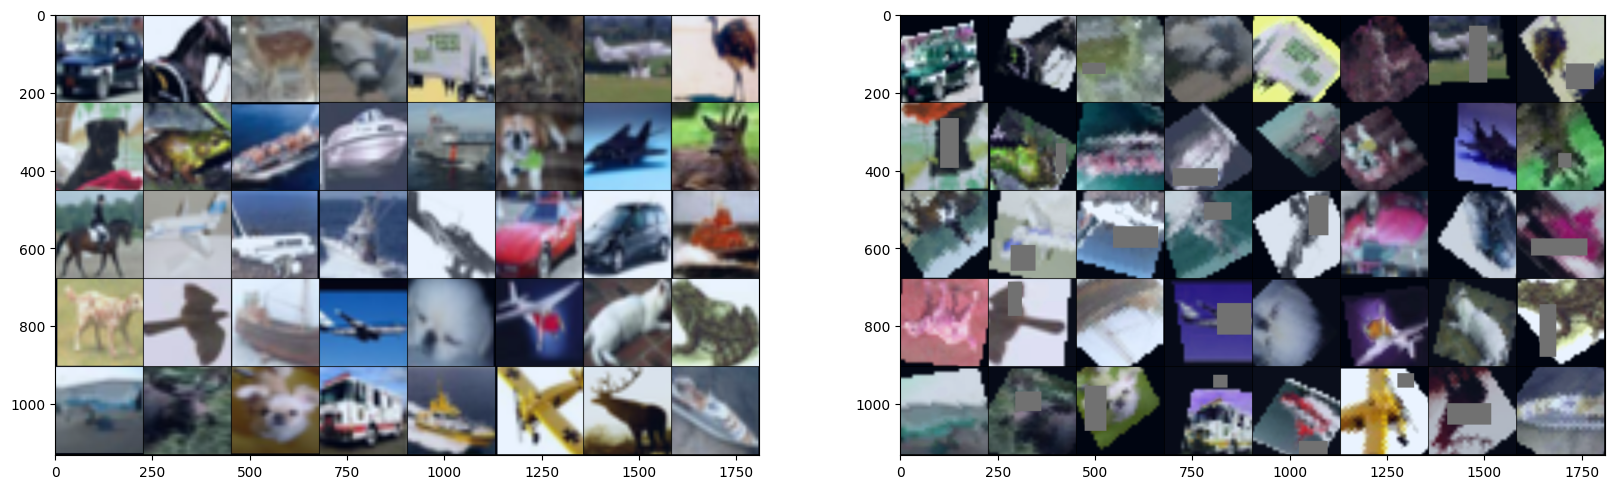

In [58]:
unsupervised_train_loader_iter = iter(unsupervised_train_loaderResNet)
unsup_batch = next(unsupervised_train_loader_iter)

unsup_weak_aug_batch = make_grid(unsup_batch["image"][:40, ...], normalize=True)
unsup_strong_aug_batch = make_grid(unsup_batch["strong_aug"][:40, ...], normalize=True)
plt.figure(figsize=(20, 7))
plt.subplot(121)
plt.imshow(unsup_weak_aug_batch.numpy().transpose((1, 2, 0)))
plt.subplot(122)
plt.imshow(unsup_strong_aug_batch.numpy().transpose((1, 2, 0)))
plt.show()

In [ ]:
from torchvision import models
import torch.nn as nn
import torch.optim as optim

model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1).to(device)

# Geler le backbone uniquement
for name, p in model.named_parameters():
    if not name.startswith("fc."):
        p.requires_grad = False

# Remplacer la tête de classification (entraînable par défaut)
model.fc = nn.Linear(512, 10).to(device)

print(sum(p.numel() for p in model.parameters() if p.requires_grad), "params entraînables")

optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),lr=1e-3, weight_decay=1e-4)    # learning rate, force de la régularisation L2 décorrélée
lr_scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=[100, 150], gamma=0.1)  # ou [150, 225] pour 300 epochs, etc.

##
print(f'nombre de paramètre du modèle ResNet18: {sum([p.numel() for p in model.parameters()])}')
##
if torch.cuda.device_count() > 1:
    model = nn.parallel.DataParallel(model)

supervised_train_loader_iter = cycle(supervised_train_loader) # weak_transforms supervised
unsupervised_train_loader_iter = cycle(unsupervised_train_loader) # Weak + strong_aug_transforms unsupervised
##  
train_model(model, 
            "ResNet18",
            sup_criterion, 
            unsup_criterion,
            optimizer,
            lr_scheduler,
            supervised_train_loader_iter,
            unsupervised_train_loader_iter, 
            num_epochs,
            confidence_threshold,
            lambda_u,
            device,
            tau_start, 
            tau_end,
            warmup_epochs,
            test_loader,
            epoch_length,               
            initial_epoch=0
            )

5130 params entraînables
nombre de paramètre du modèle ResNet18: 11181642
############# Débul du calcul de la performance du modèle ResNet18 à l'état initial #####################
test top-1 acc: 10.44 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 47.93 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
############# Début de l'apprentissage modèle ResNet18 #####################
Batch: 0/1024 --- Loss: 2.41512 sup_loss: 2.41512 unsup_loss: 0.00000
unsup_density : 0.000000
max_probs mean: 0.48589369654655457 max: 0.9762065410614014
max_probs mean: 0.4691177010536194 max: 0.9673818349838257
unsup_density : 0.026786
max_probs mean: 0.5011860728263855 max: 0.9837654232978821
Batch: 1000/1024 --- Loss: 71.42931 sup_loss: 71.42931 unsup_loss: 151.53300
mean non_zero_unsup_loss_density: 0.019114
Train Epoch: 2/ 128 --- Loss: 0.70521 sup_loss: 0.70521 unsup_loss: 1.50328
############# Début du test modèle ResNet18 ################################
test top-1 acc: 24.27 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 76.93 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.53433 sup_loss: 0.53433 unsup_loss: 1.72910
max_probs mean: 0.4978437125682831 max: 0.9591280817985535
max_probs mean: 0.5022321939468384 max: 0.9771184921264648
unsup_density : 0.017857
Batch: 1000/1024 --- Loss: 59.62062 sup_loss: 59.62062 unsup_loss: 162.57543
mean non_zero_unsup_loss_density: 0.027956
Train Epoch: 3/ 128 --- Loss: 0.59063 sup_loss: 0.59063 unsup_loss: 1.61107
############# Début du test modèle ResNet18 ################################
test top-1 acc: 24.41 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 77.16 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.56487 sup_loss: 0.56487 unsup_loss: 1.39701
unsup_density : 0.033482
unsup_density : 0.037946
Batch: 1000/1024 --- Loss: 55.33947 sup_loss: 55.33947 unsup_loss: 166.35637
mean non_zero_unsup_loss_density: 0.038813
Train Epoch: 4/ 128 --- Loss: 0.54724 sup_loss: 0.54724 unsup_loss: 1.65226
############# Début du test modèle ResNet18 ################################
test top-1 acc: 24.42 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 77.26 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.58212 sup_loss: 0.58212 unsup_loss: 1.91363
Batch: 1000/1024 --- Loss: 51.31794 sup_loss: 51.31794 unsup_loss: 168.53246
mean non_zero_unsup_loss_density: 0.049519
Train Epoch: 5/ 128 --- Loss: 0.50849 sup_loss: 0.50849 unsup_loss: 1.66507
############# Début du test modèle ResNet18 ################################
test top-1 acc: 24.42 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 77.51 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 1.37500 sup_loss: 0.53470 unsup_loss: 1.68060
Batch: 1000/1024 --- Loss: 120.10195 sup_loss: 53.12632 unsup_loss: 133.95125
mean non_zero_unsup_loss_density: 0.092818
Train Epoch: 6/ 128 --- Loss: 1.18848 sup_loss: 0.52557 unsup_loss: 1.32582
############# Début du test modèle ResNet18 ################################
test top-1 acc: 24.29 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 76.45 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 1.18720 sup_loss: 0.64556 unsup_loss: 1.08328
max_probs mean: 0.5936417579650879 max: 0.9982619881629944
Batch: 1000/1024 --- Loss: 114.25333 sup_loss: 50.09266 unsup_loss: 128.32134
mean non_zero_unsup_loss_density: 0.098518
Train Epoch: 7/ 128 --- Loss: 1.13015 sup_loss: 0.49492 unsup_loss: 1.27047
############# Début du test modèle ResNet18 ################################
test top-1 acc: 24.78 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 77.05 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 1.12588 sup_loss: 0.47834 unsup_loss: 1.29508
unsup_density : 0.147321
Batch: 1000/1024 --- Loss: 111.78711 sup_loss: 48.34152 unsup_loss: 126.89118
mean non_zero_unsup_loss_density: 0.105474
Train Epoch: 8/ 128 --- Loss: 1.10746 sup_loss: 0.47838 unsup_loss: 1.25817
############# Début du test modèle ResNet18 ################################
test top-1 acc: 25.15 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 77.20 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 1.02576 sup_loss: 0.46662 unsup_loss: 1.11827
max_probs mean: 0.5998975038528442 max: 0.9980966448783875
Batch: 1000/1024 --- Loss: 107.38305 sup_loss: 45.16116 unsup_loss: 124.44377
mean non_zero_unsup_loss_density: 0.113709
Train Epoch: 9/ 128 --- Loss: 1.06237 sup_loss: 0.44599 unsup_loss: 1.23276
############# Début du test modèle ResNet18 ################################
test top-1 acc: 26.02 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 76.99 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.99769 sup_loss: 0.47543 unsup_loss: 1.04452
max_probs mean: 0.619299590587616 max: 0.9912006258964539
max_probs mean: 0.6060488820075989 max: 0.997857391834259
unsup_density : 0.102679
unsup_density : 0.122768
unsup_density : 0.133929
Batch: 1000/1024 --- Loss: 105.33976 sup_loss: 42.36504 unsup_loss: 125.94944
mean non_zero_unsup_loss_density: 0.124328
Train Epoch: 10/ 128 --- Loss: 1.03971 sup_loss: 0.41837 unsup_loss: 1.24268
############# Début du test modèle ResNet18 ################################
test top-1 acc: 26.46 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 77.02 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 1.07176 sup_loss: 0.47340 unsup_loss: 1.19672
unsup_density : 0.158482
max_probs mean: 0.6121567487716675 max: 0.99268639087677
max_probs mean: 0.6206215620040894 max: 0.9958036541938782
unsup_density : 0.151786
unsup_density : 0.113839
max_probs mean: 0.6118168830871582 max: 0.9964861869812012
Batch: 1000/1024 --- Loss: 104.36140 sup_loss: 41.16687 unsup_loss: 126.38907
mean non_zero_unsup_loss_density: 0.130916
Train Epoch: 11/ 128 --- Loss: 1.03264 sup_loss: 0.40752 unsup_loss: 1.25025
############# Début du test modèle ResNet18 ################################
test top-1 acc: 26.67 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 76.92 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.99532 sup_loss: 0.34288 unsup_loss: 1.30488
Batch: 1000/1024 --- Loss: 102.12523 sup_loss: 40.16106 unsup_loss: 123.92834
mean non_zero_unsup_loss_density: 0.138089
Train Epoch: 12/ 128 --- Loss: 1.01164 sup_loss: 0.39786 unsup_loss: 1.22755
############# Début du test modèle ResNet18 ################################
test top-1 acc: 26.89 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 77.19 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 1.01890 sup_loss: 0.43199 unsup_loss: 1.17383
unsup_density : 0.151786
unsup_density : 0.138393
Batch: 1000/1024 --- Loss: 100.85550 sup_loss: 39.35951 unsup_loss: 122.99198
mean non_zero_unsup_loss_density: 0.145869
Train Epoch: 13/ 128 --- Loss: 0.99856 sup_loss: 0.39021 unsup_loss: 1.21670
############# Début du test modèle ResNet18 ################################
test top-1 acc: 27.17 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 76.98 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.92606 sup_loss: 0.35864 unsup_loss: 1.13484
unsup_density : 0.165179
unsup_density : 0.118304
unsup_density : 0.160714
max_probs mean: 0.6453943252563477 max: 0.996696949005127
Batch: 1000/1024 --- Loss: 98.50185 sup_loss: 36.70139 unsup_loss: 123.60091
mean non_zero_unsup_loss_density: 0.155990
Train Epoch: 14/ 128 --- Loss: 0.97798 sup_loss: 0.36373 unsup_loss: 1.22850
############# Début du test modèle ResNet18 ################################
test top-1 acc: 27.06 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 76.81 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.91499 sup_loss: 0.31118 unsup_loss: 1.20761
unsup_density : 0.189732
Batch: 1000/1024 --- Loss: 96.16840 sup_loss: 35.44921 unsup_loss: 121.43838
mean non_zero_unsup_loss_density: 0.163727
Train Epoch: 15/ 128 --- Loss: 0.95024 sup_loss: 0.35043 unsup_loss: 1.19963
############# Début du test modèle ResNet18 ################################
test top-1 acc: 27.28 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 77.09 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.81987 sup_loss: 0.30922 unsup_loss: 1.02130
unsup_density : 0.198661
Batch: 1000/1024 --- Loss: 97.10221 sup_loss: 36.18102 unsup_loss: 121.84237
mean non_zero_unsup_loss_density: 0.171203
Train Epoch: 16/ 128 --- Loss: 0.96069 sup_loss: 0.35737 unsup_loss: 1.20663
############# Début du test modèle ResNet18 ################################
test top-1 acc: 27.27 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 76.95 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.90700 sup_loss: 0.31827 unsup_loss: 1.17746
max_probs mean: 0.6601186394691467 max: 0.9985104203224182
unsup_density : 0.207589
Batch: 1000/1024 --- Loss: 93.98188 sup_loss: 33.43862 unsup_loss: 121.08652
mean non_zero_unsup_loss_density: 0.174129
Train Epoch: 17/ 128 --- Loss: 0.93101 sup_loss: 0.33192 unsup_loss: 1.19818
############# Début du test modèle ResNet18 ################################
test top-1 acc: 27.10 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 76.97 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 1.04241 sup_loss: 0.27883 unsup_loss: 1.52715
max_probs mean: 0.6750712394714355 max: 0.9993230104446411
unsup_density : 0.169643
Batch: 1000/1024 --- Loss: 93.27377 sup_loss: 32.75482 unsup_loss: 121.03790
mean non_zero_unsup_loss_density: 0.181150
Train Epoch: 18/ 128 --- Loss: 0.92490 sup_loss: 0.32574 unsup_loss: 1.19833
############# Début du test modèle ResNet18 ################################
test top-1 acc: 27.37 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 77.24 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 1.03354 sup_loss: 0.38613 unsup_loss: 1.29482
max_probs mean: 0.6639472246170044 max: 0.9993353486061096
Batch: 1000/1024 --- Loss: 91.82469 sup_loss: 32.53607 unsup_loss: 118.57725
mean non_zero_unsup_loss_density: 0.191379
Train Epoch: 19/ 128 --- Loss: 0.90945 sup_loss: 0.32220 unsup_loss: 1.17450
############# Début du test modèle ResNet18 ################################
test top-1 acc: 27.45 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 77.30 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.96885 sup_loss: 0.32870 unsup_loss: 1.28030
unsup_density : 0.187500
max_probs mean: 0.6644353866577148 max: 0.9988473653793335
Batch: 1000/1024 --- Loss: 91.37288 sup_loss: 31.86760 unsup_loss: 119.01055
mean non_zero_unsup_loss_density: 0.195757
Train Epoch: 20/ 128 --- Loss: 0.90526 sup_loss: 0.31571 unsup_loss: 1.17910
############# Début du test modèle ResNet18 ################################
test top-1 acc: 27.20 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 77.05 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.84121 sup_loss: 0.31143 unsup_loss: 1.05956
max_probs mean: 0.6593499779701233 max: 0.9985485672950745
unsup_density : 0.194196
max_probs mean: 0.6667876243591309 max: 0.9979559183120728
Batch: 1000/1024 --- Loss: 89.44160 sup_loss: 30.74086 unsup_loss: 117.40148
mean non_zero_unsup_loss_density: 0.200069
Train Epoch: 21/ 128 --- Loss: 0.88422 sup_loss: 0.30414 unsup_loss: 1.16017
############# Début du test modèle ResNet18 ################################
test top-1 acc: 27.35 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 77.13 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.79052 sup_loss: 0.26195 unsup_loss: 1.05715
unsup_density : 0.180804
Batch: 1000/1024 --- Loss: 89.33178 sup_loss: 30.41217 unsup_loss: 117.83922
mean non_zero_unsup_loss_density: 0.205747
Train Epoch: 22/ 128 --- Loss: 0.88407 sup_loss: 0.30086 unsup_loss: 1.16641
############# Début du test modèle ResNet18 ################################
test top-1 acc: 27.31 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 76.97 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 1.00410 sup_loss: 0.28735 unsup_loss: 1.43350
unsup_density : 0.205357
Batch: 1000/1024 --- Loss: 89.07349 sup_loss: 30.35783 unsup_loss: 117.43132
mean non_zero_unsup_loss_density: 0.212119
Train Epoch: 23/ 128 --- Loss: 0.88241 sup_loss: 0.30087 unsup_loss: 1.16307
############# Début du test modèle ResNet18 ################################
test top-1 acc: 27.28 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 77.05 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 1.01201 sup_loss: 0.38322 unsup_loss: 1.25759
max_probs mean: 0.6601528525352478 max: 0.999631404876709
unsup_density : 0.223214
unsup_density : 0.198661
max_probs mean: 0.6699640154838562 max: 0.9986664056777954
unsup_density : 0.194196
Batch: 1000/1024 --- Loss: 87.83416 sup_loss: 29.21579 unsup_loss: 117.23674
mean non_zero_unsup_loss_density: 0.216214
Train Epoch: 24/ 128 --- Loss: 0.86871 sup_loss: 0.28881 unsup_loss: 1.15981
############# Début du test modèle ResNet18 ################################
test top-1 acc: 27.42 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 77.33 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.88247 sup_loss: 0.27112 unsup_loss: 1.22269
unsup_density : 0.191964
unsup_density : 0.254464
unsup_density : 0.209821
Batch: 1000/1024 --- Loss: 86.33427 sup_loss: 27.60544 unsup_loss: 117.45764
mean non_zero_unsup_loss_density: 0.218295
Train Epoch: 25/ 128 --- Loss: 0.85433 sup_loss: 0.27335 unsup_loss: 1.16196
############# Début du test modèle ResNet18 ################################
test top-1 acc: 27.52 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 77.09 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.77344 sup_loss: 0.23645 unsup_loss: 1.07398
unsup_density : 0.225446
max_probs mean: 0.6826003789901733 max: 0.9985772371292114
unsup_density : 0.232143
Batch: 1000/1024 --- Loss: 86.52366 sup_loss: 28.34209 unsup_loss: 116.36315
mean non_zero_unsup_loss_density: 0.224016
Train Epoch: 26/ 128 --- Loss: 0.85595 sup_loss: 0.27999 unsup_loss: 1.15191
############# Début du test modèle ResNet18 ################################
test top-1 acc: 27.38 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 77.19 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.97504 sup_loss: 0.42517 unsup_loss: 1.09973
unsup_density : 0.212054
unsup_density : 0.229911
max_probs mean: 0.6940779089927673 max: 0.9991676807403564
unsup_density : 0.212054
unsup_density : 0.207589
unsup_density : 0.250000
Batch: 1000/1024 --- Loss: 85.59363 sup_loss: 27.38793 unsup_loss: 116.41139
mean non_zero_unsup_loss_density: 0.228329
Train Epoch: 27/ 128 --- Loss: 0.84888 sup_loss: 0.27160 unsup_loss: 1.15456
############# Début du test modèle ResNet18 ################################
test top-1 acc: 27.62 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 77.04 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.79542 sup_loss: 0.19484 unsup_loss: 1.20116
unsup_density : 0.218750
Batch: 1000/1024 --- Loss: 84.37896 sup_loss: 25.92459 unsup_loss: 116.90874
mean non_zero_unsup_loss_density: 0.232598
Train Epoch: 28/ 128 --- Loss: 0.83576 sup_loss: 0.25687 unsup_loss: 1.15777
############# Début du test modèle ResNet18 ################################
test top-1 acc: 27.45 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 76.97 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.90082 sup_loss: 0.25654 unsup_loss: 1.28856
unsup_density : 0.223214
Batch: 1000/1024 --- Loss: 84.92478 sup_loss: 26.91305 unsup_loss: 116.02346
mean non_zero_unsup_loss_density: 0.233942
Train Epoch: 29/ 128 --- Loss: 0.83977 sup_loss: 0.26636 unsup_loss: 1.14681
############# Début du test modèle ResNet18 ################################
test top-1 acc: 27.42 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 76.88 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.93250 sup_loss: 0.27961 unsup_loss: 1.30578
Batch: 1000/1024 --- Loss: 83.50945 sup_loss: 25.77956 unsup_loss: 115.45977
mean non_zero_unsup_loss_density: 0.239143
Train Epoch: 30/ 128 --- Loss: 0.82586 sup_loss: 0.25524 unsup_loss: 1.14125
############# Début du test modèle ResNet18 ################################
test top-1 acc: 27.33 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 76.86 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.87448 sup_loss: 0.27812 unsup_loss: 1.19273
unsup_density : 0.238839
Batch: 1000/1024 --- Loss: 82.65172 sup_loss: 24.90603 unsup_loss: 115.49139
mean non_zero_unsup_loss_density: 0.244972
Train Epoch: 31/ 128 --- Loss: 0.81838 sup_loss: 0.24749 unsup_loss: 1.14178
############# Début du test modèle ResNet18 ################################
test top-1 acc: 27.43 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 76.91 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.87223 sup_loss: 0.30860 unsup_loss: 1.12726
unsup_density : 0.261161
max_probs mean: 0.7076011896133423 max: 0.9996672868728638
Batch: 1000/1024 --- Loss: 82.38480 sup_loss: 25.06865 unsup_loss: 114.63230
mean non_zero_unsup_loss_density: 0.244192
Train Epoch: 32/ 128 --- Loss: 0.81568 sup_loss: 0.24804 unsup_loss: 1.13528
############# Début du test modèle ResNet18 ################################
test top-1 acc: 27.34 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 76.99 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.75479 sup_loss: 0.20693 unsup_loss: 1.09573
max_probs mean: 0.7034755945205688 max: 0.9987210631370544
Batch: 1000/1024 --- Loss: 82.31039 sup_loss: 24.20914 unsup_loss: 116.20250
mean non_zero_unsup_loss_density: 0.246533
Train Epoch: 33/ 128 --- Loss: 0.81449 sup_loss: 0.23974 unsup_loss: 1.14949
############# Début du test modèle ResNet18 ################################
test top-1 acc: 27.42 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 77.01 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.73108 sup_loss: 0.22846 unsup_loss: 1.00525
unsup_density : 0.225446
max_probs mean: 0.715032160282135 max: 0.9997296929359436
unsup_density : 0.229911
max_probs mean: 0.6801756024360657 max: 0.999725878238678
Batch: 1000/1024 --- Loss: 81.75048 sup_loss: 24.16379 unsup_loss: 115.17338
mean non_zero_unsup_loss_density: 0.249740
Train Epoch: 34/ 128 --- Loss: 0.80865 sup_loss: 0.23829 unsup_loss: 1.14071
############# Début du test modèle ResNet18 ################################
test top-1 acc: 27.30 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 76.94 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.83732 sup_loss: 0.22659 unsup_loss: 1.22147
Batch: 1000/1024 --- Loss: 81.21510 sup_loss: 23.23768 unsup_loss: 115.95485
mean non_zero_unsup_loss_density: 0.253576
Train Epoch: 35/ 128 --- Loss: 0.80443 sup_loss: 0.23032 unsup_loss: 1.14823
############# Début du test modèle ResNet18 ################################
test top-1 acc: 27.46 % pour lesquel la classe prédite la plus probable est exactement le label vrai
test top-5 acc: 76.99 % pour lesquels le label vrai est dans les 5 classes les plus probables du modèle
Batch: 0/1024 --- Loss: 0.84720 sup_loss: 0.24219 unsup_loss: 1.21002

### `2.7 Nettoyage de la mémoire`

In [60]:
# 1. Modèle + optimizer
del model
del optimizer

# 2. Datasets + DataLoader liés à cette expérience
del supervised_train_dataset
del unsupervised_train_datasetResNet
del test_loader
del supervised_train_loaderResNet
del unsupervised_train_loaderResNet

# 3. Tensors / variables temporaires volumineuses, si tu en as
# del big_tensor, all_batches, etc.

import gc
gc.collect()

import torch
if device == "mps":
    torch.mps.empty_cache()   # sur Mac
elif device == "cuda":
    torch.mps.empty_cache()   # sur NVidia   